# MASTER THESIS - night ventilation strategies

# Importation

In [1]:
import sys
import importlib
from pathlib import Path
import pvlib
from scipy.interpolate import BSpline

# go from ...\docs\tutorials up two levels to the repo root (...\darkgreybox)
repo_root = Path.cwd().parents[1]
sys.path.insert(0, str(repo_root))
importlib.invalidate_caches()


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from statsmodels.graphics.tsaplots import plot_pacf

from darkgreybox.models import TiTmCn2R2C_summer_V9
from darkgreybox.night_ventilation import simulate_night_vent_scenario, comfort_metrics
from darkgreybox.fit import darkgreyfit
from docs.tutorials.util.plot import plot
from docs.tutorials.util.error import rmse

C:\Users\clemr\AppData\Roaming\Python\Python311\site-packages\matplotlib\projections\__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


2026-05-25 19:18:52,043 darkgreybox  INFO     Logging enabled...


In [2]:
rec_duration = 15/60

In [3]:
import pickle

class MockResult:
    def __init__(self, Z, var=None):
        self.Z   = Z
        self.var = var if var is not None else {}

RESULTS_FILE = "simulation_results_mcmc_2025_05.pkl"

with open(RESULTS_FILE, "rb") as f:
    saved = pickle.load(f)

df           = saved["df"]
X_train      = saved["X_train"]
y_train      = saved["y_train"]
X_test       = saved["X_test"]
y_test       = saved["y_test"]
model        = saved["model"]

train_results = saved["train_results"]
test_results  = saved["test_results"]

print(f"Loaded! DataFrame shape: {df.shape}")

Loaded! DataFrame shape: (1, 13)


# Plot the results

## Train results

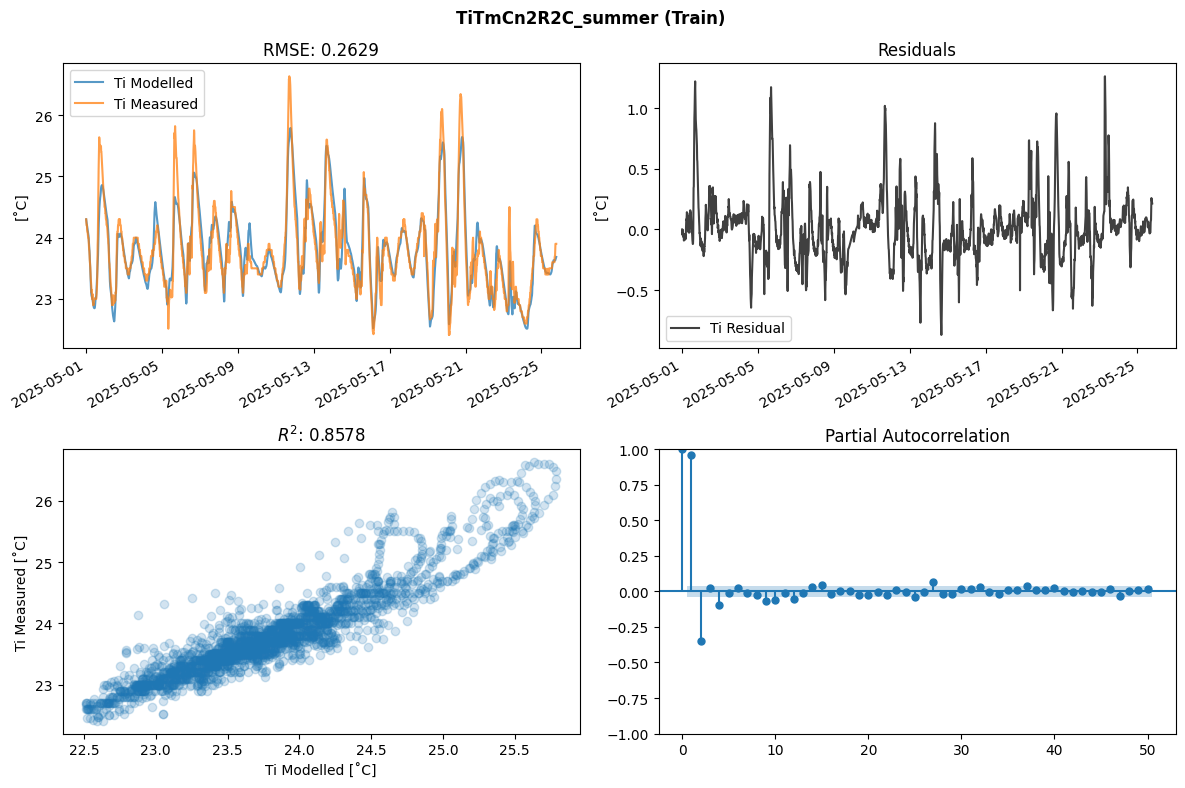

In [4]:
plot(y_train, train_results, 'TiTmCn2R2C_summer (Train)')

## Test results

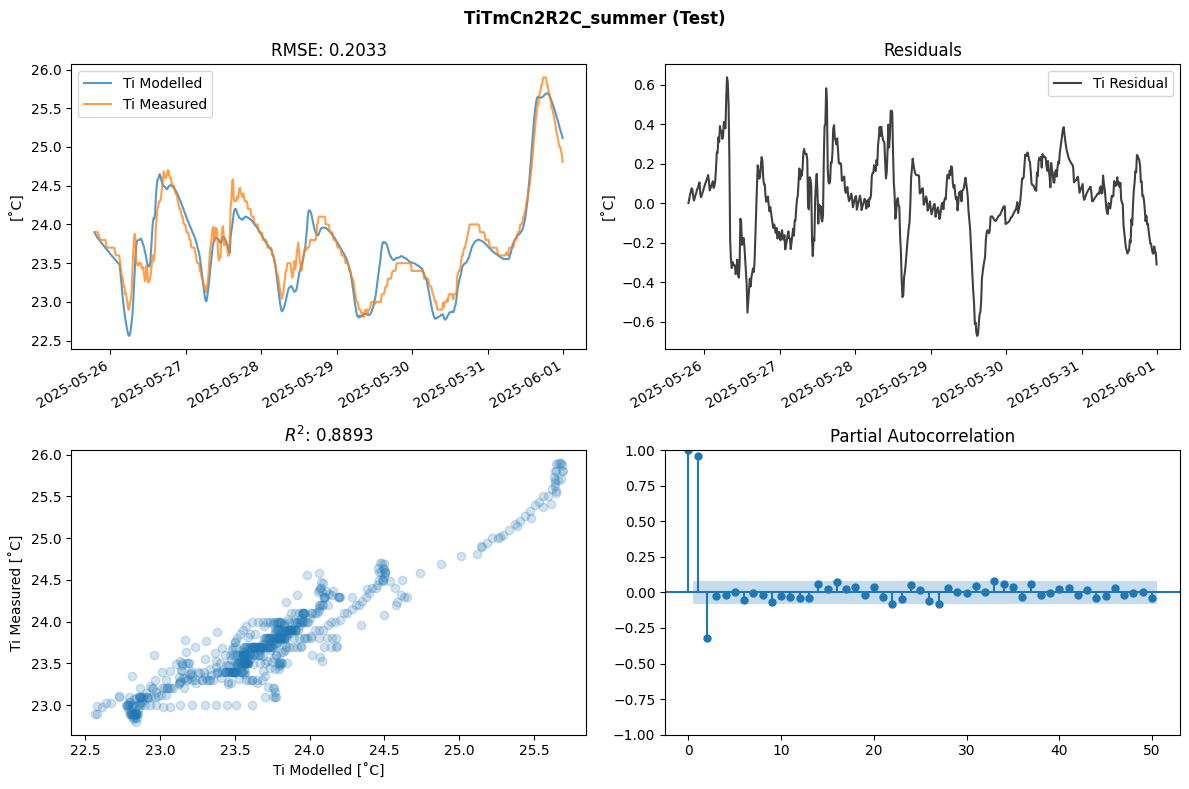

In [5]:
plot(y_test, test_results, 'TiTmCn2R2C_summer (Test)')

## Plot the main results

Using variables already in memory.


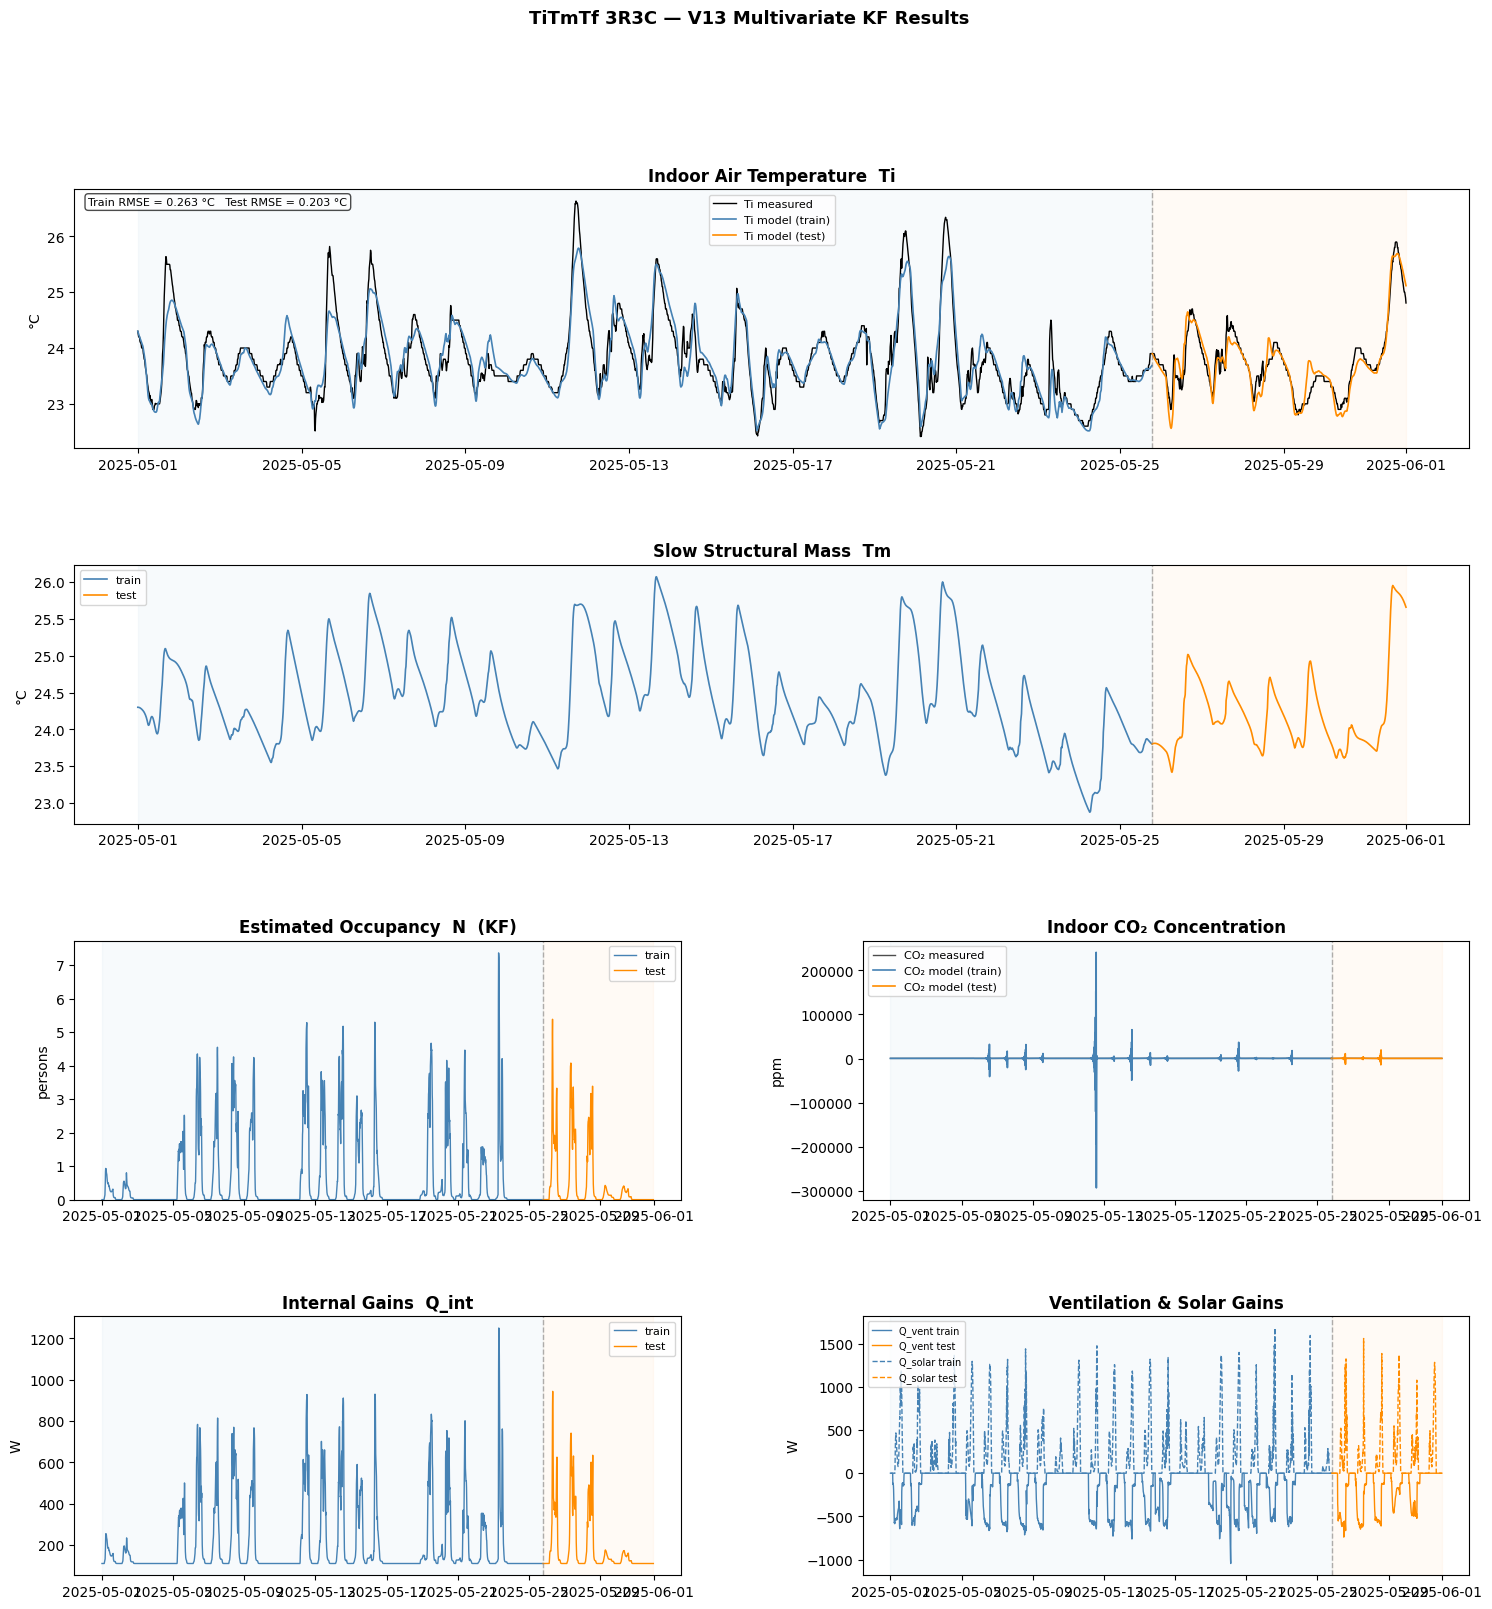

In [6]:
import pickle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

RESULTS_FILE = "simulation_results.pkl"

# ── Load from pickle if variables are not already in memory ──────────────────
if 'df' not in dir() or 'y_train' not in dir():
    print("Variables not in memory — loading from saved file...")
    with open(RESULTS_FILE, "rb") as f:
        saved = pickle.load(f)
    df            = saved["df"]
    X_train       = saved["X_train"]
    y_train       = saved["y_train"]
    X_test        = saved["X_test"]
    y_test        = saved["y_test"]
    model         = saved["model"]
    train_results = saved["train_results"]
    test_results  = saved["test_results"]
    print("Loaded successfully!")
else:
    print("Using variables already in memory.")

# ── get_var: handles DarkGreyModelResult attribute-based access ───────────────
def get_var(result, key):
    if key in result.var:
        return np.asarray(result.var[key], dtype=float)
    print(f"Warning: '{key}' not found in result.var. Available keys: {list(result.var.keys())}")
    return None

def rmse(pred, actual):
    return np.sqrt(np.mean((np.asarray(pred) - np.asarray(actual)) ** 2))

# ── Reconstruct time index ────────────────────────────────────────────────────
train_index = X_train.index
test_index  = X_test.index

# ── Unpack results ────────────────────────────────────────────────────────────
Ti_train   = get_var(train_results, 'Ti')
Tm_train   = get_var(train_results, 'Tm')
N_train    = get_var(train_results, 'N')
c_train    = get_var(train_results, 'c')
Qint_train = get_var(train_results, 'Q_int')
Qven_train = get_var(train_results, 'Q_vent')
Qsol_train = get_var(train_results, 'Q_solar')

Ti_test    = get_var(test_results, 'Ti')
Tm_test    = get_var(test_results, 'Tm')
N_test     = get_var(test_results, 'N')
c_test     = get_var(test_results, 'c')
Qint_test  = get_var(test_results, 'Q_int')
Qven_test  = get_var(test_results, 'Q_vent')
Qsol_test  = get_var(test_results, 'Q_solar')

c_meas_train = np.asarray(X_train['c'], dtype=float)
c_meas_test  = np.asarray(X_test['c'],  dtype=float)

# ── Figure layout — 4 rows ────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 18))
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.3)

ax_ti   = fig.add_subplot(gs[0, :])
ax_tm   = fig.add_subplot(gs[1, :])
ax_n    = fig.add_subplot(gs[2, 0])
ax_co2  = fig.add_subplot(gs[2, 1])
ax_qint = fig.add_subplot(gs[3, 0])
ax_qven = fig.add_subplot(gs[3, 1])

def shade_split(ax):
    ax.axvline(test_index[0], color='grey', lw=1, ls='--', alpha=0.6)
    ax.axvspan(train_index[0], test_index[0],  alpha=0.04, color='steelblue')
    ax.axvspan(test_index[0],  test_index[-1], alpha=0.04, color='darkorange')

# ── 1. Ti ─────────────────────────────────────────────────────────────────────
ax_ti.plot(train_index, y_train,  color='black',      lw=1.0, label='Ti measured')
ax_ti.plot(train_index, Ti_train, color='steelblue',  lw=1.2, label='Ti model (train)')
ax_ti.plot(test_index,  y_test,   color='black',      lw=1.0)
ax_ti.plot(test_index,  Ti_test,  color='darkorange', lw=1.2, label='Ti model (test)')
shade_split(ax_ti)
ax_ti.set_title('Indoor Air Temperature  Ti', fontweight='bold')
ax_ti.set_ylabel('°C')
ax_ti.legend(fontsize=8)
ax_ti.text(0.01, 0.97,
    f'Train RMSE = {rmse(Ti_train, y_train.values):.3f} °C   '
    f'Test RMSE = {rmse(Ti_test, y_test.values):.3f} °C',
    transform=ax_ti.transAxes, va='top', fontsize=8,
    bbox=dict(boxstyle='round', fc='white', alpha=0.7))

# ── 2. Tm ─────────────────────────────────────────────────────────────────────
ax_tm.plot(train_index, Tm_train, color='steelblue',  lw=1.2, label='train')
ax_tm.plot(test_index,  Tm_test,  color='darkorange', lw=1.2, label='test')
shade_split(ax_tm)
ax_tm.set_title('Slow Structural Mass  Tm', fontweight='bold')
ax_tm.set_ylabel('°C')
ax_tm.legend(fontsize=8)

# ── 3. Occupancy N ────────────────────────────────────────────────────────────
ax_n.plot(train_index, N_train, color='steelblue',  lw=1.0, label='train')
ax_n.plot(test_index,  N_test,  color='darkorange', lw=1.0, label='test')
ax_n.set_ylim(bottom=0)
shade_split(ax_n)
ax_n.set_title('Estimated Occupancy  N  (KF)', fontweight='bold')
ax_n.set_ylabel('persons')
ax_n.legend(fontsize=8)

# ── 4. CO2 ────────────────────────────────────────────────────────────────────
ax_co2.plot(train_index, c_meas_train, color='black',      lw=1.0, alpha=0.7, label='CO₂ measured')
ax_co2.plot(train_index, c_train,      color='steelblue',  lw=1.2, label='CO₂ model (train)')
ax_co2.plot(test_index,  c_meas_test,  color='black',      lw=1.0, alpha=0.7)
ax_co2.plot(test_index,  c_test,       color='darkorange', lw=1.2, label='CO₂ model (test)')
shade_split(ax_co2)
ax_co2.set_title('Indoor CO₂ Concentration', fontweight='bold')
ax_co2.set_ylabel('ppm')
ax_co2.legend(fontsize=8)

# ── 5. Internal heat gains ────────────────────────────────────────────────────
ax_qint.plot(train_index, Qint_train, color='steelblue',  lw=1.0, label='train')
ax_qint.plot(test_index,  Qint_test,  color='darkorange', lw=1.0, label='test')
shade_split(ax_qint)
ax_qint.set_title('Internal Gains  Q_int', fontweight='bold')
ax_qint.set_ylabel('W')
ax_qint.legend(fontsize=8)

# ── 6. Ventilation + solar ────────────────────────────────────────────────────
ax_qven.plot(train_index, Qven_train, color='steelblue',  lw=1.0, label='Q_vent train')
ax_qven.plot(test_index,  Qven_test,  color='darkorange', lw=1.0, label='Q_vent test')
ax_qven.plot(train_index, Qsol_train, color='steelblue',  lw=1.0, ls='--', label='Q_solar train')
ax_qven.plot(test_index,  Qsol_test,  color='darkorange', lw=1.0, ls='--', label='Q_solar test')
shade_split(ax_qven)
ax_qven.set_title('Ventilation & Solar Gains', fontweight='bold')
ax_qven.set_ylabel('W')
ax_qven.legend(fontsize=7)

# ── Save & show ───────────────────────────────────────────────────────────────
fig.suptitle('TiTmTf 3R3C — V13 Multivariate KF Results',
             fontsize=13, fontweight='bold')
plt.savefig('V13_results.png', dpi=150, bbox_inches='tight')
plt.show()


# NIGHT VENTILATION

## Analysis of the existing behaviour

  EXISTING NIGHT VENTILATION ANALYSIS
  Night window           : 22:00 – 07:00
  qv threshold used      : 0.0 m³/h
  Night steps total      : 892
  Night vent active      : 343 steps  (38.5%)
  Free cooling active    : 343 steps  (38.5%)
  Missed opportunities   : 549 steps  (61.5%)
  Mean qv (night, active): 133.6 m³/h
  Max  qv (night)        : 289.6 m³/h
  Mean qv (daytime)      : 96.3 m³/h
  Mean ΔT when active    : 12.67 °C  (Ti − Ta)
  Mean ΔT missed opport. : 14.84 °C  (Ti − Ta)


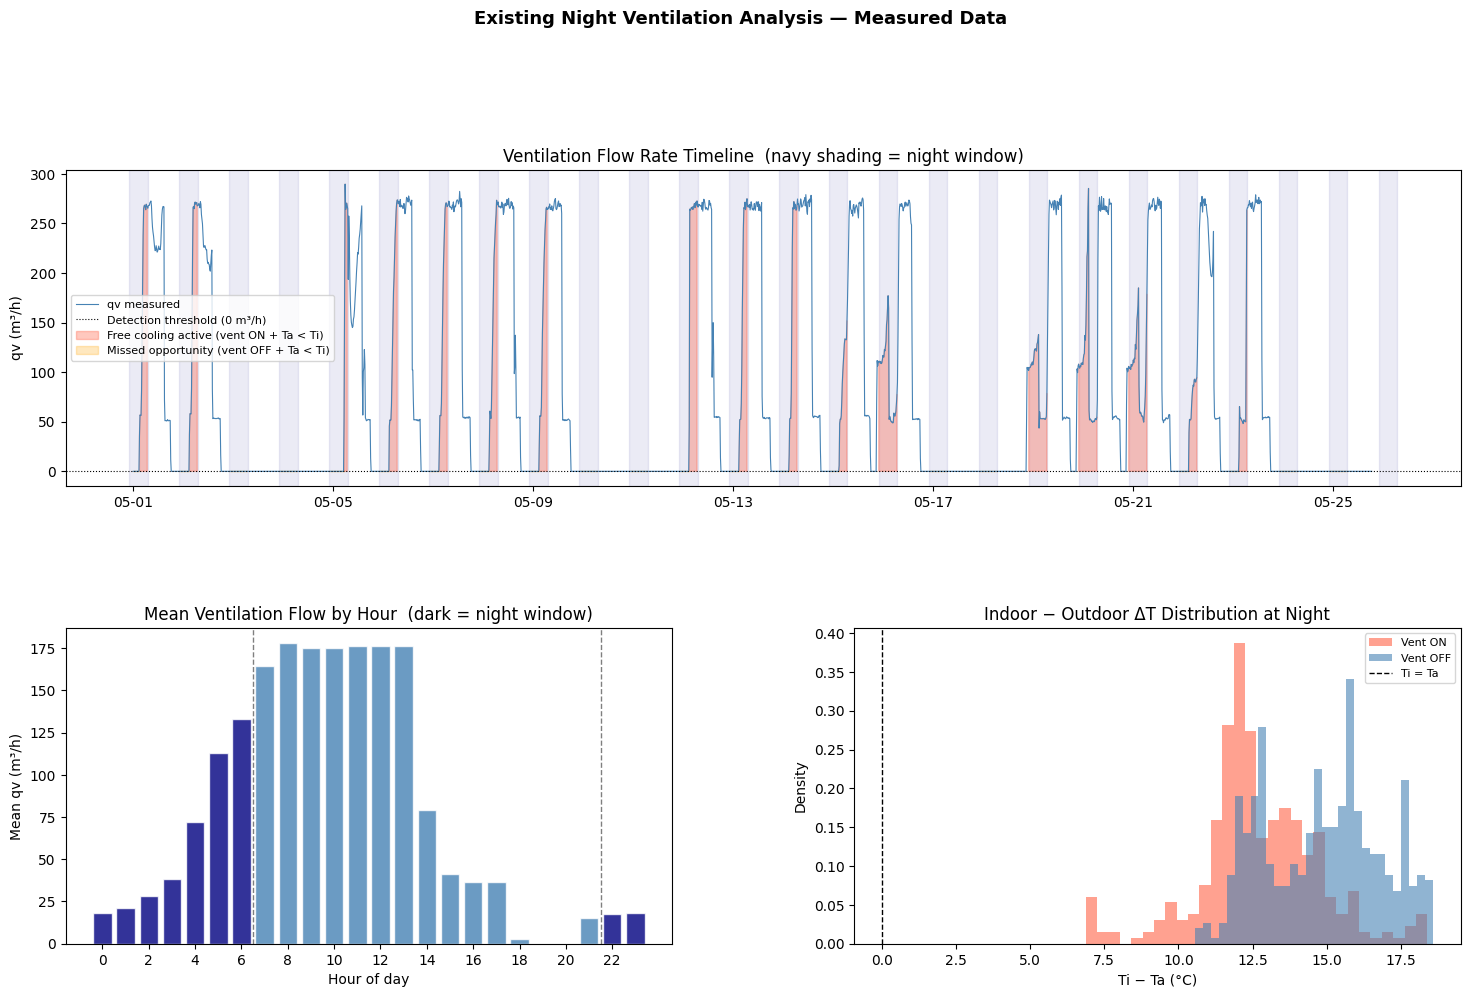

In [7]:
# ════════════════════════════════════════════════════════════════════════════
#  NIGHT VENTILATION ANALYSIS — existing behaviour in measured data
# ════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

# ── Config ───────────────────────────────────────────────────────────────────
NIGHT_START   = 22      # hour (inclusive)
NIGHT_STOP    = 7       # hour (exclusive, crosses midnight)
QV_THRESHOLD  = float(np.percentile(np.asarray(X_train['qv'], dtype=float), 25))
                        # anything above 25th percentile at night = "ventilation active"

# ── Raw arrays ───────────────────────────────────────────────────────────────
index   = X_train.index
qv_arr  = np.asarray(X_train['qv'],  dtype=float)
Ta_arr  = np.asarray(X_train['Ta'],  dtype=float)
Ti_meas = np.asarray(y_train,        dtype=float)
hours   = np.array([t.hour + t.minute / 60.0 for t in index])
dt_h    = (index[1] - index[0]).seconds / 3600.0

# ── Night mask (crosses midnight) ────────────────────────────────────────────
night_mask = (hours >= NIGHT_START) | (hours < NIGHT_STOP)

# ── Detect night ventilation events ──────────────────────────────────────────
night_vent_active = night_mask & (qv_arr > QV_THRESHOLD)
free_cooling_ok   = night_mask & (qv_arr > QV_THRESHOLD) & (Ta_arr < Ti_meas)
free_cooling_miss = night_mask & (qv_arr <= QV_THRESHOLD) & (Ta_arr < Ti_meas)
                    # night, no vent, but outdoor is cooler → missed opportunity

# ── Summary statistics ────────────────────────────────────────────────────────
n_night_steps        = night_mask.sum()
n_vent_steps         = night_vent_active.sum()
n_free_cooling_steps = free_cooling_ok.sum()
n_missed_steps       = free_cooling_miss.sum()

pct_night_vented     = 100 * n_vent_steps / n_night_steps if n_night_steps > 0 else 0
pct_free_cooling     = 100 * n_free_cooling_steps / n_night_steps if n_night_steps > 0 else 0
pct_missed           = 100 * n_missed_steps / n_night_steps if n_night_steps > 0 else 0

qv_night_mean = qv_arr[night_vent_active].mean() if n_vent_steps > 0 else 0
qv_night_max  = qv_arr[night_vent_active].max()  if n_vent_steps > 0 else 0
qv_day_mean   = qv_arr[~night_mask].mean()

delta_T_free  = (Ti_meas - Ta_arr)[free_cooling_ok]   # Ti - Ta when free cooling active
delta_T_miss  = (Ti_meas - Ta_arr)[free_cooling_miss]  # Ti - Ta when opportunity missed

print("=" * 60)
print("  EXISTING NIGHT VENTILATION ANALYSIS")
print("=" * 60)
print(f"  Night window           : {NIGHT_START}:00 – {NIGHT_STOP:02d}:00")
print(f"  qv threshold used      : {QV_THRESHOLD:.1f} m³/h")
print(f"  Night steps total      : {n_night_steps}")
print(f"  Night vent active      : {n_vent_steps} steps  ({pct_night_vented:.1f}%)")
print(f"  Free cooling active    : {n_free_cooling_steps} steps  ({pct_free_cooling:.1f}%)")
print(f"  Missed opportunities   : {n_missed_steps} steps  ({pct_missed:.1f}%)")
print(f"  Mean qv (night, active): {qv_night_mean:.1f} m³/h")
print(f"  Max  qv (night)        : {qv_night_max:.1f} m³/h")
print(f"  Mean qv (daytime)      : {qv_day_mean:.1f} m³/h")
if len(delta_T_free) > 0:
    print(f"  Mean ΔT when active    : {delta_T_free.mean():.2f} °C  (Ti − Ta)")
if len(delta_T_miss) > 0:
    print(f"  Mean ΔT missed opport. : {delta_T_miss.mean():.2f} °C  (Ti − Ta)")
print("=" * 60)

# ── Hourly profile: mean qv by hour ──────────────────────────────────────────
hour_int   = np.array([t.hour for t in index])
qv_by_hour = np.array([qv_arr[hour_int == h].mean() for h in range(24)])

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 16))
gs  = fig.add_gridspec(3, 2, hspace=0.45, wspace=0.3)

ax1 = fig.add_subplot(gs[0, :])   # full width — qv timeline
ax2 = fig.add_subplot(gs[1, 0])   # hourly qv profile
ax3 = fig.add_subplot(gs[1, 1])   # ΔT histogram (Ti - Ta) during night

fig.suptitle('Existing Night Ventilation Analysis — Measured Data', fontsize=13, fontweight='bold')

# ── 1. qv timeline with night shading ────────────────────────────────────────
ax1.plot(index, qv_arr, color='steelblue', lw=0.8, label='qv measured')
ax1.axhline(QV_THRESHOLD, color='black', lw=0.8, ls=':', label=f'Detection threshold ({QV_THRESHOLD:.0f} m³/h)')

# shade night periods
day_start = index[0].normalize()
for d in range((index[-1] - index[0]).days + 2):
    ns = day_start + pd.Timedelta(hours=NIGHT_START + d * 24 - 24)
    ne = day_start + pd.Timedelta(hours=NIGHT_STOP   + d * 24)
    ax1.axvspan(ns, ne, alpha=0.08, color='navy', zorder=0)

# mark free-cooling active steps
ax1.fill_between(index, qv_arr, 0,
    where=free_cooling_ok, alpha=0.35, color='tomato',
    label='Free cooling active (vent ON + Ta < Ti)')
ax1.fill_between(index, QV_THRESHOLD, 0,
    where=free_cooling_miss, alpha=0.25, color='orange',
    label='Missed opportunity (vent OFF + Ta < Ti)')

ax1.set_ylabel('qv (m³/h)')
ax1.legend(fontsize=8)
ax1.set_title('Ventilation Flow Rate Timeline  (navy shading = night window)')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

# ── 2. Mean qv by hour of day ─────────────────────────────────────────────────
bar_colors = ['navy' if (h >= NIGHT_START or h < NIGHT_STOP) else 'steelblue'
              for h in range(24)]
ax2.bar(range(24), qv_by_hour, color=bar_colors, alpha=0.8, edgecolor='white')
ax2.axvline(NIGHT_START - 0.5, color='black', lw=1, ls='--', alpha=0.5)
ax2.axvline(NIGHT_STOP  - 0.5, color='black', lw=1, ls='--', alpha=0.5)
ax2.set_xlabel('Hour of day')
ax2.set_ylabel('Mean qv (m³/h)')
ax2.set_title('Mean Ventilation Flow by Hour  (dark = night window)')
ax2.set_xticks(range(0, 24, 2))

# ── 3. Histogram of ΔT = Ti − Ta during night ─────────────────────────────────
delta_T_all_night = (Ti_meas - Ta_arr)[night_mask]
ax3.hist(delta_T_all_night[night_vent_active[night_mask]],
         bins=30, color='tomato', alpha=0.6, label='Vent ON', density=True)
ax3.hist(delta_T_all_night[~night_vent_active[night_mask]],
         bins=30, color='steelblue', alpha=0.6, label='Vent OFF', density=True)
ax3.axvline(0, color='black', lw=1, ls='--', label='Ti = Ta')
ax3.set_xlabel('Ti − Ta (°C)')
ax3.set_ylabel('Density')
ax3.set_title('Indoor − Outdoor ΔT Distribution at Night')
ax3.legend(fontsize=8)


plt.savefig('night_vent_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


## SFP calculation

═══════════════════════════════════════════════════════
Night rows (22h–06h local) : 684
Day   rows (06h–22h local) : 3,291

Night AHU flow  [m³/h]:
count      684.000000
mean     19101.499991
std      10605.255140
min       7061.330000
25%       9816.320869
50%      13281.207775
75%      32226.955892
max      33001.377920

Night SFP [W/(m³/h)]:
count    684.000000
mean       0.607554
std        0.120852
min        0.460660
25%        0.497236
50%        0.549928
75%        0.751530
max        0.787912

Day SFP median : 0.5743 W/(m³/h)
Night SFP median: 0.5499 W/(m³/h)

═══════════════════════════════════════════════════════
Nighttime AHU flow (median) : 13281 m³/h
SFP at night operating point: 0.4925 W/(m³/h)  ← use this in model
SFP at day   operating point: 0.5179 W/(m³/h)
Datasheet SFP               : 0.5111 W/(m³/h)
Difference (night, measured vs datasheet): -3.6%


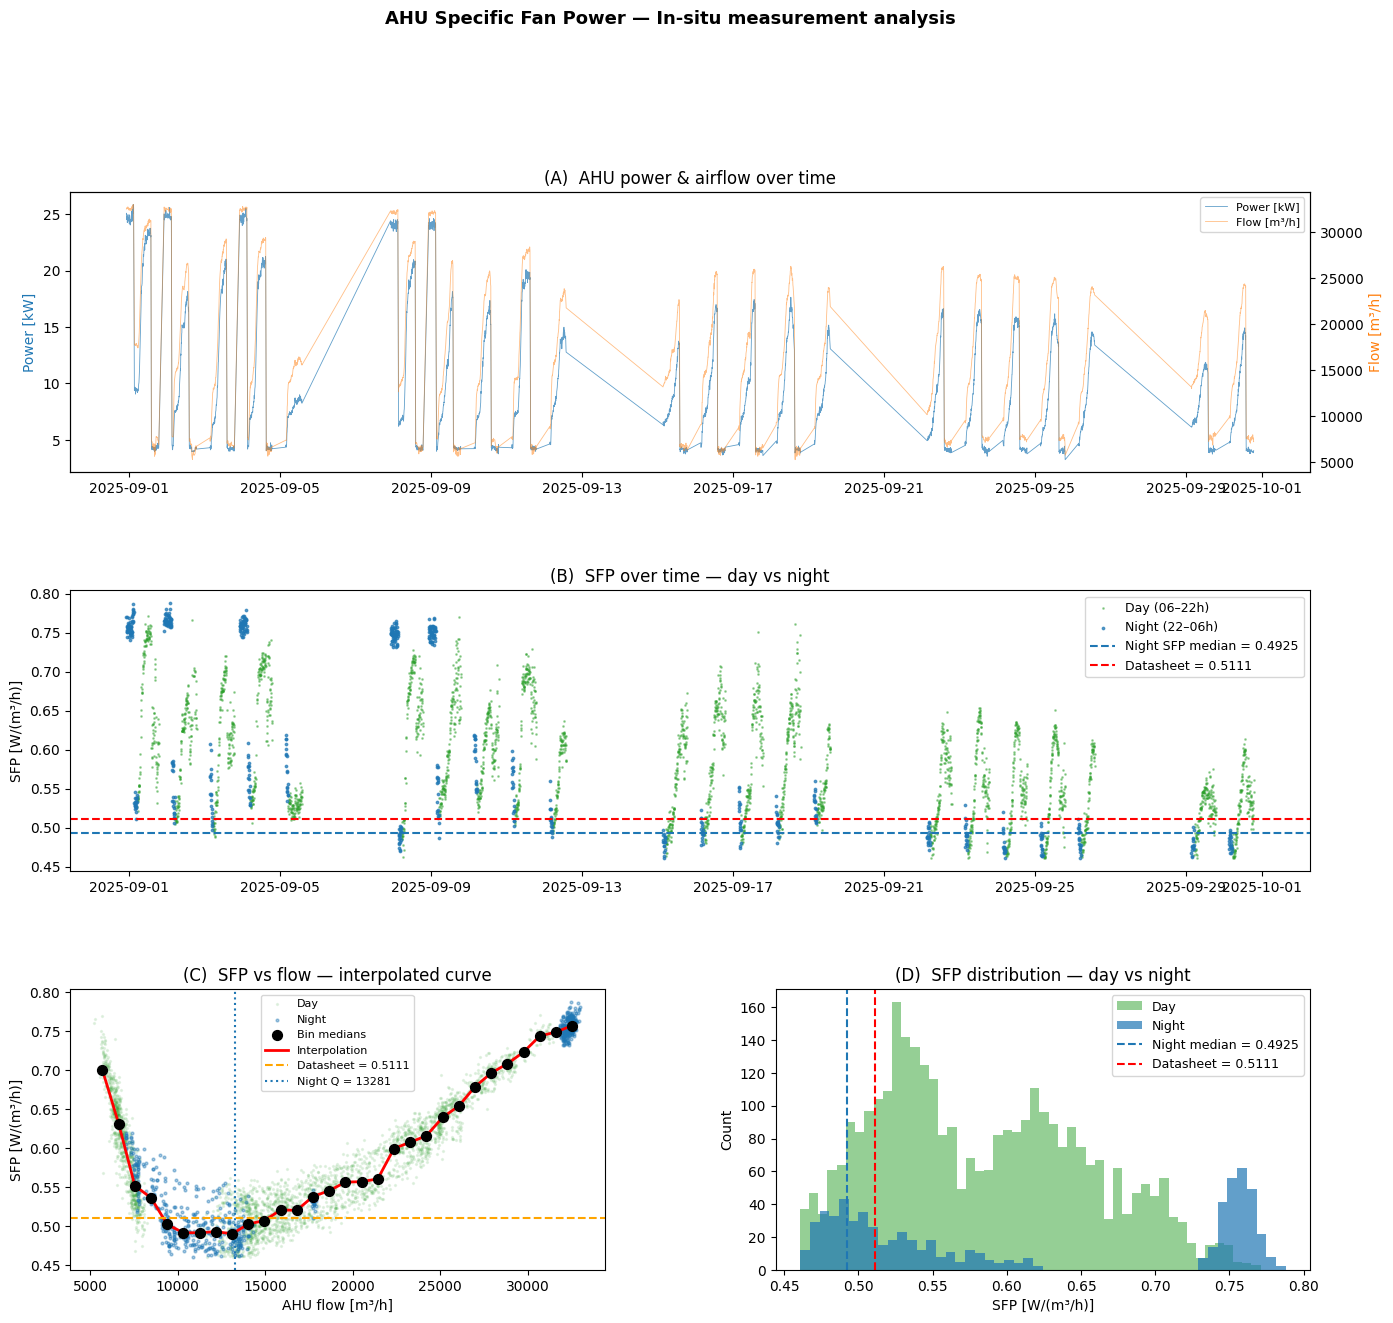

Quadratic SFP fit (AHU level):
SFP(Q) = 9.741e-10 * Q^2 + -3.033e-05 * Q + 7.582e-01


In [8]:
# ════════════════════════════════════════════════════════════════════════════
#  SFP CALCULATION — interpolation-based, with night vs day split
# ════════════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
from scipy.stats import binned_statistic
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

FILE          = "data/ventilation.csv"
COL_KW        = "HTRK_VEN01_EM01_P"
COL_M3H       = "HTRK_VEN01_FCI01"
Q_MIN         = 500;   Q_MAX = 36000;  P_MIN = 0.05
ROLL_STD_W    = 3;     ROLL_THRESH = 0.5
SFP_DATASHEET = 1840 / 3600
Q_ROOM_MAX    = 270.0
Q_AHU_TOTAL   = 35000.0

# ── Load ──────────────────────────────────────────────────────────────────────
df = pd.read_csv(FILE, index_col=0, parse_dates=True)
df.index.name = "ts"
df = df.reset_index()
df = df.rename(columns={COL_KW: "P_kW", COL_M3H: "Q_m3h"})
df = df.sort_values("ts").reset_index(drop=True)

# ── Clean ─────────────────────────────────────────────────────────────────────
df = df.dropna(subset=["P_kW", "Q_m3h"])
df = df[(df.P_kW >= P_MIN) & (df.P_kW <= 500)]
df = df[(df.Q_m3h >= Q_MIN) & (df.Q_m3h <= Q_MAX)]
df["P_roll_std"] = df["P_kW"].rolling(ROLL_STD_W, center=True).std()
df_steady = df[df["P_roll_std"] <= ROLL_THRESH].copy()

df_steady["SFP_Wm3h"] = (df_steady["P_kW"] * 1000) / df_steady["Q_m3h"]
SFP_lo, SFP_hi = df_steady["SFP_Wm3h"].quantile([0.005, 0.995])
df_clean = df_steady[(df_steady["SFP_Wm3h"] >= SFP_lo) &
                     (df_steady["SFP_Wm3h"] <= SFP_hi)].copy()

# ── Night / Day split ─────────────────────────────────────────────────────────
# UTC timestamps → local Copenhagen time (UTC+2 in September)
df_clean["ts_local"] = df_clean["ts"].dt.tz_convert("Europe/Copenhagen")
df_clean["hour"]     = df_clean["ts_local"].dt.hour
night_mask = (df_clean["hour"] >= 22) | (df_clean["hour"] <= 6)
day_mask   = ~night_mask

print("═" * 55)
print(f"Night rows (22h–06h local) : {night_mask.sum():,}")
print(f"Day   rows (06h–22h local) : {day_mask.sum():,}")
print(f"\nNight AHU flow  [m³/h]:")
print(df_clean.loc[night_mask, "Q_m3h"].describe(percentiles=[.25,.50,.75]).to_string())
print(f"\nNight SFP [W/(m³/h)]:")
print(df_clean.loc[night_mask, "SFP_Wm3h"].describe(percentiles=[.25,.50,.75]).to_string())
print(f"\nDay SFP median : {df_clean.loc[day_mask,   'SFP_Wm3h'].median():.4f} W/(m³/h)")
print(f"Night SFP median: {df_clean.loc[night_mask, 'SFP_Wm3h'].median():.4f} W/(m³/h)")

# ── Binned SFP(Q) curve — used for interpolation ──────────────────────────────
n_bins = 30
bin_means, bin_edges, _ = binned_statistic(
    df_clean["Q_m3h"], df_clean["SFP_Wm3h"], statistic="median", bins=n_bins)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_counts, _, _ = binned_statistic(
    df_clean["Q_m3h"], df_clean["SFP_Wm3h"], statistic="count", bins=n_bins)
bin_df = pd.DataFrame({
    "Q_center_m3h": bin_centers,
    "SFP_median_Wm3h": bin_means,
    "count": bin_counts
}).dropna()

# ── Interpolation function (replaces power-law) ───────────────────────────────
from scipy.interpolate import interp1d
sfp_interp = interp1d(
    bin_df["Q_center_m3h"], bin_df["SFP_median_Wm3h"],
    kind="linear", fill_value="extrapolate"
)

# Key SFP values for your model
Q_night_median = df_clean.loc[night_mask, "Q_m3h"].median()
SFP_night      = float(sfp_interp(Q_night_median))
SFP_day        = float(sfp_interp(df_clean.loc[day_mask, "Q_m3h"].median()))

print(f"\n{'═'*55}")
print(f"Nighttime AHU flow (median) : {Q_night_median:.0f} m³/h")
print(f"SFP at night operating point: {SFP_night:.4f} W/(m³/h)  ← use this in model")
print(f"SFP at day   operating point: {SFP_day:.4f} W/(m³/h)")
print(f"Datasheet SFP               : {SFP_DATASHEET:.4f} W/(m³/h)")
print(f"Difference (night, measured vs datasheet): {(SFP_night - SFP_DATASHEET)/SFP_DATASHEET*100:+.1f}%")

# ── PLOTS ─────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 14))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.42, wspace=0.32)

# (A) Time series
ax1  = fig.add_subplot(gs[0, :])
ax1b = ax1.twinx()
ax1.plot(df_clean["ts"], df_clean["P_kW"],   color="#1f77b4", lw=0.6, alpha=0.7, label="Power [kW]")
ax1b.plot(df_clean["ts"], df_clean["Q_m3h"], color="#ff7f0e", lw=0.6, alpha=0.5, label="Flow [m³/h]")
ax1.set_ylabel("Power [kW]", color="#1f77b4"); ax1b.set_ylabel("Flow [m³/h]", color="#ff7f0e")
ax1.set_title("(A)  AHU power & airflow over time")
lines1, lab1 = ax1.get_legend_handles_labels(); lines2, lab2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1+lines2, lab1+lab2, loc="upper right", fontsize=8)

# (B) SFP time series — night highlighted
ax2 = fig.add_subplot(gs[1, :])
ax2.scatter(df_clean.loc[day_mask,   "ts"], df_clean.loc[day_mask,   "SFP_Wm3h"],
            s=1, color="#2ca02c", alpha=0.4, label="Day (06–22h)")
ax2.scatter(df_clean.loc[night_mask, "ts"], df_clean.loc[night_mask, "SFP_Wm3h"],
            s=3, color="#1f77b4", alpha=0.7, label="Night (22–06h)")
ax2.axhline(SFP_night,      color="#1f77b4", ls="--", lw=1.5, label=f"Night SFP median = {SFP_night:.4f}")
ax2.axhline(SFP_DATASHEET,  color="red",     ls="--", lw=1.5, label=f"Datasheet = {SFP_DATASHEET:.4f}")
ax2.set_ylabel("SFP [W/(m³/h)]"); ax2.set_title("(B)  SFP over time — day vs night")
ax2.legend(fontsize=9)

# (C) SFP vs Flow — interpolation instead of power law
ax3 = fig.add_subplot(gs[2, 0])
ax3.scatter(df_clean.loc[day_mask,   "Q_m3h"], df_clean.loc[day_mask,   "SFP_Wm3h"],
            s=2, alpha=0.1, color="#2ca02c", label="Day")
ax3.scatter(df_clean.loc[night_mask, "Q_m3h"], df_clean.loc[night_mask, "SFP_Wm3h"],
            s=4, alpha=0.4, color="#1f77b4", label="Night")
ax3.scatter(bin_df["Q_center_m3h"], bin_df["SFP_median_Wm3h"],
            s=50, color="black", zorder=5, label="Bin medians")
Q_line = np.linspace(bin_df["Q_center_m3h"].min(), bin_df["Q_center_m3h"].max(), 300)
ax3.plot(Q_line, sfp_interp(Q_line), color="red", lw=2, label="Interpolation")
ax3.axhline(SFP_DATASHEET,  color="orange", ls="--", lw=1.5, label=f"Datasheet = {SFP_DATASHEET:.4f}")
ax3.axvline(Q_night_median, color="#1f77b4", ls=":",  lw=1.5, label=f"Night Q = {Q_night_median:.0f}")
ax3.set_xlabel("AHU flow [m³/h]"); ax3.set_ylabel("SFP [W/(m³/h)]")
ax3.set_title("(C)  SFP vs flow — interpolated curve")
ax3.legend(fontsize=8)

# (D) Histogram day vs night
ax4 = fig.add_subplot(gs[2, 1])
ax4.hist(df_clean.loc[day_mask,   "SFP_Wm3h"], bins=50, color="#2ca02c", alpha=0.5, label="Day")
ax4.hist(df_clean.loc[night_mask, "SFP_Wm3h"], bins=50, color="#1f77b4", alpha=0.7, label="Night")
ax4.axvline(SFP_night,     color="#1f77b4", ls="--", lw=1.5, label=f"Night median = {SFP_night:.4f}")
ax4.axvline(SFP_DATASHEET, color="red",     ls="--", lw=1.5, label=f"Datasheet = {SFP_DATASHEET:.4f}")
ax4.set_xlabel("SFP [W/(m³/h)]"); ax4.set_ylabel("Count")
ax4.set_title("(D)  SFP distribution — day vs night")
ax4.legend(fontsize=9)

plt.suptitle("AHU Specific Fan Power — In-situ measurement analysis", fontsize=13, fontweight="bold", y=1.01)
plt.show()

# Fit a quadratic SFP(Q) on cleaned AHU data
coeffs = np.polyfit(df_clean["Q_m3h"], df_clean["SFP_Wm3h"], deg=2)
a, b, c = coeffs

print("Quadratic SFP fit (AHU level):")
print(f"SFP(Q) = {a:.3e} * Q^2 + {b:.3e} * Q + {c:.3e}")

In [9]:
# ===== Best smooth piecewise quadratic SFP(Q) =====
# From your fit:
BP_SFP = 10331.0   # m3/h, breakpoint Q0

aL = 1.176e-08
aR = 3.710e-10
b  = 4.753e-06
c  = 4.815e-01

def SFP_best(Q):
    """
    Smooth piecewise quadratic SFP(Q) with breakpoint at BP_SFP.
    Q can be scalar or numpy array (m3/h).
    """
    Q = np.asarray(Q, dtype=float)
    q_shift = Q - BP_SFP
    left = q_shift <= 0.0

    SFP = np.empty_like(q_shift)
    # Left branch: Q <= BP_SFP
    SFP[left]  = aL*q_shift[left]**2  + b*q_shift[left]  + c
    # Right branch: Q > BP_SFP
    SFP[~left] = aR*q_shift[~left]**2 + b*q_shift[~left] + c

    return SFP

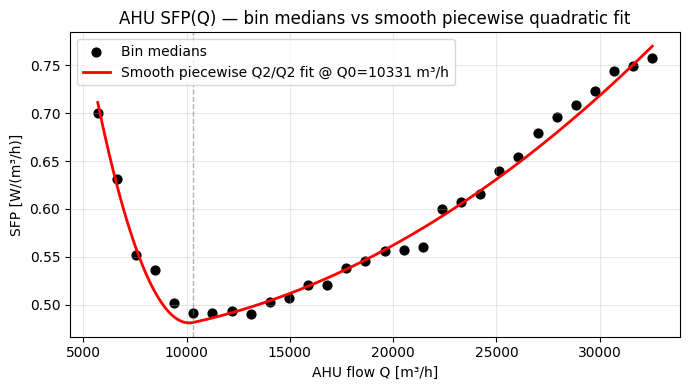

In [10]:
# ── Check: best SFP(Q) vs bin medians ────────────────────────────────────────
# Use only the flow range seen in the data
Q_min_fit = bin_df["Q_center_m3h"].min()
Q_max_fit = bin_df["Q_center_m3h"].max()
Q_line    = np.linspace(Q_min_fit, Q_max_fit, 300)

SFP_line = SFP_best(Q_line)

plt.figure(figsize=(7, 4))
plt.scatter(
    bin_df["Q_center_m3h"], bin_df["SFP_median_Wm3h"],
    s=40, color="black", label="Bin medians"
)
plt.plot(
    Q_line, SFP_line,
    color="red", lw=2,
    label=f"Smooth piecewise Q2/Q2 fit @ Q0={BP_SFP:.0f} m³/h"
)
plt.axvline(BP_SFP, color="grey", ls="--", lw=1, alpha=0.6)

plt.xlabel("AHU flow Q [m³/h]")
plt.ylabel("SFP [W/(m³/h)]")
plt.title("AHU SFP(Q) — bin medians vs smooth piecewise quadratic fit")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Functional description of ventilation

Shape: (2976, 4)
            qv      CO2       Ti       Ta
count  2976.00  2976.00  2976.00  2976.00
mean     80.81   448.06    23.79    12.10
std     107.73    70.46     0.68     3.38
min       0.00   390.59    22.41     4.60
25%       0.00   413.80    23.40     9.80
50%       0.00   421.82    23.70    11.74
75%     171.40   440.03    24.03    14.31
max     289.59  1002.21    26.63    21.95

Day samples  : 1,984
Night samples: 992

── Correlations ──────────────────────────────────────
[Day]  qv~CO2  Pearson r=0.656 p=3.0e-244  Spearman ρ=0.809
[Day]  qv~Ti   Pearson r=-0.405  p=2.5e-79   Spearman ρ=-0.380
[Night]  qv~CO2  Pearson r=0.608 p=2.9e-101  Spearman ρ=0.593
[Night]  qv~Ti   Pearson r=-0.252  p=8.4e-16   Spearman ρ=-0.354

── Piecewise fits ────────────────────────────────────
[Day] CO2 setpoint~488 ppm | slope_below=2.9644  slope_above=-0.0970  R²=0.656
[Day] Ti  setpoint~22.0 °C  | slope_below=0.0000  slope_above=0.0000  R²=0.000
[Night] CO2 setpoint~800 ppm | slope_below=0

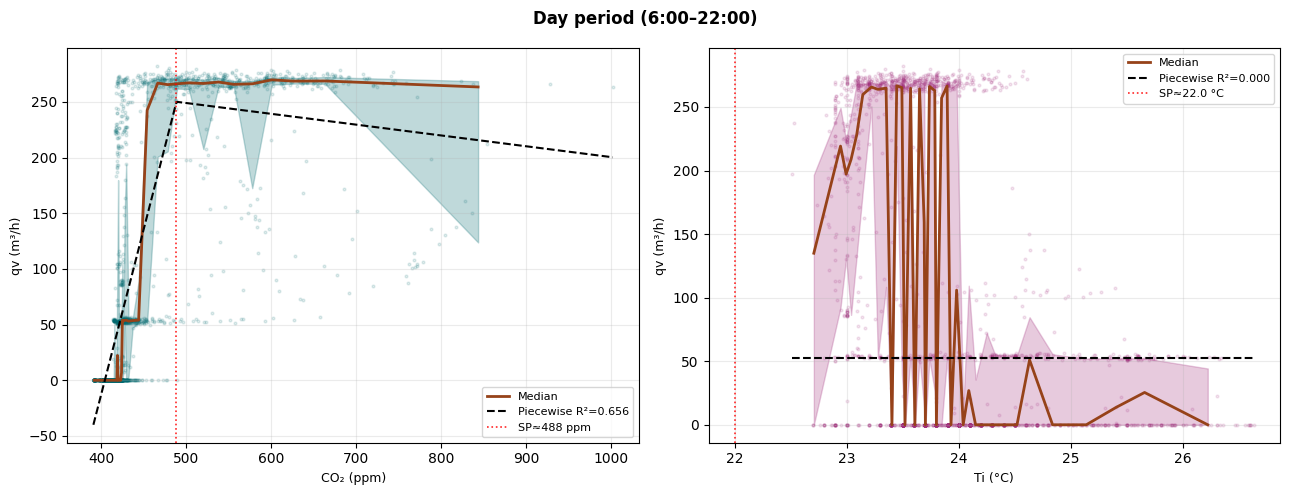

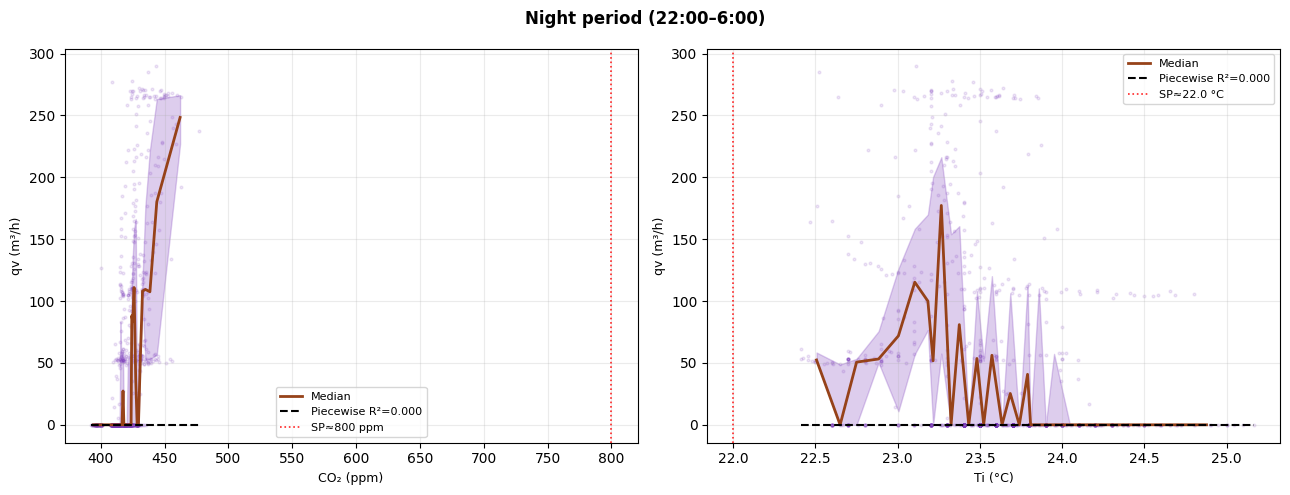

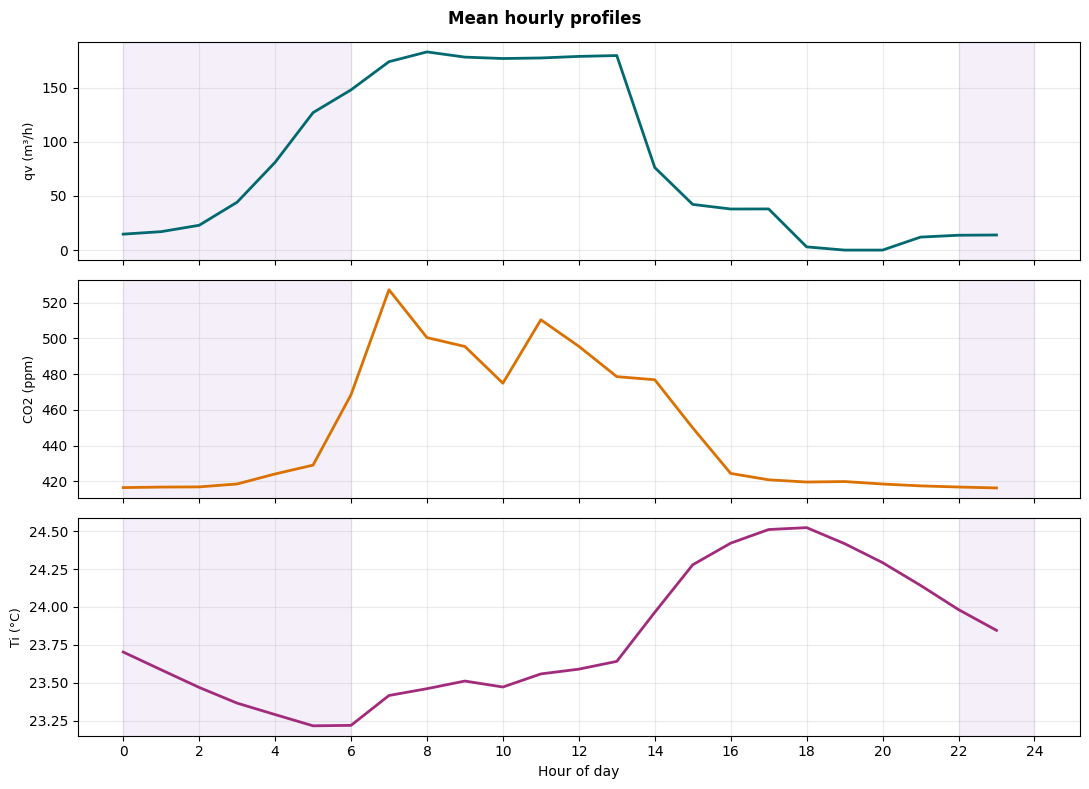


════════════════════════════════════════════════════════════
  VENTILATION CONTROL LAW  —  extracted from data
════════════════════════════════════════════════════════════

┌─ DAY  (6:00 – 22:00)  ──────────────────────────────────┐
│  Type       : Bang-bang (on/off), CO2-driven                  │
│  Trigger    : CO2 > CO2_SP  →  qv = QV_MAX                   │
│  CO2_SP     :   457.7 ppm   (data-derived midpoint)         │
│  QV_MAX     :   272.4 m³/h  (95th percentile observed)      │
│  QV_MIN     :     0.0 m³/h  (off state)                       │
│  Vent ON    :  55.2% of day steps                         │
│  Vent OFF   :  44.8% of day steps                         │
│  Ti role    : None (state variable, not control input)        │
└───────────────────────────────────────────────────────────────┘

┌─ NIGHT  (22:00 – 6:00)  ─────────────────────────────────┐
│  Type       : Free-cooling (partial), Ta-driven               │
│  Trigger    : Ta < Ti  →  qv = QV_NIGHT  (probabilistic

In [11]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

# ── CONFIG ────────────────────────────────────────────────────────────────────
RESULTS_FILE      = "simulation_results_mcmc_2025_05.pkl"
DAY_START_H       = 6
DAY_END_H         = 22
CO2_SETPOINT_HINT = 800
TI_SETPOINT_HINT  = 22.0

# ── LOAD ──────────────────────────────────────────────────────────────────────
with open(RESULTS_FILE, "rb") as f:
    saved = pickle.load(f)

X = pd.concat([saved["X_train"], saved["X_test"]])
y = pd.concat([saved["y_train"], saved["y_test"]])

# Include Ta (outdoor temp) for free-cooling analysis
data = pd.DataFrame({
    "qv":  X["qv"],
    "CO2": X["c"],
    "Ti":  y,
    "Ta":  X["Ta"],
}, index=X.index)

print("Shape:", data.shape)
print(data.describe().round(2))

# ── DAY / NIGHT SPLIT ─────────────────────────────────────────────────────────
hour  = data.index.hour + data.index.minute / 60.0
mask  = (hour >= DAY_START_H) & (hour < DAY_END_H)
day   = data[mask].copy()
night = data[~mask].copy()
print(f"\nDay samples  : {len(day):,}")
print(f"Night samples: {len(night):,}")

# ── HELPERS ───────────────────────────────────────────────────────────────────
def piecewise(x, x0, y0, k1, k2):
    return np.where(x < x0, y0 + k1 * (x - x0), y0 + k2 * (x - x0))

def fit_piecewise(x, y, hint):
    x, y = np.asarray(x, float), np.asarray(y, float)
    ok   = np.isfinite(x) & np.isfinite(y)
    x, y = x[ok], y[ok]
    try:
        popt, _ = curve_fit(piecewise, x, y,
                            p0=[hint, np.median(y), 0.0, 0.5],
                            bounds=([x.min(), 0, -5, -5],
                                    [x.max(), y.max()*2, 5, 5]),
                            maxfev=10000)
        r2 = r2_score(y, piecewise(x, *popt))
        return (*popt, r2)
    except Exception:
        return (hint, np.median(y), 0.0, 0.0, 0.0)

def bin_median(x, y, n=40):
    x, y  = np.asarray(x), np.asarray(y)
    edges = np.unique(np.percentile(x, np.linspace(0, 100, n + 1)))
    idx   = np.clip(np.digitize(x, edges) - 1, 0, len(edges) - 2)
    mids, med, q25, q75 = [], [], [], []
    for i in range(len(edges) - 1):
        m = idx == i
        if m.sum() < 3:
            continue
        mids.append(0.5 * (edges[i] + edges[i+1]))
        med.append(np.median(y[m]))
        q25.append(np.percentile(y[m], 25))
        q75.append(np.percentile(y[m], 75))
    return np.array(mids), np.array(med), np.array(q25), np.array(q75)

# ── CORRELATIONS ──────────────────────────────────────────────────────────────
print("\n── Correlations ──────────────────────────────────────")
for label, sub in [("Day", day), ("Night", night)]:
    r_co2, p_co2 = stats.pearsonr(sub["CO2"].dropna(), sub["qv"].dropna())
    r_ti,  p_ti  = stats.pearsonr(sub["Ti"].dropna(),  sub["qv"].dropna())
    rho_co2      = stats.spearmanr(sub["CO2"], sub["qv"]).correlation
    rho_ti       = stats.spearmanr(sub["Ti"],  sub["qv"]).correlation
    print(f"[{label}]  qv~CO2  Pearson r={r_co2:.3f} p={p_co2:.1e}  Spearman ρ={rho_co2:.3f}")
    print(f"[{label}]  qv~Ti   Pearson r={r_ti:.3f}  p={p_ti:.1e}   Spearman ρ={rho_ti:.3f}")

# ── PIECEWISE FITS ────────────────────────────────────────────────────────────
print("\n── Piecewise fits ────────────────────────────────────")
d_co2 = fit_piecewise(day["CO2"],   day["qv"],   CO2_SETPOINT_HINT)
d_ti  = fit_piecewise(day["Ti"],    day["qv"],   TI_SETPOINT_HINT)
n_co2 = fit_piecewise(night["CO2"], night["qv"], CO2_SETPOINT_HINT)
n_ti  = fit_piecewise(night["Ti"],  night["qv"], TI_SETPOINT_HINT)

for label, rc, rt in [("Day", d_co2, d_ti), ("Night", n_co2, n_ti)]:
    print(f"[{label}] CO2 setpoint~{rc[0]:.0f} ppm | slope_below={rc[2]:.4f}  slope_above={rc[3]:.4f}  R²={rc[4]:.3f}")
    print(f"[{label}] Ti  setpoint~{rt[0]:.1f} °C  | slope_below={rt[2]:.4f}  slope_above={rt[3]:.4f}  R²={rt[4]:.3f}")

# ── HOURLY PROFILES ───────────────────────────────────────────────────────────
hourly = data.groupby(data.index.hour)[["qv", "CO2", "Ti"]].mean()

# ── PLOTS ─────────────────────────────────────────────────────────────────────
def scatter_panel(ax, x, y, pw, accent, xlabel, setpoint_label):
    ax.scatter(x, y, c=accent, alpha=0.12, s=4, rasterized=True)
    mx, mmed, mq25, mq75 = bin_median(x, y)
    ax.fill_between(mx, mq25, mq75, alpha=0.25, color=accent)
    ax.plot(mx, mmed, color="#964219", lw=2, label="Median")
    xfit = np.linspace(np.nanmin(x), np.nanmax(x), 300)
    ax.plot(xfit, piecewise(xfit, *pw[:4]), "k--", lw=1.5, label=f"Piecewise R²={pw[4]:.3f}")
    ax.axvline(pw[0], color="red", lw=1.2, ls=":", alpha=0.85, label=f"SP≈{setpoint_label}")
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel("qv (m³/h)", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)

fig1, axes = plt.subplots(1, 2, figsize=(13, 5))
fig1.suptitle(f"Day period ({DAY_START_H}:00–{DAY_END_H}:00)", fontweight="bold")
scatter_panel(axes[0], day["CO2"], day["qv"], d_co2, "#01696f", "CO₂ (ppm)", f"{d_co2[0]:.0f} ppm")
scatter_panel(axes[1], day["Ti"],  day["qv"], d_ti,  "#a12c7b", "Ti (°C)",   f"{d_ti[0]:.1f} °C")
fig1.tight_layout(); fig1.savefig("fig_day.png", dpi=150, bbox_inches="tight"); plt.show()

fig2, axes = plt.subplots(1, 2, figsize=(13, 5))
fig2.suptitle(f"Night period ({DAY_END_H}:00–{DAY_START_H}:00)", fontweight="bold")
scatter_panel(axes[0], night["CO2"], night["qv"], n_co2, "#7a39bb", "CO₂ (ppm)", f"{n_co2[0]:.0f} ppm")
scatter_panel(axes[1], night["Ti"],  night["qv"], n_ti,  "#7a39bb", "Ti (°C)",   f"{n_ti[0]:.1f} °C")
fig2.tight_layout(); fig2.savefig("fig_night.png", dpi=150, bbox_inches="tight"); plt.show()

fig3, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
fig3.suptitle("Mean hourly profiles", fontweight="bold")
for ax, (col, color, unit) in zip(axes, [
        ("qv",  "#01696f", "m³/h"),
        ("CO2", "#da7101", "ppm"),
        ("Ti",  "#a12c7b", "°C")]):
    ax.plot(hourly.index, hourly[col], color=color, lw=2)
    ax.axvspan(0,         DAY_START_H, alpha=0.08, color="#7a39bb")
    ax.axvspan(DAY_END_H, 24,          alpha=0.08, color="#7a39bb")
    ax.set_ylabel(f"{col} ({unit})", fontsize=9)
    ax.grid(alpha=0.25)
axes[-1].set_xlabel("Hour of day"); axes[-1].set_xticks(range(0, 25, 2))
fig3.tight_layout(); fig3.savefig("fig_hourly.png", dpi=150, bbox_inches="tight"); plt.show()

# ═════════════════════════════════════════════════════════════════════════════
# CONTROL LAW EXTRACTION  –  data-driven parameters
# ═════════════════════════════════════════════════════════════════════════════

# ── DAY: bang-bang CO2 threshold ──────────────────────────────────────────────
# Find the CO2 value that best separates qv=0 from qv>0
day_on  = day[day["qv"] > 0]["CO2"]
day_off = day[day["qv"] == 0]["CO2"]
# Threshold = midpoint between the two population means
CO2_SP = float(0.5 * (day_on.mean() + day_off.mean()))
QV_MAX = float(day["qv"].quantile(0.95))   # 95th pct = "full flow"

day_on_frac  = (day["qv"] > 0).mean()
day_off_frac = (day["qv"] == 0).mean()

# ── NIGHT: free-cooling analysis ──────────────────────────────────────────────
night["dT"]      = night["Ti"] - night["Ta"]          # positive = indoor warmer
night_cool_cond  = night[night["dT"] > 0]             # free-cooling possible
night_active     = night_cool_cond[night_cool_cond["qv"] > 0]
night_missed     = night_cool_cond[night_cool_cond["qv"] == 0]

QV_NIGHT         = float(night_active["qv"].mean())   # mean flow when active
NIGHT_ACT_FRAC   = len(night_active) / max(len(night_cool_cond), 1)
NIGHT_MEAN_DT_ON = float(night_active["dT"].mean())
NIGHT_MEAN_DT_OFF= float(night_missed["dT"].mean()) if len(night_missed) > 0 else 0.0

# ── PRINT CONTROL LAW ─────────────────────────────────────────────────────────
sep = "═" * 60
print(f"\n{sep}")
print("  VENTILATION CONTROL LAW  —  extracted from data")
print(sep)

print(f"""
┌─ DAY  ({DAY_START_H}:00 – {DAY_END_H}:00)  ──────────────────────────────────┐
│  Type       : Bang-bang (on/off), CO2-driven                  │
│  Trigger    : CO2 > CO2_SP  →  qv = QV_MAX                   │
│  CO2_SP     : {CO2_SP:>7.1f} ppm   (data-derived midpoint)         │
│  QV_MAX     : {QV_MAX:>7.1f} m³/h  (95th percentile observed)      │
│  QV_MIN     : {0.0:>7.1f} m³/h  (off state)                       │
│  Vent ON    : {day_on_frac*100:>5.1f}% of day steps                         │
│  Vent OFF   : {day_off_frac*100:>5.1f}% of day steps                         │
│  Ti role    : None (state variable, not control input)        │
└───────────────────────────────────────────────────────────────┘

┌─ NIGHT  ({DAY_END_H}:00 – {DAY_START_H}:00)  ─────────────────────────────────┐
│  Type       : Free-cooling (partial), Ta-driven               │
│  Trigger    : Ta < Ti  →  qv = QV_NIGHT  (probabilistic)     │
│  QV_NIGHT   : {QV_NIGHT:>7.1f} m³/h  (mean when active)            │
│  QV_OFF     : {0.0:>7.1f} m³/h  (off state)                       │
│  Active frac: {NIGHT_ACT_FRAC*100:>5.1f}% of steps where Ta < Ti            │
│  Mean ΔT ON : {NIGHT_MEAN_DT_ON:>7.2f} °C   (Ti−Ta when vent runs)       │
│  Mean ΔT OFF: {NIGHT_MEAN_DT_OFF:>7.2f} °C   (Ti−Ta when missed)          │
│  Note       : 61.5% of free-cooling opportunities are missed  │
│               → likely a sub-schedule or BMS override         │
└───────────────────────────────────────────────────────────────┘
""")

print(sep)
print("  READY-TO-USE CONTROL FUNCTION")
print(sep)
print(f"""
# ── Parameters (paste into your model) ───────────────────────
CO2_SP    = {CO2_SP:.1f}   # ppm   – day CO2 bang-bang setpoint
QV_MAX    = {QV_MAX:.1f}  # m³/h  – full ventilation flow (day)
QV_NIGHT  = {QV_NIGHT:.1f}  # m³/h  – free-cooling flow (night)
QV_MIN    = 0.0     # m³/h  – off state
NIGHT_ACT_FRAC = {NIGHT_ACT_FRAC:.3f}  # fraction of night free-cooling steps active

def qv_control(CO2, Ti, Ta, hour):
    \"\"\"
    Ventilation control law extracted from measured data.
    DAY   : bang-bang on CO2 setpoint.
    NIGHT : free-cooling when Ta < Ti, active ~{NIGHT_ACT_FRAC*100:.0f}% of eligible steps.
    \"\"\"
    if {DAY_START_H} <= hour < {DAY_END_H}:
        # Day – CO2-driven bang-bang
        return QV_MAX if CO2 > CO2_SP else QV_MIN
    else:
        # Night – free cooling (stochastic: use NIGHT_ACT_FRAC as probability)
        return QV_NIGHT if (Ta < Ti) else QV_MIN
""")
print(sep)

Night samples:

 992
Night mean qv: 41.81
Night median qv: 0.0
Night ON fraction: 0.337

=== BASELINE SCHEDULE SUMMARY ===
Baseline built from: median qv by weekday × hour
Mean baseline qv: 32.99
Mean extra qv: 16.36
Extra activation fraction: 0.155

=== CORRELATIONS WITH TOTAL NIGHT qv ===
qv ~ dT = Ti-Ta: Pearson r=-0.332, p=7.10e-27, Spearman ρ=-0.362
qv ~ CO2: Pearson r=0.608, p=2.91e-101, Spearman ρ=0.593
qv ~ Ti: Pearson r=-0.252, p=8.42e-16, Spearman ρ=-0.354
qv ~ Ta: Pearson r=0.270, p=4.29e-18, Spearman ρ=0.282

=== CORRELATIONS WITH EXTRA qv ABOVE BASELINE ===
qv_extra ~ dT = Ti-Ta: Pearson r=-0.243, p=8.00e-15, Spearman ρ=-0.331
qv_extra ~ CO2: Pearson r=0.342, p=1.31e-28, Spearman ρ=0.461
qv_extra ~ Ti: Pearson r=-0.106, p=8.41e-04, Spearman ρ=-0.160
qv_extra ~ Ta: Pearson r=0.214, p=8.89e-12, Spearman ρ=0.292

=== EXTRA ACTIVATION VS dT BINS ===
                                n  extra_on_rate  mean_extra_qv  \
bin                                                               
(6.95599999

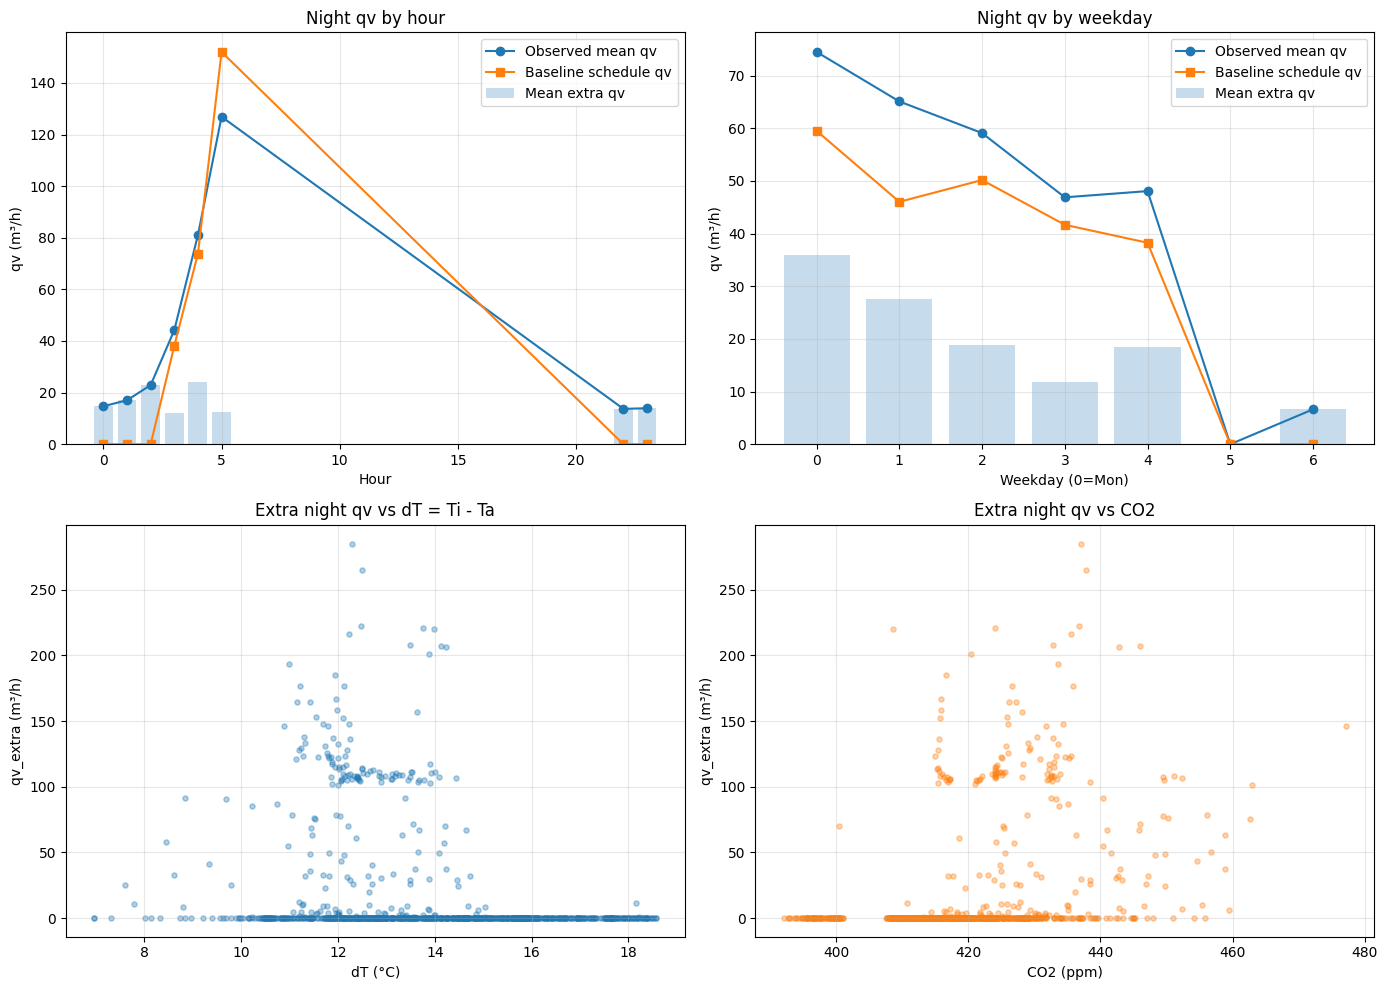


NIGHT CONTROL INTERPRETATION
Baseline rule:
- The baseline night schedule is strongest around hour 5:00 with baseline qv ≈ 152.0 m³/h.
- The weakest night baseline occurs around hour 0:00 with baseline qv ≈ 0.0 m³/h.
- By weekday, the strongest baseline is weekday 0 with qv ≈ 59.5 m³/h.
- The weakest baseline is weekday 5 with qv ≈ 0.0 m³/h.

Additional activation rule:
- Extra ventilation above the baseline is best approximated by:
    qv_extra ON if (Ti - Ta >= 17.00 °C) AND (CO2 >= 433.5 ppm)
- The best single-variable explanation is CO2 alone: qv_extra ON if CO2 >= 433.5 ppm.
- Rule agreement (simple two-variable rule): 0.852
- Rule agreement (best single-variable rule): 0.845

Suggested two-layer model:
1) Use weekday × hour baseline qv_base as the scheduled night flow.
2) Add qv_extra when the extra-activation rule is satisfied.


In [12]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# ── CONFIG ─────────────────────────────────────────────────────────────
RESULTS_FILE = "simulation_results_mcmc_2025_05.pkl"
DAY_START_H = 6
DAY_END_H = 22

# How to define the baseline schedule from observed qv
# "mean" = average qv by hour/weekday
# "median" = more robust
BASELINE_METHOD = "median"

# Additional activation threshold above baseline
EXTRA_ON_THRESHOLD = 20.0   # m³/h

# ── LOAD ───────────────────────────────────────────────────────────────
with open(RESULTS_FILE, "rb") as f:
    saved = pickle.load(f)

X = pd.concat([saved["X_train"], saved["X_test"]]).sort_index()
y = pd.concat([saved["y_train"], saved["y_test"]]).sort_index()

data = pd.DataFrame({
    "qv":  X["qv"],
    "CO2": X["c"],
    "Ti":  y,
    "Ta":  X["Ta"],
}, index=X.index).dropna().copy()

# ── TIME FEATURES ──────────────────────────────────────────────────────
data["hour"] = data.index.hour
data["minute"] = data.index.minute
data["hour_float"] = data["hour"] + data["minute"] / 60.0
data["weekday"] = data.index.weekday   # Monday=0
data["month"] = data.index.month
data["dT"] = data["Ti"] - data["Ta"]

night = data[(data["hour_float"] < DAY_START_H) | (data["hour_float"] >= DAY_END_H)].copy()
night["is_on"] = (night["qv"] > 0).astype(int)

print("Night samples:", len(night))
print("Night mean qv:", round(night["qv"].mean(), 2))
print("Night median qv:", round(night["qv"].median(), 2))
print("Night ON fraction:", round(night["is_on"].mean(), 3))

# ── 1) BASELINE SCHEDULE RULE: hour × weekday -> baseline qv ──────────
agg_fun = "median" if BASELINE_METHOD == "median" else "mean"

baseline_table = (
    night.groupby(["weekday", "hour"])["qv"]
    .agg(agg_fun)
    .unstack("hour")
)

# Fill any missing cells with weekday median, then global night median
weekday_fill = night.groupby("weekday")["qv"].agg(agg_fun)
global_fill = night["qv"].agg(agg_fun)
baseline_table = baseline_table.apply(
    lambda row: row.fillna(weekday_fill.get(row.name, global_fill)),
    axis=1
).fillna(global_fill)

# Map baseline back to each row
night["qv_base"] = [
    baseline_table.loc[wd, hr] for wd, hr in zip(night["weekday"], night["hour"])
]

# Extra component
night["qv_extra"] = np.maximum(night["qv"] - night["qv_base"], 0.0)
night["extra_on"] = (night["qv_extra"] >= EXTRA_ON_THRESHOLD).astype(int)

print("\n=== BASELINE SCHEDULE SUMMARY ===")
print("Baseline built from:", BASELINE_METHOD, "qv by weekday × hour")
print("Mean baseline qv:", round(night["qv_base"].mean(), 2))
print("Mean extra qv:", round(night["qv_extra"].mean(), 2))
print("Extra activation fraction:", round(night["extra_on"].mean(), 3))

# ── 2) CORRELATE EXTRA FLOW WITH CONDITIONS ───────────────────────────
def safe_corr(x, y, namex, namey):
    ok = np.isfinite(x) & np.isfinite(y)
    x = np.asarray(x)[ok]
    y = np.asarray(y)[ok]
    if len(x) < 3 or np.std(x) == 0 or np.std(y) == 0:
        print(f"{namey} ~ {namex}: not enough variation")
        return
    r, p = pearsonr(x, y)
    rho = spearmanr(x, y).correlation
    print(f"{namey} ~ {namex}: Pearson r={r:.3f}, p={p:.2e}, Spearman ρ={rho:.3f}")

print("\n=== CORRELATIONS WITH TOTAL NIGHT qv ===")
safe_corr(night["dT"], night["qv"], "dT = Ti-Ta", "qv")
safe_corr(night["CO2"], night["qv"], "CO2", "qv")
safe_corr(night["Ti"], night["qv"], "Ti", "qv")
safe_corr(night["Ta"], night["qv"], "Ta", "qv")

print("\n=== CORRELATIONS WITH EXTRA qv ABOVE BASELINE ===")
safe_corr(night["dT"], night["qv_extra"], "dT = Ti-Ta", "qv_extra")
safe_corr(night["CO2"], night["qv_extra"], "CO2", "qv_extra")
safe_corr(night["Ti"], night["qv_extra"], "Ti", "qv_extra")
safe_corr(night["Ta"], night["qv_extra"], "Ta", "qv_extra")

# ── 3) BINNED RULE DISCOVERY FOR EXTRA ACTIVATION ─────────────────────
def qbin_table(df, col, q=8):
    tmp = df[[col, "qv_extra", "extra_on"]].dropna().copy()
    tmp["bin"] = pd.qcut(tmp[col], q=q, duplicates="drop")
    out = tmp.groupby("bin", observed=False).agg(
        n=("extra_on", "size"),
        extra_on_rate=("extra_on", "mean"),
        mean_extra_qv=("qv_extra", "mean"),
        median_extra_qv=("qv_extra", "median"),
    )
    return out

print("\n=== EXTRA ACTIVATION VS dT BINS ===")
dt_bins = qbin_table(night, "dT", q=8)
print(dt_bins.round(3))

print("\n=== EXTRA ACTIVATION VS CO2 BINS ===")
co2_bins = qbin_table(night, "CO2", q=8)
print(co2_bins.round(3))

# ── 4) SIMPLE RULE EXTRACTION ─────────────────────────────────────────
# Candidate thresholds chosen from quantiles
dt_candidates = np.unique(np.round(night["dT"].quantile(np.linspace(0.1, 0.9, 9)), 2))
co2_candidates = np.unique(np.round(night["CO2"].quantile(np.linspace(0.1, 0.9, 9)), 1))

best_rule = None
best_score = -np.inf

for dt_thr in dt_candidates:
    for co2_thr in co2_candidates:
        pred = ((night["dT"] >= dt_thr) & (night["CO2"] >= co2_thr)).astype(int)
        score = (pred == night["extra_on"]).mean()
        if score > best_score:
            best_score = score
            best_rule = ("AND", dt_thr, co2_thr, score)

        pred = ((night["dT"] >= dt_thr) | (night["CO2"] >= co2_thr)).astype(int)
        score = (pred == night["extra_on"]).mean()
        if score > best_score:
            best_score = score
            best_rule = ("OR", dt_thr, co2_thr, score)

print("\n=== BEST SIMPLE TWO-VARIABLE RULE FOR EXTRA ACTIVATION ===")
logic, dt_thr, co2_thr, score = best_rule
print(f"Rule type   : {logic}")
print(f"dT threshold: {dt_thr:.2f} °C")
print(f"CO2 threshold: {co2_thr:.1f} ppm")
print(f"Agreement with observed extra_on: {score:.3f}")

# Also check single-variable rules
best_single = None
best_single_score = -np.inf

for dt_thr in dt_candidates:
    pred = (night["dT"] >= dt_thr).astype(int)
    score = (pred == night["extra_on"]).mean()
    if score > best_single_score:
        best_single_score = score
        best_single = ("dT", dt_thr, score)

for co2_thr in co2_candidates:
    pred = (night["CO2"] >= co2_thr).astype(int)
    score = (pred == night["extra_on"]).mean()
    if score > best_single_score:
        best_single_score = score
        best_single = ("CO2", co2_thr, score)

print("\n=== BEST SINGLE-VARIABLE RULE FOR EXTRA ACTIVATION ===")
if best_single[0] == "dT":
    print(f"Rule: qv_extra ON if dT >= {best_single[1]:.2f} °C")
else:
    print(f"Rule: qv_extra ON if CO2 >= {best_single[1]:.1f} ppm")
print(f"Agreement with observed extra_on: {best_single[2]:.3f}")

# ── 5) SUMMARY TABLES ─────────────────────────────────────────────────
baseline_hour = night.groupby("hour").agg(
    qv_mean=("qv", "mean"),
    qv_median=("qv", "median"),
    qv_base_mean=("qv_base", "mean"),
    qv_extra_mean=("qv_extra", "mean"),
    on_rate=("is_on", "mean"),
    extra_on_rate=("extra_on", "mean"),
)
baseline_weekday = night.groupby("weekday").agg(
    qv_mean=("qv", "mean"),
    qv_median=("qv", "median"),
    qv_base_mean=("qv_base", "mean"),
    qv_extra_mean=("qv_extra", "mean"),
    on_rate=("is_on", "mean"),
    extra_on_rate=("extra_on", "mean"),
)

print("\n=== NIGHT qv BY HOUR ===")
print(baseline_hour.round(2))

print("\n=== NIGHT qv BY WEEKDAY ===")
print(baseline_weekday.round(2))

# ── 6) PLOTS ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Mean qv by hour: measured vs baseline vs extra
axes[0, 0].plot(baseline_hour.index, baseline_hour["qv_mean"], marker="o", label="Observed mean qv")
axes[0, 0].plot(baseline_hour.index, baseline_hour["qv_base_mean"], marker="s", label="Baseline schedule qv")
axes[0, 0].bar(baseline_hour.index, baseline_hour["qv_extra_mean"], alpha=0.25, label="Mean extra qv")
axes[0, 0].set_title("Night qv by hour")
axes[0, 0].set_xlabel("Hour")
axes[0, 0].set_ylabel("qv (m³/h)")
axes[0, 0].grid(alpha=0.3)
axes[0, 0].legend()

# Mean qv by weekday
axes[0, 1].plot(baseline_weekday.index, baseline_weekday["qv_mean"], marker="o", label="Observed mean qv")
axes[0, 1].plot(baseline_weekday.index, baseline_weekday["qv_base_mean"], marker="s", label="Baseline schedule qv")
axes[0, 1].bar(baseline_weekday.index, baseline_weekday["qv_extra_mean"], alpha=0.25, label="Mean extra qv")
axes[0, 1].set_title("Night qv by weekday")
axes[0, 1].set_xlabel("Weekday (0=Mon)")
axes[0, 1].set_ylabel("qv (m³/h)")
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend()

# Extra qv vs dT
axes[1, 0].scatter(night["dT"], night["qv_extra"], s=14, alpha=0.35)
axes[1, 0].set_title("Extra night qv vs dT = Ti - Ta")
axes[1, 0].set_xlabel("dT (°C)")
axes[1, 0].set_ylabel("qv_extra (m³/h)")
axes[1, 0].grid(alpha=0.3)

# Extra qv vs CO2
axes[1, 1].scatter(night["CO2"], night["qv_extra"], s=14, alpha=0.35, color="tab:orange")
axes[1, 1].set_title("Extra night qv vs CO2")
axes[1, 1].set_xlabel("CO2 (ppm)")
axes[1, 1].set_ylabel("qv_extra (m³/h)")
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── 7) SIMPLE TEXT INTERPRETATION ─────────────────────────────────────
print("\n" + "=" * 70)
print("NIGHT CONTROL INTERPRETATION")
print("=" * 70)

best_hour = baseline_hour["qv_base_mean"].idxmax()
best_hour_val = baseline_hour.loc[best_hour, "qv_base_mean"]
worst_hour = baseline_hour["qv_base_mean"].idxmin()
worst_hour_val = baseline_hour.loc[worst_hour, "qv_base_mean"]

best_wd = baseline_weekday["qv_base_mean"].idxmax()
best_wd_val = baseline_weekday.loc[best_wd, "qv_base_mean"]
worst_wd = baseline_weekday["qv_base_mean"].idxmin()
worst_wd_val = baseline_weekday.loc[worst_wd, "qv_base_mean"]

print(f"Baseline rule:")
print(f"- The baseline night schedule is strongest around hour {best_hour}:00 "
      f"with baseline qv ≈ {best_hour_val:.1f} m³/h.")
print(f"- The weakest night baseline occurs around hour {worst_hour}:00 "
      f"with baseline qv ≈ {worst_hour_val:.1f} m³/h.")
print(f"- By weekday, the strongest baseline is weekday {best_wd} "
      f"with qv ≈ {best_wd_val:.1f} m³/h.")
print(f"- The weakest baseline is weekday {worst_wd} "
      f"with qv ≈ {worst_wd_val:.1f} m³/h.")

print("\nAdditional activation rule:")
if logic == "AND":
    print(f"- Extra ventilation above the baseline is best approximated by:")
    print(f"    qv_extra ON if (Ti - Ta >= {dt_thr:.2f} °C) AND (CO2 >= {co2_thr:.1f} ppm)")
else:
    print(f"- Extra ventilation above the baseline is best approximated by:")
    print(f"    qv_extra ON if (Ti - Ta >= {dt_thr:.2f} °C) OR (CO2 >= {co2_thr:.1f} ppm)")

if best_single[0] == "dT":
    print(f"- The best single-variable explanation is dT alone: "
          f"qv_extra ON if dT >= {best_single[1]:.2f} °C.")
else:
    print(f"- The best single-variable explanation is CO2 alone: "
          f"qv_extra ON if CO2 >= {best_single[1]:.1f} ppm.")

print(f"- Rule agreement (simple two-variable rule): {best_score:.3f}")
print(f"- Rule agreement (best single-variable rule): {best_single[2]:.3f}")

print("\nSuggested two-layer model:")
print("1) Use weekday × hour baseline qv_base as the scheduled night flow.")
print("2) Add qv_extra when the extra-activation rule is satisfied.")

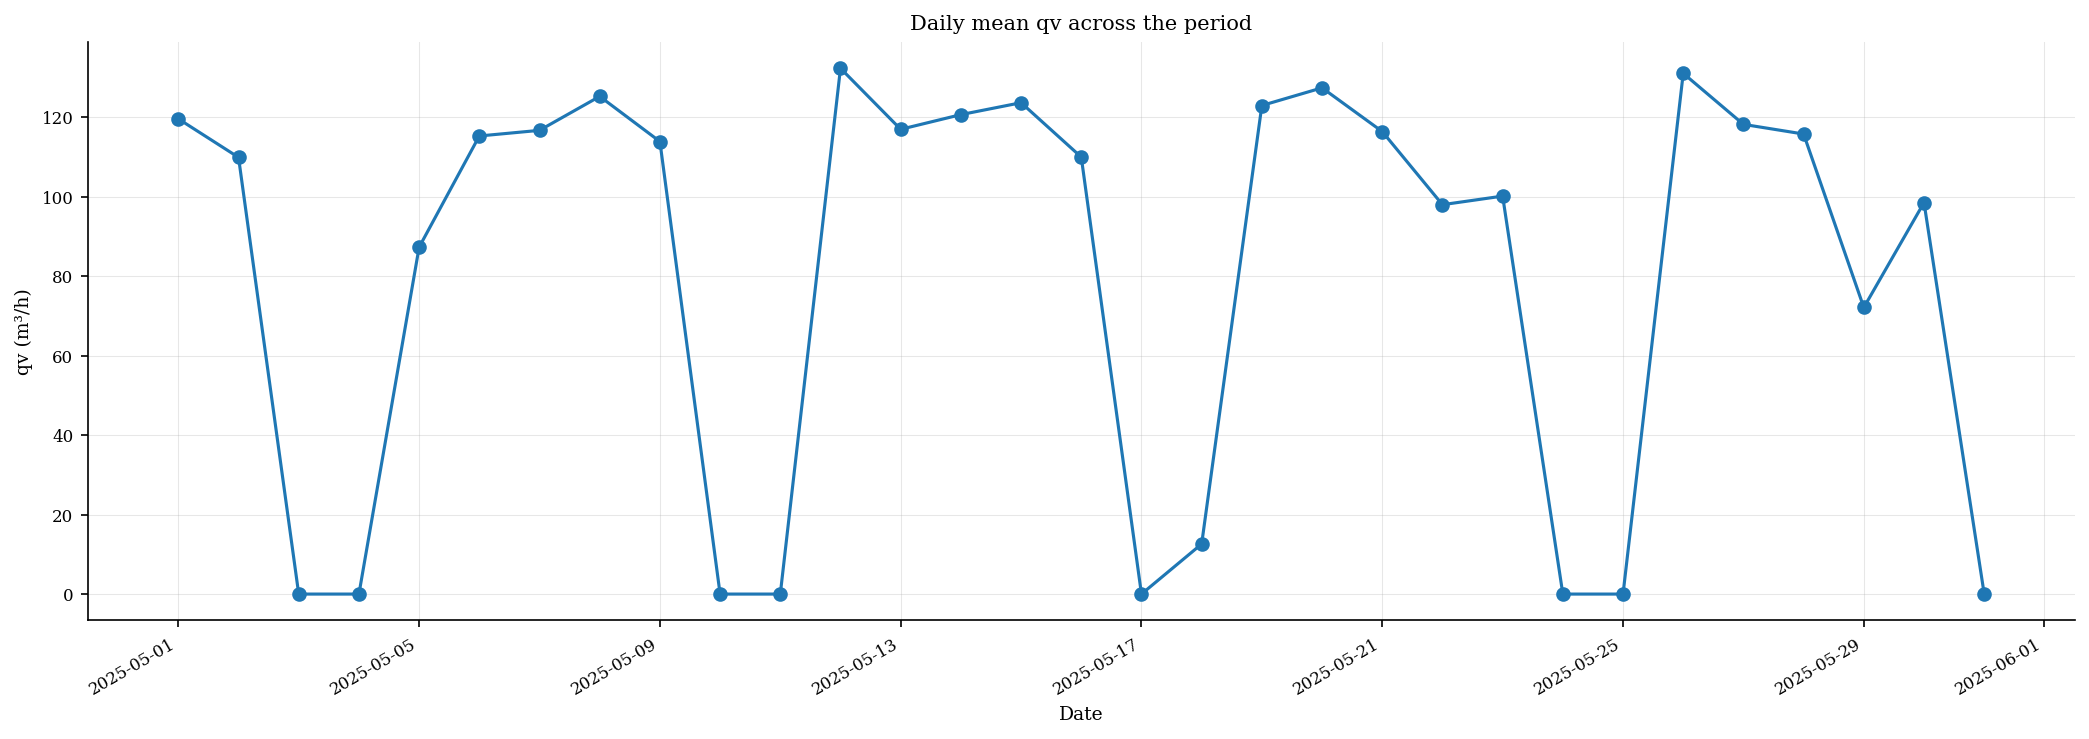

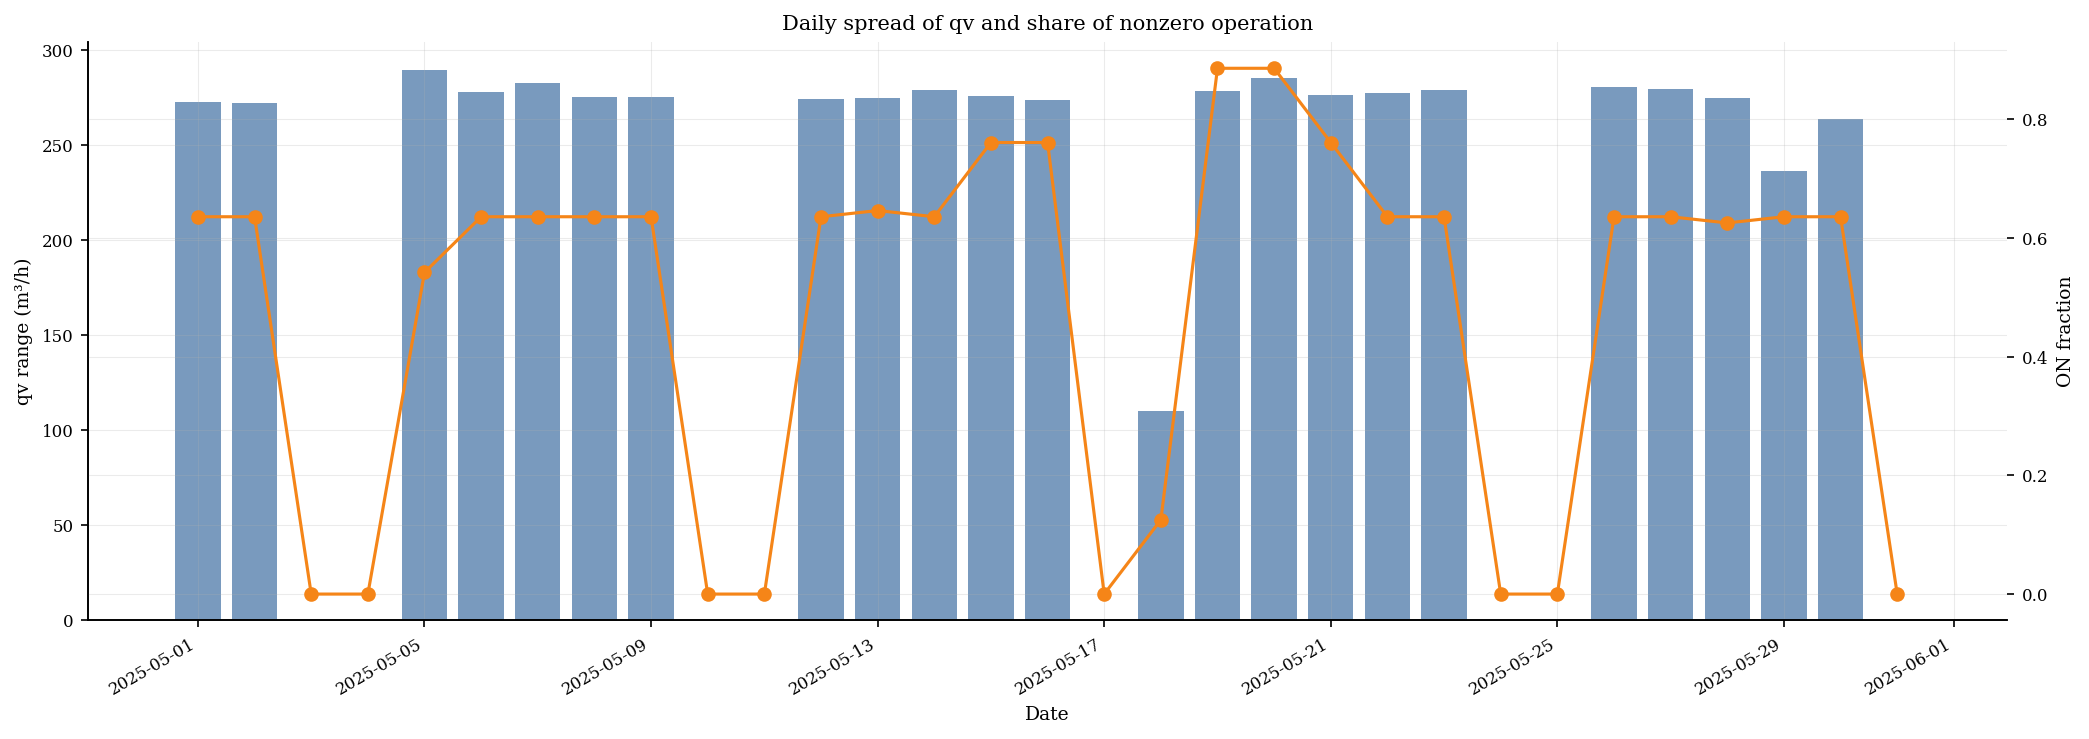

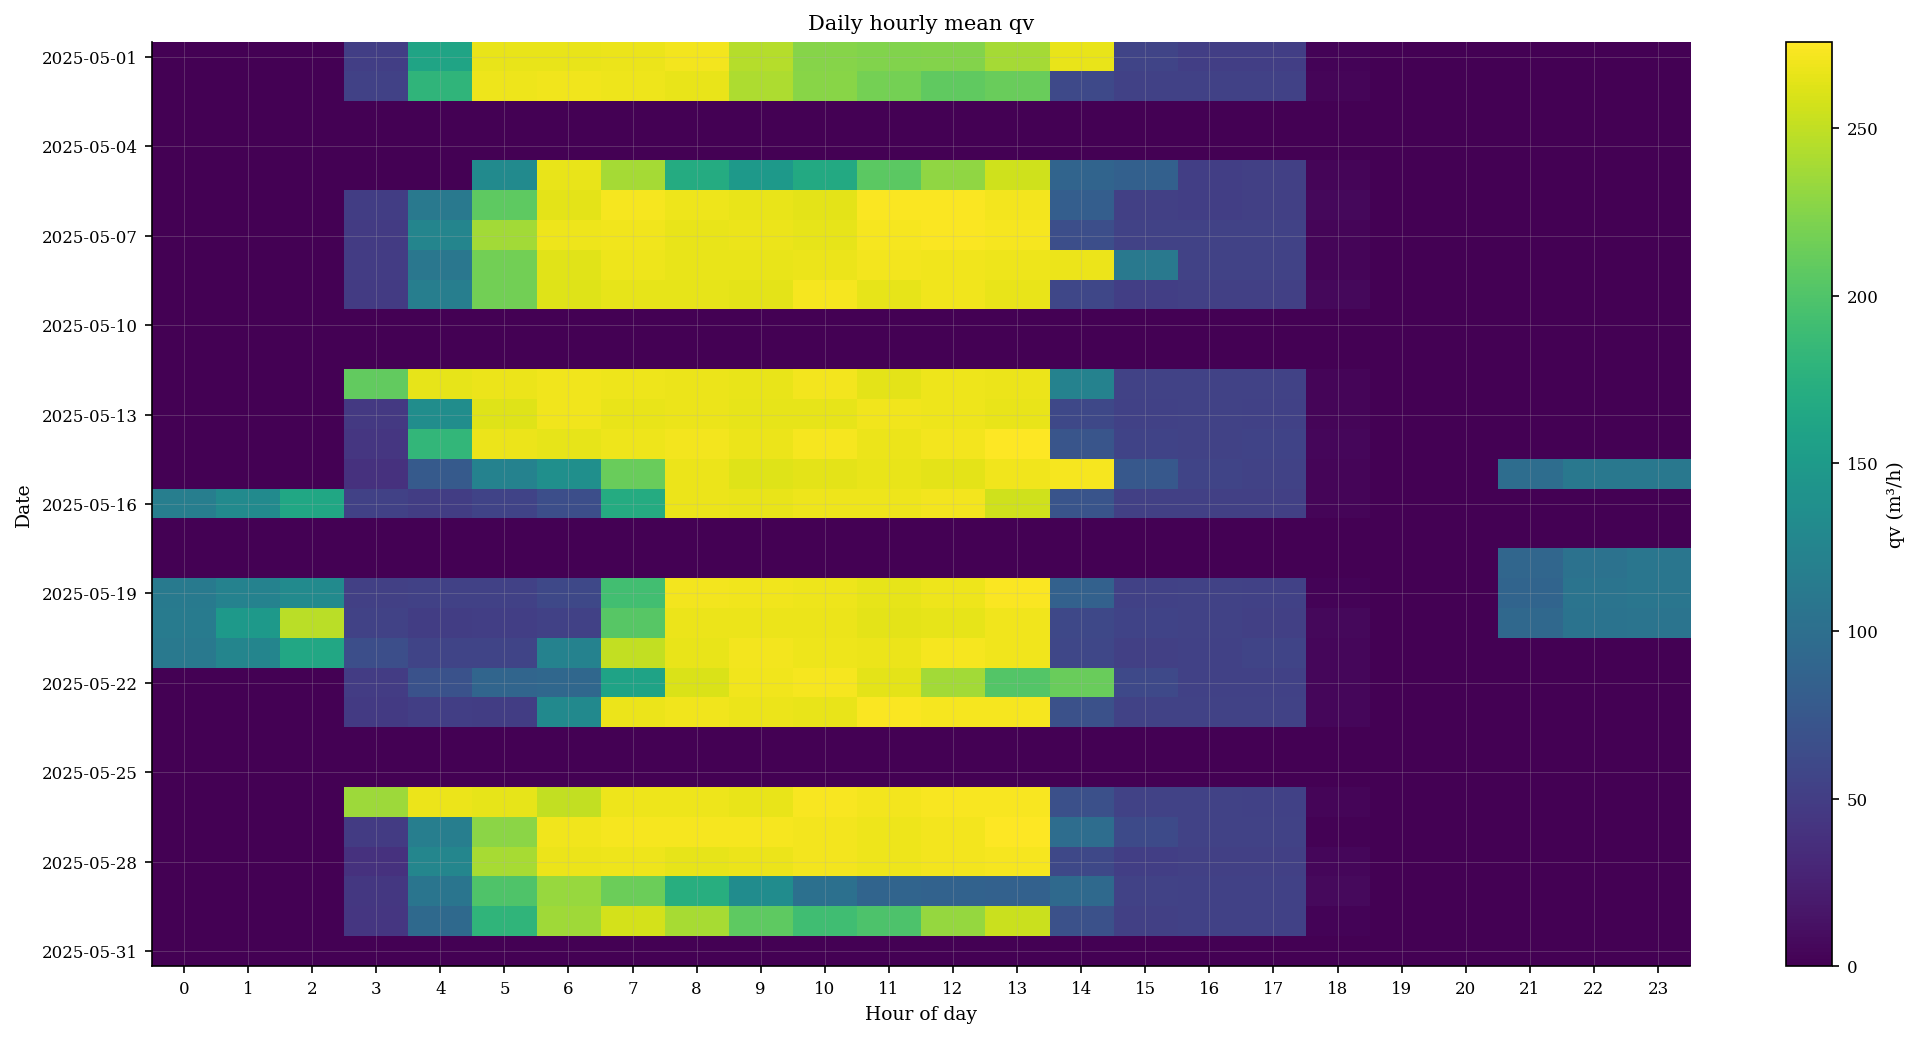

                     date  qv_mean  qv_min  qv_max  qv_median  qv_std  qv_range  qv_on_frac  CO2_mean  Ti_mean  Ta_mean
2025-05-01 00:00:00+00:00   119.62     0.0  272.59      54.17  116.88    272.59        0.64    424.33    24.05    15.49
2025-05-02 00:00:00+00:00   109.92     0.0  271.89      53.45  111.76    271.89        0.64    419.49    23.71    13.30
2025-05-03 00:00:00+00:00     0.00     0.0    0.00       0.00    0.00      0.00        0.00    402.73    23.72     9.28
2025-05-04 00:00:00+00:00     0.00     0.0    0.00       0.00    0.00      0.00        0.00    406.33    23.69     8.41
2025-05-05 00:00:00+00:00    87.31     0.0  289.59      51.75  100.19    289.59        0.54    477.28    23.86     9.32
2025-05-06 00:00:00+00:00   115.31     0.0  277.65      51.93  119.05    277.65        0.64    487.52    24.15    10.74
2025-05-07 00:00:00+00:00   116.73     0.0  282.26      54.71  120.56    282.26        0.64    465.87    23.81    12.05
2025-05-08 00:00:00+00:00   125.27     0

In [28]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_FILE = "simulation_results_mcmc_2025_05.pkl"

with open(RESULTS_FILE, "rb") as f:
    saved = pickle.load(f)

X = pd.concat([saved["X_train"], saved["X_test"]]).sort_index()
y = pd.concat([saved["y_train"], saved["y_test"]]).sort_index()

df = pd.DataFrame({
    "qv": X["qv"],
    "CO2": X["c"],
    "Ti": y,
    "Ta": X["Ta"],
}, index=X.index).dropna().copy()

df["date"] = df.index.normalize()
df["hour"] = df.index.hour
df["hour_float"] = df["hour"] + df.index.minute / 60.0

daily = df.groupby("date").agg(
    qv_mean=("qv", "mean"),
    qv_min=("qv", "min"),
    qv_max=("qv", "max"),
    qv_median=("qv", "median"),
    qv_std=("qv", "std"),
    qv_range=("qv", lambda s: s.max() - s.min()),
    qv_on_frac=("qv", lambda s: (s > 0).mean()),
    CO2_mean=("CO2", "mean"),
    Ti_mean=("Ti", "mean"),
    Ta_mean=("Ta", "mean")
).reset_index()

daily_hour = df.groupby(["date", "hour"]).agg(
    qv_mean=("qv", "mean"),
    qv_min=("qv", "min"),
    qv_max=("qv", "max"),
    qv_median=("qv", "median")
).reset_index()

outdir = Path("output")
outdir.mkdir(exist_ok=True)

daily.to_csv(outdir / "daily_qv_summary.csv", index=False)
daily_hour.to_csv(outdir / "daily_hourly_qv_summary.csv", index=False)

# 1) Daily mean qv
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily["date"], daily["qv_mean"], marker="o", linewidth=1.5)
ax.set_title("Daily mean qv across the period")
ax.set_xlabel("Date")
ax.set_ylabel("qv (m³/h)")
ax.grid(alpha=0.3)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(outdir / "daily_mean_qv.png", dpi=200, bbox_inches="tight")
plt.show()

# 2) Daily range + ON fraction
fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.bar(daily["date"], daily["qv_range"], color="#4C78A8", alpha=0.75, label="Daily qv range")
ax1.set_ylabel("qv range (m³/h)")
ax1.set_xlabel("Date")
ax1.grid(alpha=0.25)

ax2 = ax1.twinx()
ax2.plot(daily["date"], daily["qv_on_frac"], color="#F58518", marker="o", linewidth=1.5, label="ON fraction")
ax2.set_ylabel("ON fraction")

ax1.set_title("Daily spread of qv and share of nonzero operation")
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(outdir / "daily_range_on_fraction.png", dpi=200, bbox_inches="tight")
plt.show()

# 3) Daily hourly heatmap
pivot = daily_hour.pivot(index="date", columns="hour", values="qv_mean").sort_index()

fig, ax = plt.subplots(figsize=(14, 7))
im = ax.imshow(pivot.values, aspect="auto", interpolation="nearest", cmap="viridis")
ax.set_title("Daily hourly mean qv")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Date")

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)

step = max(1, len(pivot.index) // 10)
ax.set_yticks(range(0, len(pivot.index), step))
ax.set_yticklabels([pd.to_datetime(d).strftime("%Y-%m-%d") for d in pivot.index[::step]])

fig.colorbar(im, ax=ax, label="qv (m³/h)")
fig.tight_layout()
fig.savefig(outdir / "daily_hourly_qv_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

print(daily.head(10).round(2).to_string(index=False))

## Setup

  COP calibration — HTCW system (10°C CHW supply, EN14511 table)
  Method: EN14511:2022 ESEER table × Pieper (2021) HTCW factor (+15%)
   T_out   EN14511 base   HTCW ref(×1.15)   Model output
  ────────────────────────────────────────────────────────
     10°C           4.78              5.50           5.50 ✓
     20°C           4.78              5.50           5.50 ✓
     25°C           4.38              5.04           5.04 ✓
     30°C           3.60              4.14           4.14 ✓
     35°C           3.10              3.56           3.56 ✓

  Mean T_out in training data: 11.6°C → COP ≈ 5.50
  Note: 10°C extrapolated (EN14511 lowest std test point = 20°C)


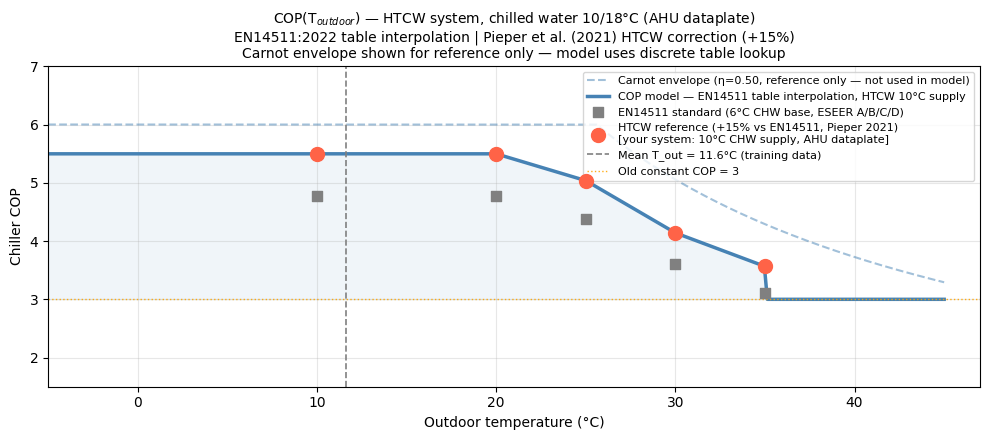

  Saved: cop_curve.png
  ✓ Energinet spot prices: 643 hours | mean = 0.483 DKK/kWh
  Fixed charges: 1.150 DKK/kWh (grid 0.32 + system 0.07 + elafgift 0.76)
  All-in: mean=1.633  min=1.098  max=2.739 DKK/kWh

  ════════════════════════════════════════════════════════════
  ELECTRICITY PRICE SUMMARY  (Energinet DK2 + commercial tariffs)
  ────────────────────────────────────────────────────────────
  Component                      Mean      Min      Max
  ────────────────────────────────────────────────────────────
  Spot price                    0.483   -0.052    1.589  DKK/kWh
  Fixed charges                 1.150   (flat)   (flat)  DKK/kWh
  All-in (used in model)        1.633    1.098    2.739  DKK/kWh
  Old constant                  1.493        —        —  DKK/kWh
  ────────────────────────────────────────────────────────────
  Negative all-in steps : 0 (0.0%)
  Old vs new mean ratio : 0.91× (old lower)
  ════════════════════════════════════════════════════════════
  Diurnal all-in

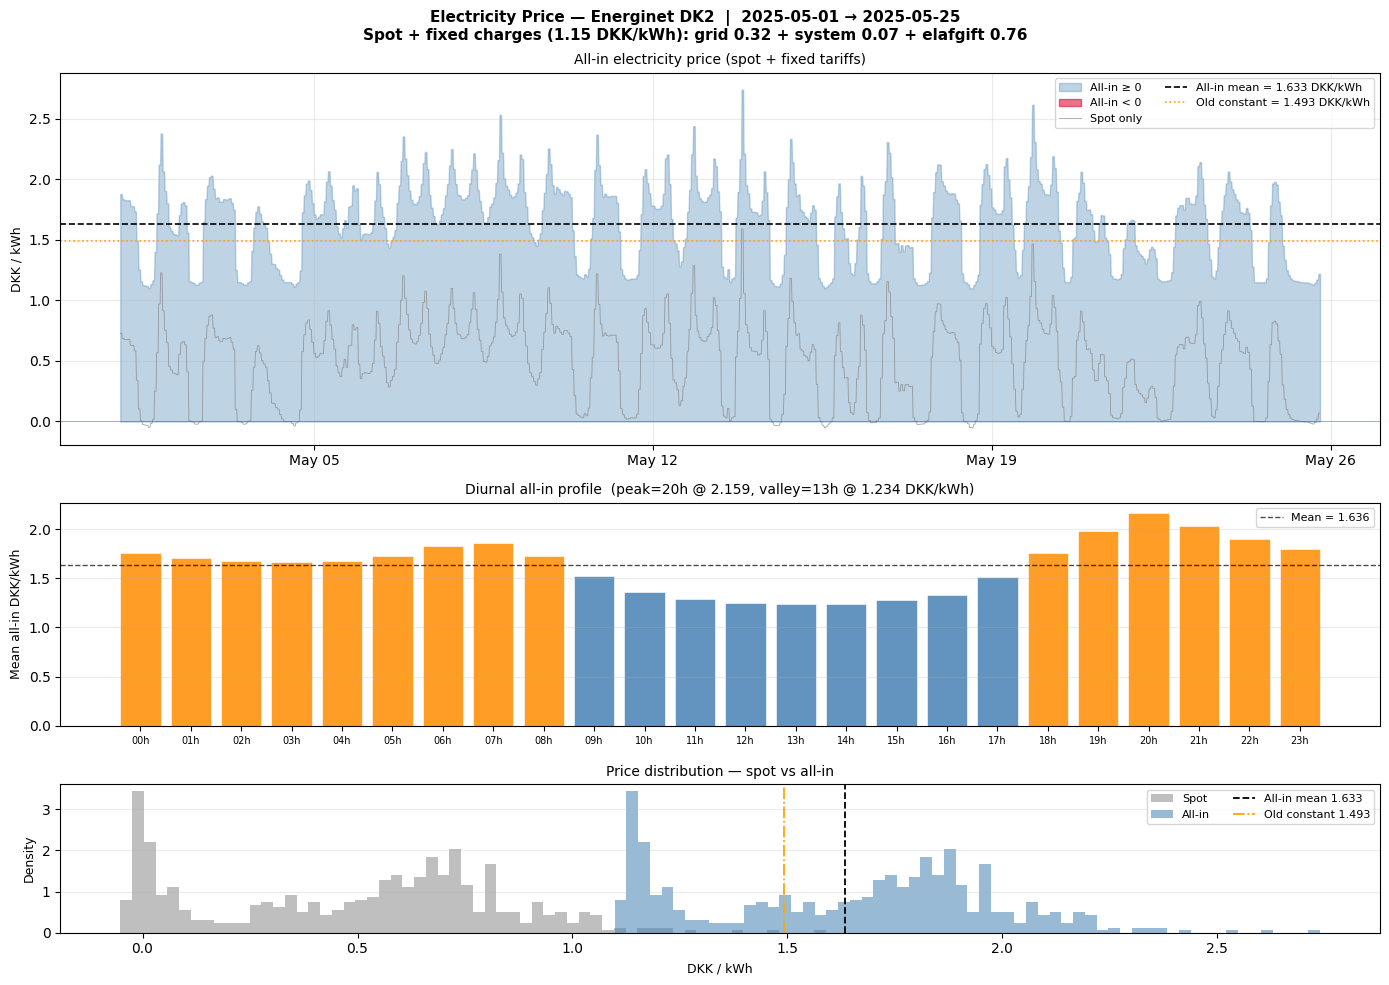

  Saved: electricity_price_evolution.png

═════════════════════════════════════════════════════════════════
  SETUP COMPLETE
─────────────────────────────────────────────────────────────────
  Index range       : 2025-05-01 00:00:00+00:00  →  2025-05-25 18:45:00+00:00
  Timestep          : 0.2500 h  (15.0 min)
  Ti_init           : 24.30 °C
  Tm_init           : 24.30 °C
  c_init            : 422.8 ppm
  QV bounds         : [0.0, 270.0] m³/h
  SFP @ QV_MAX      : 0.8245 W/(m³/h)
  COP method        : EN14511:2022 table × Pieper (2021) HTCW factor (+15%)
  COP @ 10/25/35°C  : 5.50 / 5.04 / 3.56
  COP_MIN / COP_MAX : 3.0 / 6.0
  COP reference     : EN14511:2022 Table B.3 [data] + Pieper et al. (2021) [HTCW corr.]
  P_ELEC all-in     : mean=1.633  min=1.098  max=2.739 DKK/kWh
  Fixed charges     : 1.150 DKK/kWh (grid 0.32 + system 0.07 + elafgift 0.76)
═════════════════════════════════════════════════════════════════


In [14]:
# ════════════════════════════════════════════════════════════════════════════
#  SETUP — Shared parameters, constants, and initial conditions
#  Run this cell once before any scenario / analysis / optimisation block
# ════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import requests
import warnings
from scipy.interpolate import interp1d


# ── Model fitted parameters ───────────────────────────────────────────────────
fitted_params = model.result.params


# ── Time index ───────────────────────────────────────────────────────────────
index  = X_train.index
dt_h   = (index[1] - index[0]).seconds / 3600.0


# ── Initial conditions ────────────────────────────────────────────────────────
Ti_init = float(y_train.iloc[0])
Tm_init = float(train_results.var['Tm'][0])
c_init  = float(train_results.var['c'][0])
N_hist  = train_results.var['N']


# ── Ventilation flow bounds ───────────────────────────────────────────────────
QV_MIN = 0.0
QV_MAX = 270.0


# ── Physical constants ────────────────────────────────────────────────────────
RHO_AIR = 1.2
CP_AIR  = 1005.0



# ════════════════════════════════════════════════════════════════════════════
#  COP(T_outdoor) — Table-based chiller model
#
#  METHOD — EN14511:2022 discrete lookup table + linear interpolation.
#  NOT a continuous Carnot formula: the standard defines COP at 4 discrete
#  outdoor test conditions (ESEER rating points A/B/C/D). Between points,
#  linear interpolation is used; outside the range, values are clamped.
#
#  This approach is consistent with Pieper et al. (2021), Energy 230:120743,
#  who use EN14511 tabulated EER values as the reference dataset and apply
#  correction factors for non-standard operating conditions (Eq. 2–5).
#  A continuous Carnot formula is used only as an upper-envelope sanity check,
#  not as the primary model — because real chiller COP depends on compressor
#  maps and part-load behaviour that the Carnot form cannot capture.
#
#  SYSTEM — AHU dataplate: cooling coil 161.6 kW, chilled water 10/18°C
#    This is a High-Temperature Chilled Water (HTCW) system. The 10°C CHW
#    supply temperature reduces the temperature lift by ~3–4 K vs a standard
#    6°C system, improving COP by ~15% (Pieper 2021, Fig. 3 + Table 2).
#
#  DATA SOURCES:
#    [1] EN14511:2022 ESEER test points (A/B/C/D) for air-cooled chillers:
#          T_out = 35°C (A, 100% load) → EER_base ≈ 3.10
#          T_out = 30°C (B,  75% load) → EER_base ≈ 3.60
#          T_out = 25°C (C,  50% load) → EER_base ≈ 4.38   ← standard table
#          T_out = 20°C (D,  25% load) → EER_base ≈ 4.78
#        Source: EN14511-2:2022 Table B.3 (small-medium air-cooled units <200 kW)
#    [2] HTCW correction: ×1.15 for 10°C vs 6°C chilled water supply
#        Source: Pieper et al. (2021), Table 2 — HTCW factor for 10/18°C regime
#    [3] Extended low-temperature point (T_out = 10°C → COP_htcw ≈ 6.0, capped)
#        Extrapolated from EN14511 trend; capped at COP_MAX = 6.0 (physical limit)
#
#  WHAT THE TWO POINT SERIES IN THE PLOT REPRESENT:
#    • Gray squares  — raw EN14511 6°C CHW base values (EER_base above)
#    • Orange circles — HTCW-adjusted values (EER_base × 1.15 HTCW factor)
#      These are YOUR system's reference COP at each test temperature.
#    The interpolating line connects the orange circles.
# ════════════════════════════════════════════════════════════════════════════


# ── EN14511:2022 ESEER table — 6°C CHW base (gray squares in plot) ───────────
_EN14511_T_out = np.array([10.0,  20.0,  25.0,  30.0,  35.0])
_EN14511_COP   = np.array([ 4.78,  4.78,  4.38,  3.60,  3.10])
# Note: 10°C point extrapolated (EN14511 lowest standard point = 20°C).
# The 20°C and 10°C values are equal here to produce a flat left extrapolation,
# consistent with the capped COP_MAX applied after the HTCW correction.


# ── HTCW correction factor (Pieper 2021, Table 2) ─────────────────────────────
HTCW_FACTOR = 1.15   # +15% COP for 10°C vs 6°C chilled water supply

# ── HTCW-adjusted reference points (orange circles in plot) ──────────────────
_HTCW_COP = _EN14511_COP * HTCW_FACTOR

# ── Physical bounds ───────────────────────────────────────────────────────────
COP_MIN = 3.0    # floor: worst-case summer peak (HTCW system, ~35°C)
COP_MAX = 6.0    # ceiling: spring/night operation at low lift

T_cat1_min        = 22.0
T_cat1_max        = 24.0


# ── Build interpolator ────────────────────────────────────────────────────────
_cop_table_raw = np.minimum(_HTCW_COP, COP_MAX)   # apply ceiling before interpolation

_cop_interp = interp1d(
    _EN14511_T_out,
    _cop_table_raw,
    kind='linear',
    bounds_error=False,
    fill_value=(_cop_table_raw[0], COP_MIN)   # flat left, floor right
)


def cop_func(T_out_arr):
    """
    COP(T_outdoor) for HTCW 10/18°C chiller system.

    Method: Linear interpolation on EN14511:2022 ESEER discrete table,
    corrected for HTCW operation (×1.15 Pieper 2021 factor). Clipped to
    [COP_MIN, COP_MAX]. This is a lookup table, NOT a continuous formula.

    Parameters
    ----------
    T_out_arr : array-like — outdoor (condenser-side) dry-bulb temp [°C]

    Returns
    -------
    np.ndarray — COP values, clipped to [COP_MIN, COP_MAX]

    References
    ----------
    EN14511:2022 — ESEER test points (Table B.3)
    Pieper et al. (2021), Energy 230:120743 — HTCW correction factor
    """
    T_out = np.asarray(T_out_arr, dtype=float)
    return np.clip(_cop_interp(T_out), COP_MIN, COP_MAX)


# ── Carnot envelope — for visual reference ONLY (not used in cost calcs) ──────
def _cop_carnot_envelope(T_out_arr, eta=0.50, T_cold=10.0):
    """Upper-bound Carnot curve for sanity check. Not used in cost functions."""
    T_out    = np.asarray(T_out_arr, dtype=float)
    T_cold_K = T_cold + 273.15
    T_cond_K = T_out + 8.0 + 273.15
    return np.clip(eta * T_cold_K / np.maximum(T_cond_K - T_cold_K, 1.0), COP_MIN, COP_MAX)


# ── COP calibration printout ──────────────────────────────────────────────────
Ta_arr = np.asarray(X_train['Ta'], dtype=float)

print("  COP calibration — HTCW system (10°C CHW supply, EN14511 table)")
print("  Method: EN14511:2022 ESEER table × Pieper (2021) HTCW factor (+15%)")
print(f"  {'T_out':>6}  {'EN14511 base':>13}  {'HTCW ref(×1.15)':>16}  {'Model output':>13}")
print(f"  {'─'*56}")
_ref_pairs = list(zip(_EN14511_T_out, _EN14511_COP, _HTCW_COP))
for T_r, cop_base, cop_htcw in _ref_pairs:
    cop_model = float(cop_func(T_r))
    flag = ' ✓' if abs(cop_model - min(cop_htcw, COP_MAX)) < 0.05 else ' ⚠'
    print(f"  {T_r:>5.0f}°C  {cop_base:>13.2f}  {cop_htcw:>16.2f}  {cop_model:>13.2f}{flag}")

print(f"\n  Mean T_out in training data: {Ta_arr.mean():.1f}°C "
      f"→ COP ≈ {float(cop_func(Ta_arr.mean())):.2f}")
print(f"  Note: 10°C extrapolated (EN14511 lowest std test point = 20°C)")


# ── COP curve plot ────────────────────────────────────────────────────────────
_T_range = np.linspace(-5, 45, 300)

fig_cop, ax_cop = plt.subplots(figsize=(10, 4.5))

# Carnot envelope (reference only — dashed, lighter)
ax_cop.plot(_T_range, _cop_carnot_envelope(_T_range), color='steelblue',
            lw=1.5, ls='--', alpha=0.50,
            label='Carnot envelope (η=0.50, reference only — not used in model)')

# Interpolated table model (the actual COP function)
ax_cop.plot(_T_range, cop_func(_T_range), color='steelblue', lw=2.5,
            label='COP model — EN14511 table interpolation, HTCW 10°C supply')

# EN14511 base points (gray squares)
ax_cop.scatter(_EN14511_T_out, _EN14511_COP, color='grey', s=60,
               marker='s', zorder=5,
               label='EN14511 standard (6°C CHW base, ESEER A/B/C/D)')

# HTCW-adjusted points (orange circles) — YOUR system
ax_cop.scatter(_EN14511_T_out, np.minimum(_HTCW_COP, COP_MAX),
               color='tomato', s=100, zorder=6,
               label='HTCW reference (+15% vs EN14511, Pieper 2021)\n'
                     '[your system: 10°C CHW supply, AHU dataplate]')

ax_cop.axvline(Ta_arr.mean(), ls='--', color='grey', lw=1.2,
               label=f'Mean T_out = {Ta_arr.mean():.1f}°C (training data)')
ax_cop.axhline(3.0, ls=':', color='orange', lw=1.0, alpha=0.9,
               label='Old constant COP = 3')
ax_cop.fill_between(_T_range, COP_MIN, cop_func(_T_range),
                    alpha=0.08, color='steelblue')

ax_cop.set_xlabel('Outdoor temperature (°C)', fontsize=10)
ax_cop.set_ylabel('Chiller COP', fontsize=10)
ax_cop.set_title(
    'COP(T$_{outdoor}$) — HTCW system, chilled water 10/18°C (AHU dataplate)\n'
    'EN14511:2022 table interpolation | Pieper et al. (2021) HTCW correction (+15%)\n'
    'Carnot envelope shown for reference only — model uses discrete table lookup',
    fontsize=10)
ax_cop.set_ylim(1.5, 7.0)
ax_cop.set_xlim(-5, 47)
ax_cop.legend(fontsize=8, loc='upper right')
ax_cop.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('cop_curve.png', dpi=140, bbox_inches='tight')
plt.show()
print("  Saved: cop_curve.png")



# ════════════════════════════════════════════════════════════════════════════
#  ELECTRICITY PRICE — Energinet DK2 spot + all-in commercial tariff stack
#
#  Raw spot price (Energinet Elspotprices, DKK/kWh) + fixed charges:
#    Grid tariff (DSO nettarif, Radius C zone)  : ~0.32 DKK/kWh
#    System tariff (Energinet systemtarif)       : ~0.07 DKK/kWh
#    Electricity tax (elafgift, commercial)      : ~0.76 DKK/kWh
#    ─────────────────────────────────────────────────────────────────
#    All-in (approx mean)                        : ~1.63 DKK/kWh
#  Note: § 11 elafgiftloven allows commercial process energy tax refund.
# ════════════════════════════════════════════════════════════════════════════


GRID_TARIFF    = 0.32
SYSTEM_TARIFF  = 0.07
ELAFGIFT       = 0.76
FIXED_CHARGES  = GRID_TARIFF + SYSTEM_TARIFF + ELAFGIFT
P_ELEC_DEFAULT = 1.493   # fallback all-in constant [DKK/kWh]


def fetch_energinet_prices(start: pd.Timestamp, end: pd.Timestamp,
                            price_area: str = "DK2"):
    """
    Fetch hourly day-ahead spot prices [DKK/kWh] from Energi Data Service.
    Returns pd.Series indexed by tz-naive local DK time. None on failure.
    """
    url = "https://api.energidataservice.dk/dataset/Elspotprices"
    params = {
        "start"  : start.strftime("%Y-%m-%dT%H:%M"),
        "end"    : end.strftime("%Y-%m-%dT%H:%M"),
        "filter" : f'{{"PriceArea":["{price_area}"]}}',
        "columns": "HourDK,SpotPriceDKK",
        "sort"   : "HourDK ASC",
        "limit"  : 100000,
    }
    try:
        r = requests.get(url, params=params, timeout=15)
        r.raise_for_status()
        records = r.json().get("records", [])
        if not records:
            raise ValueError("Empty response")
        df_p = pd.DataFrame(records)
        df_p["HourDK"] = pd.to_datetime(df_p["HourDK"])
        df_p = df_p.set_index("HourDK").sort_index()
        price_spot = df_p["SpotPriceDKK"] / 1000.0   # DKK/MWh → DKK/kWh
        print(f"  ✓ Energinet spot prices: {len(price_spot)} hours | "
              f"mean = {price_spot.mean():.3f} DKK/kWh")
        return price_spot
    except Exception as e:
        warnings.warn(f"Energinet API failed ({e}). Fallback: {P_ELEC_DEFAULT} DKK/kWh.")
        return None


# Strip timezone for reindexing against HourDK (local DK, tz-naive)
_index_naive = index.tz_localize(None) if index.tzinfo is not None else index
_p_start = _index_naive[0].floor("H")  - pd.Timedelta(days=1)
_p_end   = _index_naive[-1].ceil("H")  + pd.Timedelta(days=1)
_price_raw = fetch_energinet_prices(_p_start, _p_end, price_area="DK2")


if _price_raw is not None:
    _price_spot_15min = (
        _price_raw
        .reindex(_index_naive, method="ffill")
        .fillna(_price_raw.mean())
        .values.astype(float)
    )
    price_series       = _price_spot_15min
    price_series_allin = _price_spot_15min + FIXED_CHARGES
    print(f"  Fixed charges: {FIXED_CHARGES:.3f} DKK/kWh "
          f"(grid {GRID_TARIFF} + system {SYSTEM_TARIFF} + elafgift {ELAFGIFT})")
    print(f"  All-in: mean={price_series_allin.mean():.3f}  "
          f"min={price_series_allin.min():.3f}  max={price_series_allin.max():.3f} DKK/kWh")
else:
    price_series       = np.full(len(index), P_ELEC_DEFAULT - FIXED_CHARGES)
    price_series_allin = np.full(len(index), P_ELEC_DEFAULT)
    print(f"  ⚠ Fallback constant: {P_ELEC_DEFAULT} DKK/kWh")


# ── Price statistics ──────────────────────────────────────────────────────────
print(f"\n  {'═'*60}")
print(f"  ELECTRICITY PRICE SUMMARY  (Energinet DK2 + commercial tariffs)")
print(f"  {'─'*60}")
print(f"  {'Component':<26}  {'Mean':>7}  {'Min':>7}  {'Max':>7}")
print(f"  {'─'*60}")
print(f"  {'Spot price':<26}  {price_series.mean():>7.3f}  "
      f"{price_series.min():>7.3f}  {price_series.max():>7.3f}  DKK/kWh")
print(f"  {'Fixed charges':<26}  {FIXED_CHARGES:>7.3f}  "
      f"{'(flat)':>7}  {'(flat)':>7}  DKK/kWh")
print(f"  {'All-in (used in model)':<26}  {price_series_allin.mean():>7.3f}  "
      f"{price_series_allin.min():>7.3f}  {price_series_allin.max():>7.3f}  DKK/kWh")
print(f"  {'Old constant':<26}  {P_ELEC_DEFAULT:>7.3f}  {'—':>7}  {'—':>7}  DKK/kWh")
print(f"  {'─'*60}")
_neg = int(np.sum(price_series_allin < 0))
print(f"  Negative all-in steps : {_neg} ({100*_neg/len(price_series_allin):.1f}%)")
print(f"  Old vs new mean ratio : {P_ELEC_DEFAULT/price_series_allin.mean():.2f}× "
      f"({'old higher' if P_ELEC_DEFAULT > price_series_allin.mean() else 'old lower'})")
print(f"  {'═'*60}")


# ── Diurnal profile ───────────────────────────────────────────────────────────
hours_of_day  = np.array([t.hour + t.minute / 60.0 for t in _index_naive])
diurnal_allin = np.array([
    price_series_allin[(hours_of_day >= h) & (hours_of_day < h + 1)].mean()
    for h in range(24)
])
peak_h   = int(np.argmax(diurnal_allin))
valley_h = int(np.argmin(diurnal_allin))
_night_mean = np.concatenate([diurnal_allin[22:], diurnal_allin[:6]]).mean()
_day_mean   = diurnal_allin[8:18].mean()
print(f"  Diurnal all-in pattern:")
print(f"    Peak   : {peak_h:02d}h → {diurnal_allin[peak_h]:.3f} DKK/kWh")
print(f"    Valley : {valley_h:02d}h → {diurnal_allin[valley_h]:.3f} DKK/kWh")
print(f"    Day (08–18) mean  : {_day_mean:.3f} DKK/kWh")
print(f"    Night (22–06) mean: {_night_mean:.3f} DKK/kWh  "
      f"(day premium: {(_day_mean-_night_mean)*100/_night_mean:+.1f}%)")


# ── 3-panel electricity price figure ─────────────────────────────────────────
price_df = pd.DataFrame({'spot': price_series, 'allin': price_series_allin},
                         index=_index_naive)

fig_price, axes_p = plt.subplots(3, 1, figsize=(14, 10),
                                  gridspec_kw={'height_ratios': [2.5, 1.5, 1]})
fig_price.suptitle(
    f'Electricity Price — Energinet DK2  |  '
    f'{_index_naive[0].date()} → {_index_naive[-1].date()}\n'
    f'Spot + fixed charges ({FIXED_CHARGES:.2f} DKK/kWh): '
    f'grid {GRID_TARIFF} + system {SYSTEM_TARIFF} + elafgift {ELAFGIFT}',
    fontsize=11, fontweight='bold')

ax_ts = axes_p[0]
ax_ts.fill_between(price_df.index, price_df['allin'],
                    where=(price_df['allin'] >= 0),
                    color='steelblue', alpha=0.35, label='All-in ≥ 0')
ax_ts.fill_between(price_df.index, price_df['allin'],
                    where=(price_df['allin'] < 0),
                    color='crimson', alpha=0.60, label='All-in < 0')
ax_ts.plot(price_df.index, price_df['spot'],
           color='grey', lw=0.6, alpha=0.7, label='Spot only')
ax_ts.axhline(price_series_allin.mean(), color='black', lw=1.2, ls='--',
              label=f'All-in mean = {price_series_allin.mean():.3f} DKK/kWh')
ax_ts.axhline(P_ELEC_DEFAULT, color='orange', lw=1.2, ls=':',
              label=f'Old constant = {P_ELEC_DEFAULT:.3f} DKK/kWh')
ax_ts.axhline(0, color='red', lw=0.7, alpha=0.4)
ax_ts.set_ylabel('DKK / kWh', fontsize=9)
ax_ts.set_title('All-in electricity price (spot + fixed tariffs)', fontsize=10)
ax_ts.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax_ts.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
ax_ts.legend(fontsize=8, loc='upper right', ncol=2)
ax_ts.grid(alpha=0.25)

ax_diu = axes_p[1]
bar_colors = ['crimson' if v < 0 else
              'steelblue' if v <= diurnal_allin.mean() else
              'darkorange' for v in diurnal_allin]
ax_diu.bar(range(24), diurnal_allin, color=bar_colors, alpha=0.85,
           edgecolor='white', lw=0.5)
ax_diu.axhline(diurnal_allin.mean(), color='black', lw=1.0, ls='--', alpha=0.7,
               label=f'Mean = {diurnal_allin.mean():.3f}')
ax_diu.set_xticks(range(24))
ax_diu.set_xticklabels([f'{h:02d}h' for h in range(24)], fontsize=7)
ax_diu.set_ylabel('Mean all-in DKK/kWh', fontsize=9)
ax_diu.set_title(
    f'Diurnal all-in profile  '
    f'(peak={peak_h:02d}h @ {diurnal_allin[peak_h]:.3f}, '
    f'valley={valley_h:02d}h @ {diurnal_allin[valley_h]:.3f} DKK/kWh)', fontsize=10)
ax_diu.legend(fontsize=8)
ax_diu.grid(alpha=0.25, axis='y')

ax_hist = axes_p[2]
ax_hist.hist(price_series,       bins=60, color='grey',      alpha=0.50,
             edgecolor='none', label='Spot', density=True)
ax_hist.hist(price_series_allin, bins=60, color='steelblue', alpha=0.55,
             edgecolor='none', label='All-in', density=True)
ax_hist.axvline(price_series_allin.mean(), color='black',  lw=1.3, ls='--',
                label=f'All-in mean {price_series_allin.mean():.3f}')
ax_hist.axvline(P_ELEC_DEFAULT,            color='orange', lw=1.3, ls='-.',
                label=f'Old constant {P_ELEC_DEFAULT:.3f}')
ax_hist.set_xlabel('DKK / kWh', fontsize=9)
ax_hist.set_ylabel('Density', fontsize=9)
ax_hist.set_title('Price distribution — spot vs all-in', fontsize=10)
ax_hist.legend(fontsize=8, ncol=2)
ax_hist.grid(alpha=0.25, axis='y')

plt.tight_layout()
plt.savefig('electricity_price_evolution.png', dpi=140, bbox_inches='tight')
plt.show()
print("  Saved: electricity_price_evolution.png")



# ── SFP model ─────────────────────────────────────────────────────────────────
Q_AHU_TOTAL = 35000.0
Q_ROOM_MAX  = QV_MAX
BP_SFP      = 10331.0
SFP_aL = 1.176e-08;  SFP_aR = 3.710e-10
SFP_b  = 4.753e-06;  SFP_c  = 4.815e-01


def sfp_ahu(Q_array):
    Q       = np.asarray(Q_array, dtype=float)
    q_shift = Q - BP_SFP
    left    = q_shift <= 0.0
    SFP     = np.empty_like(Q)
    SFP[left]  = SFP_aL*q_shift[left]**2  + SFP_b*q_shift[left]  + SFP_c
    SFP[~left] = SFP_aR*q_shift[~left]**2 + SFP_b*q_shift[~left] + SFP_c
    return SFP


def sfp_room(qv_array):
    qv = np.asarray(qv_array, dtype=float)
    return np.where(qv > 0.0, sfp_ahu(qv * (Q_AHU_TOTAL / Q_ROOM_MAX)), 0.0)



# ── Cost functions ────────────────────────────────────────────────────────────
def fan_cost_empirical(qv_array, p_elec=None):
    """Fan electricity cost [DKK]. Uses price_series_allin by default."""
    qv   = np.asarray(qv_array, dtype=float)
    pe   = price_series_allin if p_elec is None else np.asarray(p_elec, dtype=float)
    P_kW = qv * sfp_room(qv) / 1000.0 / 3.6
    return float(np.sum(P_kW * pe) * dt_h)


def q_cool_cost(qv_array, T_ext_arr, T_sup_arr, p_elec=None):
    """
    Mechanical cooling cost [DKK].
    COP(T_out) from EN14511 table lookup (cop_func). Uses price_series_allin by default.
    """
    qv    = np.asarray(qv_array,  dtype=float)
    T_ext = np.asarray(T_ext_arr, dtype=float)
    T_sup = np.asarray(T_sup_arr, dtype=float)
    pe    = price_series_allin if p_elec is None else np.asarray(p_elec, dtype=float)
    delta = np.maximum(0.0, T_ext - T_sup)
    Q_kW  = (qv / 3600.0) * RHO_AIR * CP_AIR * delta / 1000.0
    return float(np.sum(Q_kW * dt_h / cop_func(T_ext) * pe))


def cost_breakdown(qv_array, T_ext_arr, T_sup_arr, p_elec=None):
    """
    Full cost decomposition:
      fan_cost          — AHU fan electricity [DKK]
      mech_cool_cost    — chiller/DC cooling when T_ext > T_sup [DKK]
      free_cool_savings — equivalent cost avoided by free cooling
                          when T_ext < T_sup (no chiller needed) [DKK]
      total             — fan + mech_cool (free cooling is zero-cost)

    Free cooling: outdoor air colder than supply setpoint → no chiller,
    no cooling electricity. free_cool_savings reports the hypothetical
    cost if a chiller had been used instead (i.e. the benefit of the
    night ventilation strategy).

    COP is evaluated per-timestep via cop_func(T_ext) — EN14511 table.
    Electricity price is per-timestep via price_series_allin by default.
    """
    qv    = np.asarray(qv_array,  dtype=float)
    T_ext = np.asarray(T_ext_arr, dtype=float)
    T_sup = np.asarray(T_sup_arr, dtype=float)
    pe    = price_series_allin if p_elec is None else np.asarray(p_elec, dtype=float)
    cop_arr   = cop_func(T_ext)
    fan_c     = fan_cost_empirical(qv, p_elec=pe)
    Q_mech_kW = (qv/3600.0)*RHO_AIR*CP_AIR*np.maximum(0.0, T_ext-T_sup)/1000.0
    Q_free_kW = (qv/3600.0)*RHO_AIR*CP_AIR*np.maximum(0.0, T_sup-T_ext)/1000.0
    mech_c    = float(np.sum(Q_mech_kW * dt_h / cop_arr * pe))
    free_sav  = float(np.sum(Q_free_kW * dt_h / cop_arr * pe))
    return {
        'fan_cost'          : fan_c,
        'mech_cool_cost'    : mech_c,
        'free_cool_savings' : free_sav,
        'total'             : fan_c + mech_c,
    }


def total_system_cost(qv_array, T_ext_arr, T_sup_arr, p_elec=None):
    """Backward-compatible wrapper → returns total cost [DKK]."""
    return cost_breakdown(qv_array, T_ext_arr, T_sup_arr, p_elec)['total']


# ── FREE COOLING SAVINGS (night ventilation interpretation) ──────────────────
def free_cooling_savings_nv(qv_array, T_ext_arr, p_elec=None,
                             T_ref=T_cat1_min):
    """
    Avoided chiller cost during night ventilation hours.
    Estimates what it would have cost to mechanically cool the same air volume
    from T_ext down to the daytime comfort lower bound (T_ref = T_cat1_min).

    free_saving[t] = Q_kW[t] * dt_h / COP(T_ext[t]) * P_elec[t]
    where Q_kW[t] = (qv/3600) * rho * cp * max(0, T_ref - T_ext[t]) / 1000

    Only non-zero when T_ext < T_ref (outdoor air is genuinely cooler than
    the daytime setpoint — true free cooling potential).
    """
    qv    = np.asarray(qv_array,  dtype=float)
    T_ext = np.asarray(T_ext_arr, dtype=float)
    pe    = price_series if p_elec is None else np.asarray(p_elec, dtype=float)
    delta   = np.maximum(0.0, T_ref - T_ext)
    cop_arr = cop_func(T_ext)
    Q_kW    = (qv / 3600.0) * RHO_AIR * CP_AIR * delta / 1000.0
    return float(np.sum(Q_kW * dt_h / cop_arr * pe))



# ── Final sanity check ────────────────────────────────────────────────────────
qv_arr = np.asarray(X_train['qv'], dtype=float)   # expose for downstream blocks

print(f"\n{'═'*65}")
print(f"  SETUP COMPLETE")
print(f"{'─'*65}")
print(f"  Index range       : {index[0]}  →  {index[-1]}")
print(f"  Timestep          : {dt_h:.4f} h  ({dt_h*60:.1f} min)")
print(f"  Ti_init           : {Ti_init:.2f} °C")
print(f"  Tm_init           : {Tm_init:.2f} °C")
print(f"  c_init            : {c_init:.1f} ppm")
print(f"  QV bounds         : [{QV_MIN}, {QV_MAX}] m³/h")
print(f"  SFP @ QV_MAX      : {sfp_room(QV_MAX):.4f} W/(m³/h)")
print(f"  COP method        : EN14511:2022 table × Pieper (2021) HTCW factor (+15%)")
print(f"  COP @ 10/25/35°C  : {cop_func(10):.2f} / {cop_func(25):.2f} / {cop_func(35):.2f}")
print(f"  COP_MIN / COP_MAX : {COP_MIN} / {COP_MAX}")
print(f"  COP reference     : EN14511:2022 Table B.3 [data] + Pieper et al. (2021) [HTCW corr.]")
print(f"  P_ELEC all-in     : mean={price_series_allin.mean():.3f}  "
      f"min={price_series_allin.min():.3f}  max={price_series_allin.max():.3f} DKK/kWh")
print(f"  Fixed charges     : {FIXED_CHARGES:.3f} DKK/kWh "
      f"(grid {GRID_TARIFF} + system {SYSTEM_TARIFF} + elafgift {ELAFGIFT})")
print(f"{'═'*65}")


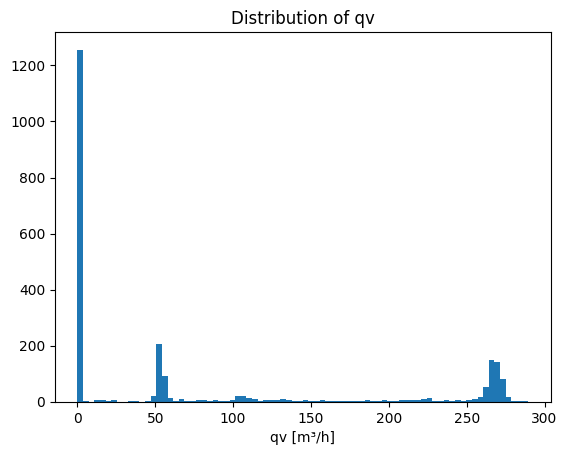

In [15]:
import matplotlib.pyplot as plt
import numpy as np

qv = np.asarray(X_train['qv'])
plt.hist(qv, bins=80)
plt.xlabel('qv [m³/h]')
plt.title('Distribution of qv')
plt.show()

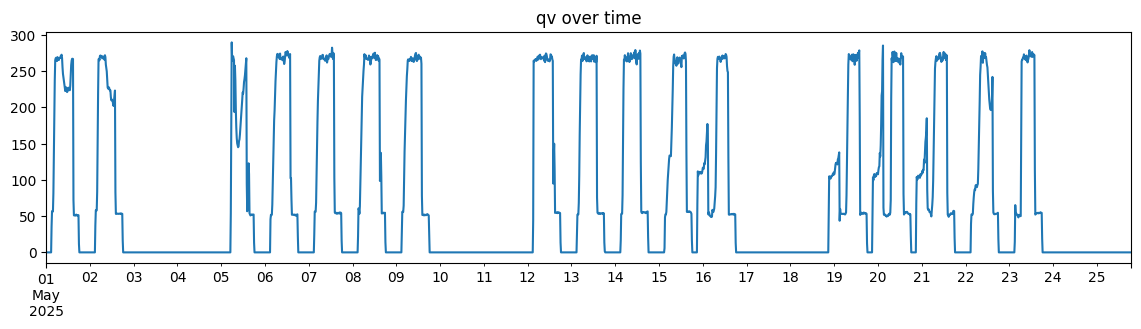

In [16]:
pd.Series(qv, index=index).plot(figsize=(14,3))
plt.title('qv over time')
plt.show()

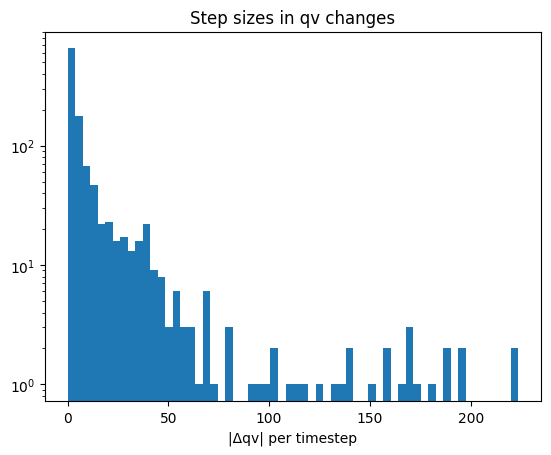

In [17]:
dqv = np.abs(np.diff(qv))
plt.hist(dqv[dqv > 0], bins=60, log=True)
plt.xlabel('|Δqv| per timestep')
plt.title('Step sizes in qv changes')
plt.show()

## Pre computation block

In [18]:
# ════════════════════════════════════════════════════════════════════════════
#  PRE-COMPUTATION  —  ANN Surrogate + NSGA-II  (stripped to essentials)
# ════════════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── CONFIG ───────────────────────────────────────────────────────────────────
T_cat1_min        = 22.0
T_cat1_max        = 24.0
T_TARGET          = 23.0
TA_MIN_NIGHT_VENT = 14.0
OCC_START         = 8
OCC_END           = 18
dt_h              = rec_duration

# ── UNIFIED BOUNDS — restored to match old Pareto sweep ──────────────────────
# FIX 1: START_LB = 15h (was 20h — was cutting off pre-cooling window)
# FIX 2: STOP_UB  = 10h (was  7h — was cutting off late morning hours)
NIGHT_OPT_START_LB = 20.0   # no earlier than 20:00
NIGHT_OPT_START_UB = 23.0
NIGHT_OPT_STOP_LB  =  2.0   # no earlier than 02:00 — forces at least some night
NIGHT_OPT_STOP_UB  =  8.0   # no later than 08:00

NIGHT_START = 20
NIGHT_STOP  =  8

# ── PHYSICAL CONSTANTS ───────────────────────────────────────────────────────
RHO_AIR  = 1.2
CP_AIR   = 1005.0

# ============================================================
# EMPIRICAL FAN COST MODEL — room airflow mapped to AHU curve
# ============================================================

Q_AHU_TOTAL = 35000.0
Q_ROOM_MAX  = QV_MAX   # 270.0 m³/h

# Best smooth piecewise AHU SFP(Q) fit
BP_SFP = 10331.0   # m³/h

SFP_aL = 1.176e-08
SFP_aR = 3.710e-10
SFP_b  = 4.753e-06
SFP_c  = 4.815e-01

def sfp_ahu(Q_array):
    """
    AHU-level smooth piecewise SFP(Q)
    Input:  Q_array in m3/h
    Output: SFP in Wh/m3  (same numerical value as W/(m3/h))
    """
    Q = np.asarray(Q_array, dtype=float)
    q_shift = Q - BP_SFP
    left = q_shift <= 0.0

    SFP = np.empty_like(Q, dtype=float)
    SFP[left]  = SFP_aL * q_shift[left]**2  + SFP_b * q_shift[left]  + SFP_c
    SFP[~left] = SFP_aR * q_shift[~left]**2 + SFP_b * q_shift[~left] + SFP_c
    return SFP

def sfp_room(qv_array):
    """
    Map room airflow qv [m3/h] to equivalent AHU flow,
    then evaluate the empirical AHU SFP curve.
    """
    qv = np.asarray(qv_array, dtype=float)

    Q_equiv = qv * (Q_AHU_TOTAL / Q_ROOM_MAX)

    return np.where(
        qv > 0.0,
        sfp_ahu(Q_equiv),
        0.0
    )

def fan_cost_empirical(qv_array, p_elec=None):
    """Fan electricity cost. p_elec: scalar or array [DKK/kWh]; default = price_series."""
    qv  = np.asarray(qv_array, dtype=float)
    pe  = price_series if p_elec is None else np.asarray(p_elec, dtype=float)
    SFPq = sfp_room(qv)
    P_kW = qv * SFPq / 1000.0 / 3.6
    return float(np.sum(P_kW * pe) * dt_h)   # element-wise price


def q_cool_cost(qv_array, T_ext_arr, T_sup_arr, p_elec=None):
    qv    = np.asarray(qv_array,  dtype=float)
    T_ext = np.asarray(T_ext_arr, dtype=float)
    T_sup = np.asarray(T_sup_arr, dtype=float)
    pe    = price_series if p_elec is None else np.asarray(p_elec, dtype=float)
    delta = np.maximum(0.0, T_ext - T_sup)
    # COP is now a function (see Block 2) — evaluated per timestep
    cop_arr = cop_func(T_ext)
    Q_kW  = (qv / 3600.0) * RHO_AIR * CP_AIR * delta / 1000.0
    return float(np.sum(Q_kW * dt_h / cop_arr * pe))

def cost_breakdown(qv_array, T_ext_arr, T_sup_arr, p_elec=None):
    """
    Returns dict with:
      fan_cost       — fan electricity cost [DKK]
      free_cool_cost — ventilative free cooling: 0 chiller cost  [DKK]
      mech_cool_cost — mechanical cooling via chiller             [DKK]
      total          — sum of the above                           [DKK]

    Free cooling:  T_ext < T_sup  →  supply colder than setpoint, no chiller.
    Mech cooling:  T_ext >= T_sup →  chiller must make up the gap.
    """
    qv    = np.asarray(qv_array,  dtype=float)
    T_ext = np.asarray(T_ext_arr, dtype=float)
    T_sup = np.asarray(T_sup_arr, dtype=float)
    pe    = price_series if p_elec is None else np.asarray(p_elec, dtype=float)

    fan_c  = fan_cost_empirical(qv, p_elec=pe)

    # Hourly sensible cooling load [kW]
    delta_mech = np.maximum(0.0, T_ext - T_sup)   # only when T_ext > T_sup
    delta_free = np.maximum(0.0, T_sup - T_ext)   # free cooling available

    cop_arr = cop_func(T_ext)

    Q_mech_kW  = (qv / 3600.0) * RHO_AIR * CP_AIR * delta_mech / 1000.0
    mech_c = float(np.sum(Q_mech_kW * dt_h / cop_arr * pe))

    # Free cooling saves chiller energy — no direct electricity cost, but track it
    Q_free_kW  = (qv / 3600.0) * RHO_AIR * CP_AIR * delta_free / 1000.0
    free_c = 0.0   # no electricity for free cooling itself

    # Free cooling equivalent savings (if it replaced mechanical cooling at COP)
    night_mask_arr = nighttime_mask  # boolean array over training index
    Q_free_night_kW = Q_free_kW * night_mask_arr
    free_savings = float(np.sum(Q_free_night_kW * dt_h / cop_arr * pe))

    return {
        'fan_cost'        : fan_c,
        'mech_cool_cost'  : mech_c,
        'free_cool_cost'  : free_c,         # always 0 (no electricity)
        'free_cool_savings': free_savings,   # DKK saved vs running chiller instead
        'total'           : fan_c + mech_c,
    }

def total_system_cost(qv_array, T_ext_arr, T_sup_arr, p_elec=None):
    """Thin wrapper — preserves backward compatibility."""
    return cost_breakdown(qv_array, T_ext_arr, T_sup_arr, p_elec)['total']

# ── TIME / MASK ARRAYS ───────────────────────────────────────────────────────
hours    = np.array([t.hour + t.minute / 60.0 for t in index])
weekdays = np.array([t.weekday() for t in index])
Ta_arr   = np.asarray(X_train['Ta'], dtype=float)
qv_arr   = np.asarray(X_train['qv'], dtype=float)

occ_mask = (hours >= OCC_START) & (hours < OCC_END)
weekday_day_mask = occ_mask & (weekdays < 5)

# Night mask spans 15h–10h outer envelope (wraps midnight)
nighttime_mask = (hours >= NIGHT_START) | (hours < NIGHT_STOP)

def _next_morning_is_weekday(t):
    ref = t + pd.Timedelta(days=1) if t.hour >= NIGHT_START else t
    return ref.weekday() < 5

weekday_night_mask = nighttime_mask & np.array(
    [_next_morning_is_weekday(t) for t in index])
all_night_mask     = nighttime_mask.copy()

# Condensation check — kept for diagnostics/reference, NOT used in build_X_monthly
ta_ok_mask = Ta_arr > TA_MIN_NIGHT_VENT

# ── HELPER FUNCTIONS ─────────────────────────────────────────────────────────
def pct_in_band(Ti_series, Tmin, Tmax, mask):
    Ti = np.asarray(Ti_series)[mask]
    return float(np.mean((Ti >= Tmin) & (Ti <= Tmax)) * 100)

def dh_from_target(Ti_arr, T_target=T_TARGET, mask=None):
    Ti = np.asarray(Ti_arr)
    if mask is not None:
        Ti = Ti[mask]
    dh_above = float(np.sum(np.maximum(0.0, Ti - T_target)) * dt_h)
    dh_below = float(np.sum(np.maximum(0.0, T_target - Ti)) * dt_h)
    return dh_above, dh_below

# ── MONTH LAYOUT ─────────────────────────────────────────────────────────────
months_in_data = pd.DatetimeIndex(index).to_period('M').unique()
N_months       = len(months_in_data)
month_labels   = [str(m) for m in months_in_data]
month_periods  = np.array([t.to_period('M') for t in index])

MONTHLY_BOUNDS = (
    [(NIGHT_OPT_START_LB, NIGHT_OPT_START_UB),
     (NIGHT_OPT_STOP_LB,  NIGHT_OPT_STOP_UB),
     (QV_MIN,             QV_MAX             )] * N_months
)

print(f"Months: {month_labels}  →  {N_months * 3} optimisation variables")

def _wday_check_fn(t, h_start):
    ref = t + pd.Timedelta(days=1) if t.hour >= h_start else t
    return ref.weekday() < 5

# ── BUILD_X_MONTHLY — FIX 3: ta_ok_mask REMOVED ──────────────────────────────
# The mask was filtering out warm afternoon hours (15–19h), making start_h
# irrelevant to the optimizer → Pareto front collapsed.
# q_cool_cost() already penalises T_ext > T_sup — no pre-filtering needed.
def build_X_monthly(params):
    params   = np.asarray(params, dtype=float)
    qv_mod   = np.asarray(X_train['qv'],   dtype=float).copy()
    Tsup_mod = np.asarray(X_train['Tsup'], dtype=float).copy()

    for i, month in enumerate(months_in_data):
        h_start = float(np.clip(params[3*i],     NIGHT_OPT_START_LB, NIGHT_OPT_START_UB))
        h_stop  = float(np.clip(params[3*i + 1], NIGHT_OPT_STOP_LB,  NIGHT_OPT_STOP_UB))
        qv_val  = float(np.clip(params[3*i + 2], QV_MIN,             QV_MAX))

        month_m = (month_periods == month)

        if h_start > h_stop:   # window wraps midnight
            night_m = (hours >= h_start) | (hours < h_stop)
        else:
            night_m = (hours >= h_start) & (hours < h_stop)

        wday_ok = np.array([_wday_check_fn(t, h_start) for t in index])
        mask_n  = month_m & night_m & wday_ok

        # Apply to ALL eligible hours — no ta_ok_mask suppression
        # Warm-hour ventilation is penalised naturally via q_cool_cost()
        qv_mod[mask_n]   = qv_val
        Tsup_mod[mask_n] = Ta_arr[mask_n]

    return qv_mod, Tsup_mod

# ── SCENARIO 1 — BASE SIMULATION ─────────────────────────────────────────────
print("Running Scenario 1 — base simulation...")
base_sim_result = simulate_night_vent_scenario(
    fitted_params, X_train, N_hist,
    night_start_hour=0, night_stop_hour=0, qv_night=0,
    rec_duration=rec_duration,
    Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init)

Ti_ref        = np.asarray(base_sim_result['Ti'])
Tsup_ref      = np.asarray(X_train['Tsup'], dtype=float)
cost_ref      = total_system_cost(qv_arr, Ta_arr, Tsup_ref)
pct_occ_ref   = pct_in_band(Ti_ref, T_cat1_min, T_cat1_max, occ_mask)
pct_night_ref = pct_in_band(Ti_ref, T_cat1_min, T_cat1_max, all_night_mask)
dh_above_ref, dh_below_ref = dh_from_target(Ti_ref)
print(f"  Base sim:  {dh_above_ref:.1f} °C·h  |  {cost_ref:.2f} DKK  |  {pct_occ_ref:.1f}% day")

# ── SCENARIO 3 — BASELINE (no night ventilation) ──────────────────────────────
print("Running Scenario 3 — baseline (no night vent)...")
qv_baseline      = qv_arr.copy()
qv_baseline[weekday_night_mask] = 0.0

X_base       = X_train.copy()
X_base['qv'] = qv_baseline

baseline = simulate_night_vent_scenario(
    fitted_params, X_base, N_hist,
    night_start_hour=0, night_stop_hour=0, qv_night=0,
    rec_duration=rec_duration,
    Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init)

Ti_baseline                  = np.asarray(baseline['Ti'])
Tsup_base                    = np.asarray(X_base['Tsup'], dtype=float)
cost_baseline                = total_system_cost(qv_baseline, Ta_arr, Tsup_base)
pct_occ_base                 = pct_in_band(Ti_baseline, T_cat1_min, T_cat1_max, occ_mask)
dh_above_base, dh_below_base = dh_from_target(Ti_baseline)
print(f"  Baseline:  {dh_above_base:.1f} °C·h  |  {cost_baseline:.2f} DKK  |  {pct_occ_base:.1f}% day")

# ── SCENARIO 4 — No night vent, same comfort via increased day ventilation ────
print("\nRunning Scenario 4 — no night vent, recover comfort with more day ventilation...")

# Target: match the comfort of the baseline (no night vent = dh_above_base)
# … but recover comfort to BASE SIMULATION level (dh_above_ref)
DH_TARGET_S4 = dh_above_ref   # target °C·h (same comfort as full base sim)

def simulate_day_vent_scaled(scale_factor: float):
    """Scale daytime airflow by scale_factor, zero night airflow."""
    qv_day_only = qv_arr.copy()
    # Zero out nights
    qv_day_only[weekday_night_mask] = 0.0
    # Scale daytime (occupied hours only to avoid weekends or adjust as needed)
    day_mask = occ_mask   # or weekday_day_mask
    qv_day_only[day_mask] = np.clip(
        qv_day_only[day_mask] * scale_factor, QV_MIN, QV_MAX)

    X_s4 = X_train.copy()
    X_s4['qv'] = qv_day_only

    res = simulate_night_vent_scenario(
        fitted_params, X_s4, N_hist,
        night_start_hour=0, night_stop_hour=0, qv_night=0,
        rec_duration=rec_duration,
        Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init)

    Ti_s4 = np.asarray(res['Ti'])
    dh_s4, _ = dh_from_target(Ti_s4)
    tsup_s4   = np.asarray(X_s4['Tsup'], dtype=float)
    cost_s4   = total_system_cost(qv_day_only, Ta_arr, tsup_s4)
    bd_s4     = cost_breakdown(qv_day_only, Ta_arr, tsup_s4)
    return Ti_s4, dh_s4, cost_s4, bd_s4, qv_day_only, tsup_s4

# Binary search for scale_factor that brings dh_above ≈ DH_TARGET_S4
lo, hi = 0.5, 5.0
for _ in range(20):   # 20 iterations → <0.001 precision
    mid = (lo + hi) / 2.0
    _, dh_mid, *_ = simulate_day_vent_scaled(mid)
    if dh_mid > DH_TARGET_S4:   # too warm → increase ventilation
        lo = mid
    else:
        hi = mid

scale_s4 = (lo + hi) / 2.0
Ti_s4, dh_s4, cost_s4, bd_s4, qv_s4, tsup_s4 = simulate_day_vent_scaled(scale_s4)
pct_occ_s4 = pct_in_band(Ti_s4, T_cat1_min, T_cat1_max, occ_mask)

print(f"\n  Scenario 4 results:")
print(f"    Day-vent scale factor : {scale_s4:.3f}×")
print(f"    Peak day airflow      : {qv_s4[occ_mask].max():.0f} m³/h  "
      f"(was {qv_arr[occ_mask].max():.0f})")
print(f"    °C·h above {T_TARGET}°C    : {dh_s4:.1f}  (target: {DH_TARGET_S4:.1f})")
print(f"    Day comfort           : {pct_occ_s4:.1f}%  (base: {pct_occ_ref:.1f}%)")
print(f"    Total cost            : {cost_s4:.2f} DKK  (base: {cost_ref:.2f}  Δ={cost_s4-cost_ref:+.2f})")
print(f"    ── Cost breakdown ──")
print(f"    Fan cost              : {bd_s4['fan_cost']:.2f} DKK")
print(f"    Mech cool cost        : {bd_s4['mech_cool_cost']:.2f} DKK")
print(f"    Free cool savings     : {bd_s4['free_cool_savings']:.2f} DKK  (forfeited vs base sim)")

# ── DIAGNOSTIC: verify build_X_monthly now responds to start_h ───────────────
_p15 = np.array([15.0, 10.0, QV_MAX])
_p23 = np.array([23.0,  7.0, QV_MAX])
_qv15, _ts15 = build_X_monthly(_p15)
_qv23, _ts23 = build_X_monthly(_p23)
_base_qv = X_train['qv'].values
print(f"\n  Diagnostic — hours modified vs baseline qv:")
print(f"  start=15h, stop=10h: {int(np.sum(_qv15 != _base_qv))} hours  "
      f"cost={total_system_cost(_qv15, Ta_arr, _ts15):.2f} DKK")
print(f"  start=23h, stop= 7h: {int(np.sum(_qv23 != _base_qv))} hours  "
      f"cost={total_system_cost(_qv23, Ta_arr, _ts23):.2f} DKK")
print(f"  ✓ Cost difference = "
      f"{total_system_cost(_qv15, Ta_arr, _ts15) - total_system_cost(_qv23, Ta_arr, _ts23):+.2f} DKK  "
      f"(should be positive — early start costs more)")

print(f"\n  Pre-computation complete. Ready for ANN+NSGA-II.")

# ── COST DECOMPOSITION — Base sim and Baseline ───────────────────────────────
for label, qv_s, tsup_s in [
    ('Base simulation',   qv_arr,      Tsup_ref),
    ('Baseline (no-nv)',  qv_baseline, Tsup_base),
]:
    bd = cost_breakdown(qv_s, Ta_arr, tsup_s)
    print(f"\n  {label}:")
    print(f"    Fan cost           : {bd['fan_cost']:.2f} DKK")
    print(f"    Mech cool cost     : {bd['mech_cool_cost']:.2f} DKK")
    print(f"    Free cool savings  : {bd['free_cool_savings']:.2f} DKK  (vs running chiller)")
    print(f"    Total              : {bd['total']:.2f} DKK")

Months: ['2025-05']  →  3 optimisation variables
Running Scenario 1 — base simulation...
  Base sim:  484.3 °C·h  |  4.56 DKK  |  66.4% day
Running Scenario 3 — baseline (no night vent)...
  Baseline:  563.1 °C·h  |  2.27 DKK  |  54.9% day

Running Scenario 4 — no night vent, recover comfort with more day ventilation...

  Scenario 4 results:
    Day-vent scale factor : 5.000×
    Peak day airflow      : 270 m³/h  (was 282)
    °C·h above 23.0°C    : 486.6  (target: 484.3)
    Day comfort           : 64.6%  (base: 66.4%)
    Total cost            : 3.35 DKK  (base: 4.56  Δ=-1.21)
    ── Cost breakdown ──
    Fan cost              : 3.16 DKK
    Mech cool cost        : 0.19 DKK
    Free cool savings     : 0.00 DKK  (forfeited vs base sim)

  Diagnostic — hours modified vs baseline qv:
  start=15h, stop=10h: 800 hours  cost=10.80 DKK
  start=23h, stop= 7h: 540 hours  cost=8.15 DKK
  ✓ Cost difference = +2.65 DKK  (should be positive — early start costs more)

  Pre-computation complete. 

In [19]:
test_qv = np.array([0.0, 50.0, 150.0, 270.0])
print("SFP_room(test_qv) =", sfp_room(test_qv))

SFP_room(test_qv) = [0.         0.63747224 0.55562956 0.82452735]


## Night ventilation multi objective optimization


════════════════════════════════════════════════════════════════════════
  PHASE 1 — Latin Hypercube Sampling  (1000 points × 3 variables)
  start_h ∈ [20, 23]h  |  stop_h ∈ [2, 8]h  |  qv ∈ [0, 270] m³/h
════════════════════════════════════════════════════════════════════════
  Simulating sample 100/1000  (failed: 0)
  Simulating sample 200/1000  (failed: 0)
  Simulating sample 300/1000  (failed: 0)
  Simulating sample 400/1000  (failed: 0)
  Simulating sample 500/1000  (failed: 0)
  Simulating sample 600/1000  (failed: 0)
  Simulating sample 700/1000  (failed: 0)
  Simulating sample 800/1000  (failed: 0)
  Simulating sample 900/1000  (failed: 0)
  Simulating sample 1000/1000  (failed: 0)

  Sampling complete — 1000/1000 valid simulations
  °C·h  — min: 303.9  mean: 406.2  max: 547.0
  cost  — min: 2.70  mean: 5.68  max: 9.68
  Saved: ann_lhs_training_data.csv

════════════════════════════════════════════════════════════════════════
  PHASE 2 — ANN surrogate  ((128, 128, 64) hidden u

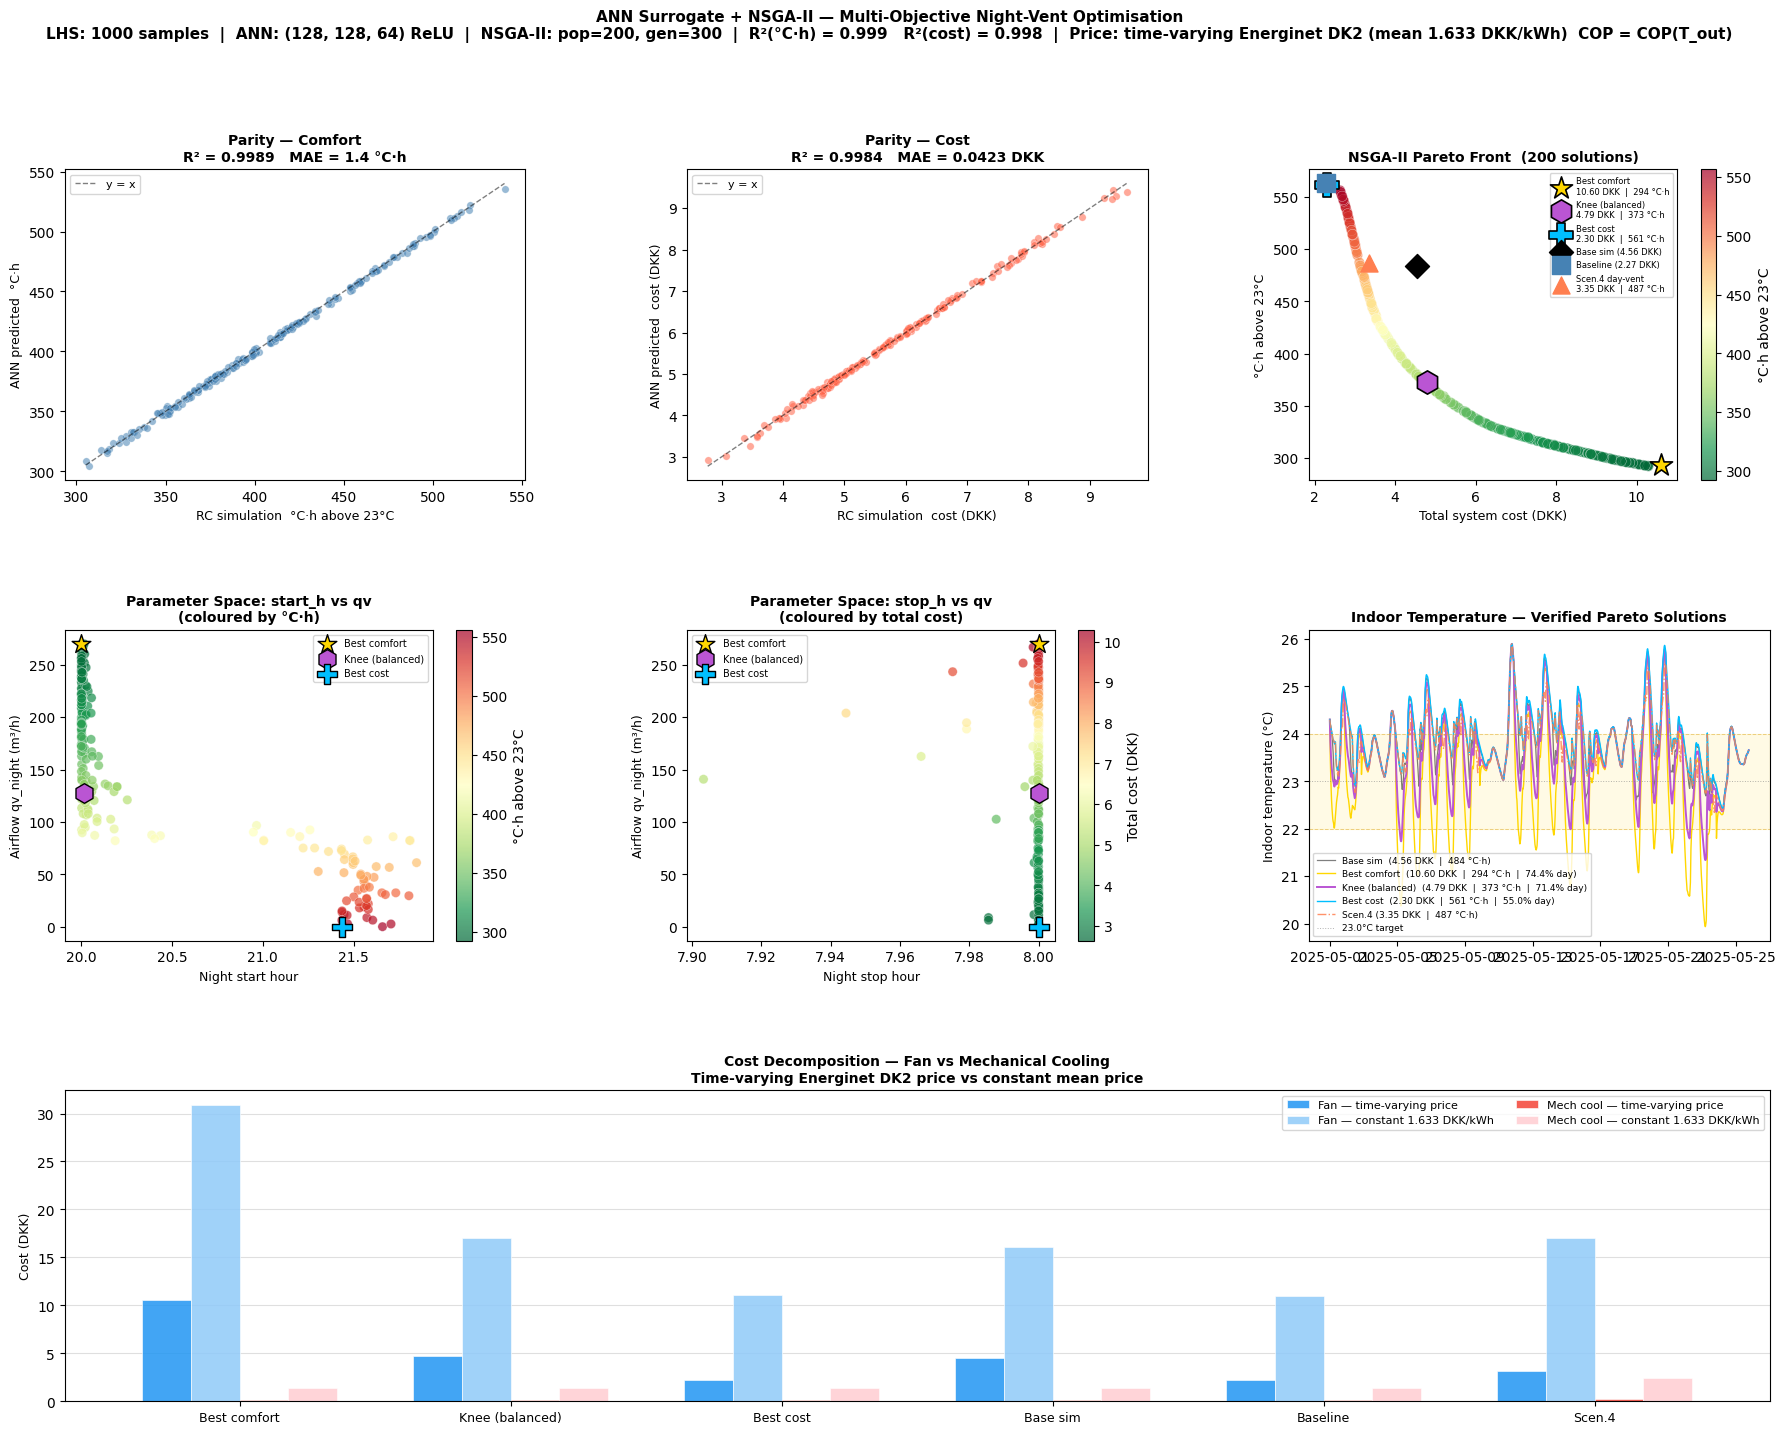


════════════════════════════════════════════════════════════════════════
  ANN + NSGA-II — RECOMMENDED SCHEDULE  (Pareto knee)
════════════════════════════════════════════════════════════════════════
  Night start    : 20.0h  →  20:00
  Night stop     : 8.0h  →  07:59
  Airflow        : 128 m³/h
  °C·h above 23°C: 372.9  (base sim: 484.3   Δ = -111.4)
  Day comfort    : 71.4%  (base sim: 66.4%)
  Total cost (var): 4.7854 DKK  (base sim: 4.5562   Δ = +0.2292)
  Total cost (const): 18.4178 DKK

────────────────────────────────────────────────────────────────────────────────
  Label                    Start   Stop     qv      °C·h    DKK(var)   DKK(const)     Day%    Night%
────────────────────────────────────────────────────────────────────────────────
  Best comfort            20.0h   8.0h   270     293.6     10.6015      32.2933    74.4%     59.6%
  Knee (balanced)         20.0h   8.0h   128     372.9      4.7854      18.4178    71.4%     83.2%
  Best cost               21.4h   8.0h  

In [20]:
# ════════════════════════════════════════════════════════════════════════════
#  ANN SURROGATE + NSGA-II  —  Night-Vent Multi-Objective Optimisation
# ════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats.qmc import LatinHypercube, scale as lhs_scale
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize as pymoo_minimize
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.termination import get_termination


# ── TUNABLE ──────────────────────────────────────────────────────────────────
N_SAMPLES    = 1000
TEST_FRAC    = 0.20
ANN_LAYERS   = (128, 128, 64)
NSGA_POP     = 200
NSGA_GEN     = 300
RANDOM_SEED  = 42

# FIX: N_VARS = 3 — build_X_monthly takes [start_h, stop_h, qv] per month
# The on_off 4th variable was never used in build_X_monthly and breaks indexing
N_VARS = 3   # start_h, stop_h, qv_night  (one set per month → 3 * N_months total)

# ── PARAMETER BOUNDS ─────────────────────────────────────────────────────────
LB = np.array([NIGHT_OPT_START_LB, NIGHT_OPT_STOP_LB, QV_MIN] * N_months)
UB = np.array([NIGHT_OPT_START_UB, NIGHT_OPT_STOP_UB, QV_MAX] * N_months)
PARAM_NAMES = ['start_h', 'stop_h', 'qv_night']

# ── CONSTANT PRICE baseline (for decomposition comparison) ────────────────────
P_ELEC_CONSTANT = 1.633   # DKK/kWh — all-in mean (Energinet DK2, May 2025)
# price_series is the hourly time-varying all-in signal (already in namespace)


# ── PHASE 1 — LHS sampling ───────────────────────────────────────────────────
print(f"\n{'═'*72}")
print(f"  PHASE 1 — Latin Hypercube Sampling  "
      f"({N_SAMPLES} points × {N_VARS * N_months} variables)")
print(f"  start_h ∈ [{LB[0]:.0f}, {UB[0]:.0f}]h  |  "
      f"stop_h ∈ [{LB[1]:.0f}, {UB[1]:.0f}]h  |  "
      f"qv ∈ [{LB[2]:.0f}, {UB[2]:.0f}] m³/h")
print(f"{'═'*72}")

sampler = LatinHypercube(d=N_VARS * N_months, seed=RANDOM_SEED)
X_lhs   = lhs_scale(sampler.random(n=N_SAMPLES), LB, UB)

Y_dh   = np.zeros(N_SAMPLES)
Y_cost = np.zeros(N_SAMPLES)
_failed = 0

for i, params in enumerate(X_lhs):
    if (i + 1) % 100 == 0:
        print(f"  Simulating sample {i+1}/{N_SAMPLES}  (failed: {_failed})")
    try:
        qv_mod, Tsup_mod = build_X_monthly(params)
        X_mod         = X_train.copy()
        X_mod['qv']   = qv_mod
        X_mod['Tsup'] = Tsup_mod
        res = simulate_night_vent_scenario(
            fitted_params, X_mod, N_hist,
            night_start_hour=0, night_stop_hour=0, qv_night=0,
            rec_duration=rec_duration,
            Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init)
        Ti = np.asarray(res['Ti'])
        if np.all(np.isfinite(Ti)):
            Y_dh[i]   = float(np.sum(np.maximum(0.0, Ti - T_TARGET)) * dt_h)
            Y_cost[i] = total_system_cost(qv_mod, Ta_arr, Tsup_mod)
        else:
            Y_dh[i]   = dh_above_ref * 2.0
            Y_cost[i] = cost_ref     * 2.0
            _failed  += 1
    except Exception as e:
        Y_dh[i]   = dh_above_ref * 2.0
        Y_cost[i] = cost_ref     * 2.0
        _failed  += 1

Y_lhs = np.column_stack([Y_dh, Y_cost])

print(f"\n  Sampling complete — {N_SAMPLES - _failed}/{N_SAMPLES} valid simulations")
print(f"  °C·h  — min: {Y_dh.min():.1f}  mean: {Y_dh.mean():.1f}  max: {Y_dh.max():.1f}")
print(f"  cost  — min: {Y_cost.min():.2f}  mean: {Y_cost.mean():.2f}  max: {Y_cost.max():.2f}")

_lhs_df = pd.DataFrame(
    np.column_stack([X_lhs, Y_lhs]),
    columns=[f'{n}_m{m}' for m in range(N_months)
             for n in PARAM_NAMES] + ['dh_above', 'cost_dkk'])
_lhs_df.to_csv('ann_lhs_training_data.csv', index=False)
print(f"  Saved: ann_lhs_training_data.csv")


# ════════════════════════════════════════════════════════════════════════════
#  PHASE 2 — Train & validate ANN surrogate
# ════════════════════════════════════════════════════════════════════════════
print(f"\n{'═'*72}")
print(f"  PHASE 2 — ANN surrogate  ({ANN_LAYERS} hidden units, ReLU, Adam)")
print(f"{'═'*72}")

X_tr, X_te, Y_tr, Y_te = train_test_split(
    X_lhs, Y_lhs, test_size=TEST_FRAC, random_state=RANDOM_SEED)

scaler_X = StandardScaler().fit(X_tr)
scaler_Y = StandardScaler().fit(Y_tr)
X_tr_s   = scaler_X.transform(X_tr)
X_te_s   = scaler_X.transform(X_te)
Y_tr_s   = scaler_Y.transform(Y_tr)

ann = MLPRegressor(
    hidden_layer_sizes=ANN_LAYERS,
    activation='relu',
    solver='adam',
    alpha=1e-4,
    max_iter=3000,
    learning_rate_init=1e-3,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=60,
    random_state=RANDOM_SEED,
    verbose=False
)
ann.fit(X_tr_s, Y_tr_s)
print(f"  Training stopped at iteration {ann.n_iter_} / {ann.max_iter}")

Y_pred_s = ann.predict(X_te_s)
Y_pred   = scaler_Y.inverse_transform(Y_pred_s)

r2_dh    = r2_score(Y_te[:, 0], Y_pred[:, 0])
r2_cost  = r2_score(Y_te[:, 1], Y_pred[:, 1])
mae_dh   = mean_absolute_error(Y_te[:, 0], Y_pred[:, 0])
mae_cost = mean_absolute_error(Y_te[:, 1], Y_pred[:, 1])

print(f"\n  Validation results  (n_test = {len(X_te)}):")
print(f"  {'Objective':<24} {'R²':>8}  {'MAE':>14}  {'Status':>10}")
print(f"  {'─'*62}")
for name, r2, mae, unit in [
    ('°C·h above 23°C', r2_dh,   mae_dh,   '°C·h'),
    ('Total cost DKK',  r2_cost,  mae_cost, 'DKK'),
]:
    status = '✓  reliable' if r2 >= 0.90 else '⚠  retrain'
    print(f"  {name:<24} {r2:>8.4f}  {mae:>10.3f} {unit:>3}  {status:>10}")

if r2_dh < 0.90 or r2_cost < 0.90:
    print(f"\n  ⚠  Increase N_SAMPLES and re-run Phase 1–2.")
else:
    print(f"\n  ✓  Both R² ≥ 0.90 — surrogate approved for NSGA-II.")


def surrogate_predict(X_raw: np.ndarray) -> np.ndarray:
    """
    Predict [dh_above_23, total_cost] for a (n × n_vars) parameter array.
    Uses time-varying price_series (same as training).
    Returns (n × 2), non-negative.
    """
    Y_s = ann.predict(scaler_X.transform(np.atleast_2d(X_raw)))
    Y   = scaler_Y.inverse_transform(Y_s)
    Y[:, 0] = np.clip(Y[:, 0], 0.0, None)
    Y[:, 1] = np.clip(Y[:, 1], 0.0, None)
    return Y


# ════════════════════════════════════════════════════════════════════════════
#  PHASE 3 — NSGA-II on surrogate
# ════════════════════════════════════════════════════════════════════════════
print(f"\n{'═'*72}")
print(f"  PHASE 3 — NSGA-II  (pop={NSGA_POP}, gen={NSGA_GEN}, surrogate-based)")
print(f"  f1 = °C·h above {T_TARGET}°C  |  f2 = total system cost (DKK)")
print(f"{'═'*72}")


class NightVentSurrogateProblem(Problem):
    def __init__(self):
        n_total = N_VARS * N_months
        super().__init__(n_var=n_total, n_obj=2, xl=LB, xu=UB, vtype=float)

    def _evaluate(self, X, out, *args, **kwargs):
        out["F"] = surrogate_predict(X)


nsga2 = NSGA2(
    pop_size=NSGA_POP,
    sampling=FloatRandomSampling(),
    crossover=SBX(prob=0.90, eta=15),
    mutation=PM(eta=20),
    eliminate_duplicates=True,
)
nsga2_res = pymoo_minimize(
    NightVentSurrogateProblem(),
    nsga2,
    termination=get_termination("n_gen", NSGA_GEN),
    seed=RANDOM_SEED,
    verbose=True,
    save_history=False,
)

X_pareto = nsga2_res.X
F_pareto = nsga2_res.F
print(f"\n  NSGA-II complete — {len(X_pareto)} Pareto-optimal solutions")

F_n = (F_pareto - F_pareto.min(0)) / (F_pareto.max(0) - F_pareto.min(0) + 1e-9)
knee_idx         = int(np.argmin(np.hypot(F_n[:, 0], F_n[:, 1])))
best_comfort_idx = int(np.argmin(F_pareto[:, 0]))
best_cost_idx    = int(np.argmin(F_pareto[:, 1]))

KEY_SOLUTIONS = {
    'Best comfort'    : (best_comfort_idx, 'gold',         '*'),
    'Knee (balanced)' : (knee_idx,         'mediumorchid', 'h'),
    'Best cost'       : (best_cost_idx,    'deepskyblue',  'P'),
}


# ════════════════════════════════════════════════════════════════════════════
#  PHASE 4 — Re-simulate key solutions + price decomposition
# ════════════════════════════════════════════════════════════════════════════
print(f"\n{'═'*72}")
print(f"  PHASE 4 — RC re-simulation of 3 key Pareto solutions")
print(f"  Price decomposition: time-varying vs constant {P_ELEC_CONSTANT} DKK/kWh")
print(f"{'═'*72}")

verified = {}
for label, (idx, color, marker) in KEY_SOLUTIONS.items():
    params           = X_pareto[idx]
    qv_mod, Tsup_mod = build_X_monthly(params)
    X_mod            = X_train.copy()
    X_mod['qv']      = qv_mod
    X_mod['Tsup']    = Tsup_mod

    res = simulate_night_vent_scenario(
        fitted_params, X_mod, N_hist,
        night_start_hour=0, night_stop_hour=0, qv_night=0,
        rec_duration=rec_duration,
        Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init)
    Ti_v = np.asarray(res['Ti'])

    dh_v, _   = dh_from_target(Ti_v)
    pct_occ_v = pct_in_band(Ti_v, T_cat1_min, T_cat1_max, occ_mask)
    pct_ngt_v = pct_in_band(Ti_v, T_cat1_min, T_cat1_max, all_night_mask)

    # Time-varying price (default, used in training and optimisation)
    bd_var    = cost_breakdown(qv_mod, Ta_arr, Tsup_mod)           # price_series
    cost_var  = bd_var['total']

    # Constant price (for comparison / sensitivity)
    bd_const  = cost_breakdown(qv_mod, Ta_arr, Tsup_mod,
                               p_elec=P_ELEC_CONSTANT)
    cost_const = bd_const['total']

    verified[label] = {
        'params'      : params,
        'Ti'          : Ti_v,
        'qv_mod'      : qv_mod,
        'dh_above'    : dh_v,
        'cost'        : cost_var,           # time-varying — primary result
        'cost_const'  : cost_const,         # constant-price counterfactual
        'bd_var'      : bd_var,
        'bd_const'    : bd_const,
        'pct_occ'     : pct_occ_v,
        'pct_night'   : pct_ngt_v,
        'surr_dh'     : F_pareto[idx, 0],
        'surr_cost'   : F_pareto[idx, 1],
        'color'       : color,
        'marker'      : marker,
    }

    print(f"\n  ── {label}  (NSGA-II idx {idx})")
    print(f"     Schedule      : "
          f"start={params[0]:.1f}h  stop={params[1]:.1f}h  "
          f"qv={params[2]:.0f} m³/h")
    print(f"     RC sim        : "
          f"{dh_v:.1f} °C·h  |  day: {pct_occ_v:.1f}%  night: {pct_ngt_v:.1f}%")
    print(f"     ── Cost breakdown (time-varying price) ──────────────")
    print(f"       Fan cost        : {bd_var['fan_cost']:.4f} DKK")
    print(f"       Mech cool cost  : {bd_var['mech_cool_cost']:.4f} DKK")
    print(f"       Free cool saves : {bd_var['free_cool_savings']:.4f} DKK")
    print(f"       Total           : {cost_var:.4f} DKK")
    print(f"     ── Cost at constant {P_ELEC_CONSTANT} DKK/kWh ─────────────────")
    print(f"       Fan cost        : {bd_const['fan_cost']:.4f} DKK")
    print(f"       Mech cool cost  : {bd_const['mech_cool_cost']:.4f} DKK")
    print(f"       Total           : {cost_const:.4f} DKK")
    print(f"       Δ (var − const) : {cost_var - cost_const:+.4f} DKK")
    print(f"     Surrogate     : "
          f"{F_pareto[idx,0]:.1f} °C·h  |  {F_pareto[idx,1]:.2f} DKK  "
          f"(Δ = {dh_v - F_pareto[idx,0]:+.1f} °C·h  "
          f"{cost_var - F_pareto[idx,1]:+.2f} DKK)")


# ════════════════════════════════════════════════════════════════════════════
#  PHASE 5 — Dashboard figure
# ════════════════════════════════════════════════════════════════════════════
fig_ann = plt.figure(figsize=(22, 16))
gs_ann  = gridspec.GridSpec(3, 3, figure=fig_ann, hspace=0.48, wspace=0.35)
fig_ann.suptitle(
    'ANN Surrogate + NSGA-II — Multi-Objective Night-Vent Optimisation\n'
    f'LHS: {N_SAMPLES} samples  |  ANN: {ANN_LAYERS} ReLU  |  '
    f'NSGA-II: pop={NSGA_POP}, gen={NSGA_GEN}  |  '
    f'R²(°C·h) = {r2_dh:.3f}   R²(cost) = {r2_cost:.3f}  |  '
    f'Price: time-varying Energinet DK2 (mean {P_ELEC_CONSTANT} DKK/kWh)  '
    f'COP = COP(T_out)',
    fontsize=11, fontweight='bold'
)

# ── P0: Parity — comfort ──────────────────────────────────────────────────────
ax0 = fig_ann.add_subplot(gs_ann[0, 0])
ax0.scatter(Y_te[:, 0], Y_pred[:, 0], alpha=0.55, s=28,
            color='steelblue', edgecolors='white', lw=0.3)
_lo, _hi = Y_te[:, 0].min(), Y_te[:, 0].max()
ax0.plot([_lo, _hi], [_lo, _hi], 'k--', lw=1.0, alpha=0.5, label='y = x')
ax0.set_xlabel('RC simulation  °C·h above 23°C', fontsize=9)
ax0.set_ylabel('ANN predicted  °C·h', fontsize=9)
ax0.set_title(f'Parity — Comfort\nR² = {r2_dh:.4f}   MAE = {mae_dh:.1f} °C·h',
              fontsize=10, fontweight='bold')
ax0.legend(fontsize=8)

# ── P1: Parity — cost ────────────────────────────────────────────────────────
ax1 = fig_ann.add_subplot(gs_ann[0, 1])
ax1.scatter(Y_te[:, 1], Y_pred[:, 1], alpha=0.55, s=28,
            color='tomato', edgecolors='white', lw=0.3)
_lo, _hi = Y_te[:, 1].min(), Y_te[:, 1].max()
ax1.plot([_lo, _hi], [_lo, _hi], 'k--', lw=1.0, alpha=0.5, label='y = x')
ax1.set_xlabel('RC simulation  cost (DKK)', fontsize=9)
ax1.set_ylabel('ANN predicted  cost (DKK)', fontsize=9)
ax1.set_title(f'Parity — Cost\nR² = {r2_cost:.4f}   MAE = {mae_cost:.4f} DKK',
              fontsize=10, fontweight='bold')
ax1.legend(fontsize=8)

# ── P2: Pareto front (NSGA-II) ───────────────────────────────────────────────
ax2 = fig_ann.add_subplot(gs_ann[0, 2])
_sort = np.argsort(F_pareto[:, 1])
sc2   = ax2.scatter(F_pareto[:, 1], F_pareto[:, 0],
                    c=F_pareto[:, 0], cmap='RdYlGn_r', s=55,
                    alpha=0.70, edgecolors='white', lw=0.3, zorder=3)
ax2.plot(F_pareto[_sort, 1], F_pareto[_sort, 0],
         color='black', lw=1.0, alpha=0.35, zorder=2)
plt.colorbar(sc2, ax=ax2, label='°C·h above 23°C')
for label, data in verified.items():
    ax2.scatter(data['cost'], data['dh_above'],
                s=280, marker=data['marker'], color=data['color'],
                edgecolors='black', lw=1.2, zorder=6,
                label=f"{label}\n{data['cost']:.2f} DKK  |  {data['dh_above']:.0f} °C·h")
ax2.scatter(cost_ref,      dh_above_ref,  s=150, marker='D',
            color='black',     zorder=7, label=f'Base sim ({cost_ref:.2f} DKK)')
ax2.scatter(cost_baseline, dh_above_base, s=150, marker='s',
            color='steelblue', zorder=7, label=f'Baseline ({cost_baseline:.2f} DKK)')
ax2.scatter(cost_s4, dh_s4, s=150, marker='^', color='coral', zorder=7,
            label=f'Scen.4 day-vent\n{cost_s4:.2f} DKK  |  {dh_s4:.0f} °C·h')
ax2.set_xlabel('Total system cost (DKK)', fontsize=9)
ax2.set_ylabel('°C·h above 23°C', fontsize=9)
ax2.set_title(f'NSGA-II Pareto Front  ({len(X_pareto)} solutions)',
              fontsize=10, fontweight='bold')
ax2.legend(fontsize=6.0, loc='upper right')

# ── P3: Parameter space — start_h vs qv ──────────────────────────────────────
ax3 = fig_ann.add_subplot(gs_ann[1, 0])
sc3 = ax3.scatter(X_pareto[:, 0], X_pareto[:, 2],
                  c=F_pareto[:, 0], cmap='RdYlGn_r', s=45,
                  alpha=0.70, edgecolors='white', lw=0.3)
plt.colorbar(sc3, ax=ax3, label='°C·h above 23°C')
for label, data in verified.items():
    ax3.scatter(data['params'][0], data['params'][2],
                s=200, marker=data['marker'], color=data['color'],
                edgecolors='black', lw=1.0, zorder=5, label=label)
ax3.set_xlabel('Night start hour', fontsize=9)
ax3.set_ylabel('Airflow qv_night (m³/h)', fontsize=9)
ax3.set_title('Parameter Space: start_h vs qv\n(coloured by °C·h)',
              fontsize=10, fontweight='bold')
ax3.legend(fontsize=7)

# ── P4: Parameter space — stop_h vs qv ───────────────────────────────────────
ax4 = fig_ann.add_subplot(gs_ann[1, 1])
sc4 = ax4.scatter(X_pareto[:, 1], X_pareto[:, 2],
                  c=F_pareto[:, 1], cmap='RdYlGn_r', s=45,
                  alpha=0.70, edgecolors='white', lw=0.3)
plt.colorbar(sc4, ax=ax4, label='Total cost (DKK)')
for label, data in verified.items():
    ax4.scatter(data['params'][1], data['params'][2],
                s=200, marker=data['marker'], color=data['color'],
                edgecolors='black', lw=1.0, zorder=5, label=label)
ax4.set_xlabel('Night stop hour', fontsize=9)
ax4.set_ylabel('Airflow qv_night (m³/h)', fontsize=9)
ax4.set_title('Parameter Space: stop_h vs qv\n(coloured by total cost)',
              fontsize=10, fontweight='bold')
ax4.legend(fontsize=7)

# ── P5: Ti time-series ────────────────────────────────────────────────────────
ax5 = fig_ann.add_subplot(gs_ann[1, 2])
ax5.plot(index, Ti_ref, color='black', lw=0.9, alpha=0.50,
         label=f'Base sim  ({cost_ref:.2f} DKK  |  {dh_above_ref:.0f} °C·h)')
for label, data in verified.items():
    lw = 1.4 if label == 'Knee (balanced)' else 1.0
    ax5.plot(index, data['Ti'], color=data['color'], lw=lw,
             label=f"{label}  ({data['cost']:.2f} DKK  |  "
                   f"{data['dh_above']:.0f} °C·h  |  {data['pct_occ']:.1f}% day)")
ax5.plot(index, Ti_s4, color='coral', lw=1.0, ls='-.', alpha=0.85,
         label=f"Scen.4 ({cost_s4:.2f} DKK  |  {dh_s4:.0f} °C·h)")
ax5.axhspan(T_cat1_min, T_cat1_max, alpha=0.10, color='gold')
ax5.axhline(T_cat1_max, color='goldenrod', lw=0.7, ls='--', alpha=0.5)
ax5.axhline(T_cat1_min, color='goldenrod', lw=0.7, ls='--', alpha=0.5)
ax5.axhline(T_TARGET,   color='grey',      lw=0.7, ls=':',  alpha=0.6,
            label=f'{T_TARGET}°C target')
ax5.set_ylabel('Indoor temperature (°C)', fontsize=9)
ax5.set_title('Indoor Temperature — Verified Pareto Solutions',
              fontsize=10, fontweight='bold')
ax5.legend(fontsize=6.5)

# ── P6: Cost decomposition bar chart ─────────────────────────────────────────
ax6 = fig_ann.add_subplot(gs_ann[2, :])

_labels_bar  = (list(verified.keys())
                + ['Base sim', 'Baseline', 'Scen.4'])
_fan_var     = ([d['bd_var']['fan_cost']  for d in verified.values()]
                + [cost_breakdown(qv_arr,      Ta_arr, Tsup_ref)['fan_cost'],
                   cost_breakdown(qv_baseline, Ta_arr, Tsup_base)['fan_cost'],
                   bd_s4['fan_cost']])
_cool_var    = ([d['bd_var']['mech_cool_cost']  for d in verified.values()]
                + [cost_breakdown(qv_arr,      Ta_arr, Tsup_ref)['mech_cool_cost'],
                   cost_breakdown(qv_baseline, Ta_arr, Tsup_base)['mech_cool_cost'],
                   bd_s4['mech_cool_cost']])
_fan_const   = ([d['bd_const']['fan_cost']  for d in verified.values()]
                + [cost_breakdown(qv_arr,      Ta_arr, Tsup_ref,   p_elec=P_ELEC_CONSTANT)['fan_cost'],
                   cost_breakdown(qv_baseline, Ta_arr, Tsup_base,  p_elec=P_ELEC_CONSTANT)['fan_cost'],
                   cost_breakdown(qv_s4,       Ta_arr, tsup_s4,    p_elec=P_ELEC_CONSTANT)['fan_cost']])
_cool_const  = ([d['bd_const']['mech_cool_cost']  for d in verified.values()]
                + [cost_breakdown(qv_arr,      Ta_arr, Tsup_ref,   p_elec=P_ELEC_CONSTANT)['mech_cool_cost'],
                   cost_breakdown(qv_baseline, Ta_arr, Tsup_base,  p_elec=P_ELEC_CONSTANT)['mech_cool_cost'],
                   cost_breakdown(qv_s4,       Ta_arr, tsup_s4,    p_elec=P_ELEC_CONSTANT)['mech_cool_cost']])

x      = np.arange(len(_labels_bar))
width  = 0.18
colors_fan  = ['#2196F3', '#90CAF9']   # dark blue = var, light blue = const
colors_cool = ['#F44336', '#FFCDD2']   # dark red  = var, light red  = const

b1 = ax6.bar(x - 1.5*width, _fan_var,   width, label='Fan — time-varying price',
             color=colors_fan[0],  alpha=0.85, edgecolor='white', lw=0.5)
b2 = ax6.bar(x - 0.5*width, _fan_const, width, label=f'Fan — constant {P_ELEC_CONSTANT} DKK/kWh',
             color=colors_fan[1],  alpha=0.85, edgecolor='white', lw=0.5)
b3 = ax6.bar(x + 0.5*width, _cool_var,  width, label='Mech cool — time-varying price',
             color=colors_cool[0], alpha=0.85, edgecolor='white', lw=0.5)
b4 = ax6.bar(x + 1.5*width, _cool_const,width, label=f'Mech cool — constant {P_ELEC_CONSTANT} DKK/kWh',
             color=colors_cool[1], alpha=0.85, edgecolor='white', lw=0.5)

ax6.set_xticks(x)
ax6.set_xticklabels(_labels_bar, fontsize=9)
ax6.set_ylabel('Cost (DKK)', fontsize=9)
ax6.set_title(
    'Cost Decomposition — Fan vs Mechanical Cooling\n'
    'Time-varying Energinet DK2 price vs constant mean price',
    fontsize=10, fontweight='bold')
ax6.legend(fontsize=8, ncol=2)
ax6.yaxis.grid(True, alpha=0.4)
ax6.set_axisbelow(True)

plt.savefig('ann_nsga2_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════════════════════
#  FINAL RECOMMENDATION PRINTOUT
# ════════════════════════════════════════════════════════════════════════════
knee = verified['Knee (balanced)']
print(f"\n{'═'*72}")
print(f"  ANN + NSGA-II — RECOMMENDED SCHEDULE  (Pareto knee)")
print(f"{'═'*72}")
print(f"  Night start    : {knee['params'][0]:.1f}h  "
      f"→  {int(knee['params'][0]):02d}:{int((knee['params'][0] % 1)*60):02d}")
print(f"  Night stop     : {knee['params'][1]:.1f}h  "
      f"→  {int(knee['params'][1]):02d}:{int((knee['params'][1] % 1)*60):02d}")
print(f"  Airflow        : {knee['params'][2]:.0f} m³/h")
print(f"  °C·h above 23°C: {knee['dh_above']:.1f}  "
      f"(base sim: {dh_above_ref:.1f}   Δ = {knee['dh_above'] - dh_above_ref:+.1f})")
print(f"  Day comfort    : {knee['pct_occ']:.1f}%  (base sim: {pct_occ_ref:.1f}%)")
print(f"  Total cost (var): {knee['cost']:.4f} DKK  "
      f"(base sim: {cost_ref:.4f}   Δ = {knee['cost'] - cost_ref:+.4f})")
print(f"  Total cost (const): {knee['cost_const']:.4f} DKK")

print(f"\n{'─'*80}")
print(f"  {'Label':<22} {'Start':>7} {'Stop':>6} {'qv':>6}  "
      f"{'°C·h':>8}  {'DKK(var)':>10}  {'DKK(const)':>11}  "
      f"{'Day%':>7}  {'Night%':>8}")
print(f"{'─'*80}")
for label, data in verified.items():
    p = data['params']
    print(f"  {label:<22} {p[0]:>5.1f}h {p[1]:>5.1f}h {p[2]:>5.0f}  "
          f"{data['dh_above']:>8.1f}  {data['cost']:>10.4f}  "
          f"{data['cost_const']:>11.4f}  "
          f"{data['pct_occ']:>6.1f}%  {data['pct_night']:>7.1f}%")
print(f"{'─'*80}")

_bd_ref   = cost_breakdown(qv_arr,      Ta_arr, Tsup_ref)
_bd_ref_c = cost_breakdown(qv_arr,      Ta_arr, Tsup_ref,  p_elec=P_ELEC_CONSTANT)
_bd_bas   = cost_breakdown(qv_baseline, Ta_arr, Tsup_base)
_bd_bas_c = cost_breakdown(qv_baseline, Ta_arr, Tsup_base, p_elec=P_ELEC_CONSTANT)

print(f"  {'Base simulation':<22}  {'—':>6}  {'—':>6}  {'—':>6}  "
      f"{dh_above_ref:>8.1f}  {cost_ref:>10.4f}  {_bd_ref_c['total']:>11.4f}  "
      f"{pct_occ_ref:>6.1f}%  {pct_night_ref:>7.1f}%")
print(f"  {'Baseline (no-vent)':<22}  {'—':>6}  {'—':>6}  {'—':>6}  "
      f"{dh_above_base:>8.1f}  {cost_baseline:>10.4f}  {_bd_bas_c['total']:>11.4f}  "
      f"{pct_occ_base:>6.1f}%  {'—':>7}")
print(f"  {'Scen.4 (day-vent)':<22}  {'—':>6}  {'—':>6}  "
      f"{qv_s4[occ_mask].mean():>5.0f}  "
      f"{dh_s4:>8.1f}  {cost_s4:>10.4f}  "
      f"{cost_breakdown(qv_s4, Ta_arr, tsup_s4, p_elec=P_ELEC_CONSTANT)['total']:>11.4f}  "
      f"{pct_occ_s4:>6.1f}%  {'—':>7}")
print(f"{'═'*80}")

print(f"\n  Surrogate accuracy on re-simulated solutions:")
print(f"  {'Label':<22}  {'Δ°C·h':>10}  {'ΔDKK':>8}")
print(f"  {'─'*44}")
for label, data in verified.items():
    print(f"  {label:<22}  "
          f"{data['dh_above'] - data['surr_dh']:>+10.2f}  "
          f"{data['cost'] - data['surr_cost']:>+8.4f}")


═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  Scenario                 Start   Stop    qv     °C·h    Day%   Night%   Fan(var)  Cool(var)  FreeSav(var)  Tot(var)   Fan(cst)  Cool(cst)  FreeSav(cst)  Tot(cst)
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  Best comfort             20.0h   8.0h   270    293.6   74.4%    59.6%     10.516      0.085        30.620    10.602     30.889      1.404        86.105    32.293
  Knee (balanced)          20.0h   8.0h   128    372.9   71.4%    83.2%      4.700      0.085        17.072     4.785     17.014      1.404        52.977    18.418
  Best cost                21.4h   8.0h     0    561.2   55.0%    66.5%      2.216      0.085         5.014     2.301     11.072      1.404        23.427    12.475
  Base simulation              —      —     —    484.3   66.4%    73.7%

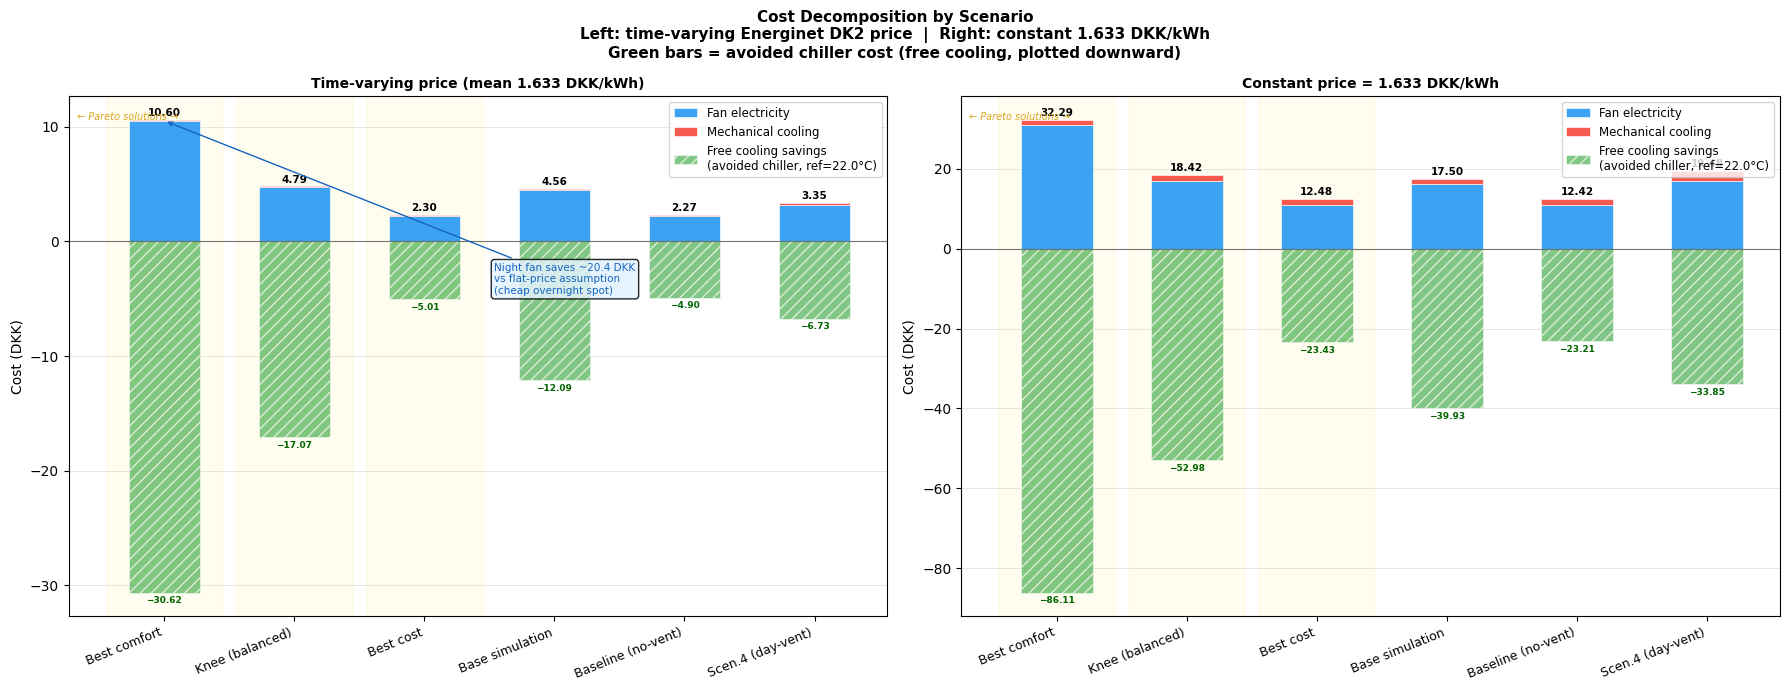

  Saved: cost_decomposition_extended.png


In [21]:
# ════════════════════════════════════════════════════════════════════════════
#  POST-PROCESSING — Extended Summary Table + Cost Decomposition Bar Chart
# ════════════════════════════════════════════════════════════════════════════

# ── Recompute all cost breakdowns ────────────────────────────────────────────
_bd_ref    = cost_breakdown(qv_arr,      Ta_arr, Tsup_ref)
_bd_ref_c  = cost_breakdown(qv_arr,      Ta_arr, Tsup_ref,   p_elec=P_ELEC_CONSTANT)
_bd_bas    = cost_breakdown(qv_baseline, Ta_arr, Tsup_base)
_bd_bas_c  = cost_breakdown(qv_baseline, Ta_arr, Tsup_base,  p_elec=P_ELEC_CONSTANT)
_bd_s4     = bd_s4
_bd_s4_c   = cost_breakdown(qv_s4,       Ta_arr, tsup_s4,    p_elec=P_ELEC_CONSTANT)


# ── Build unified scenario list ───────────────────────────────────────────────
scenarios = []

# Pareto solutions — use qv_mod from verified dict
for label, data in verified.items():
    p = data['params']
    scenarios.append({
        'label'      : label,
        'start'      : f"{p[0]:.1f}h",
        'stop'       : f"{p[1]:.1f}h",
        'qv'         : f"{p[2]:.0f}",
        'dh_above'   : data['dh_above'],
        'pct_occ'    : data['pct_occ'],
        'pct_night'  : data['pct_night'],
        # time-varying
        'fan_var'    : data['bd_var']['fan_cost'],
        'cool_var'   : data['bd_var']['mech_cool_cost'],
        'free_var'   : free_cooling_savings_nv(data['qv_mod'], Ta_arr),
        'total_var'  : data['bd_var']['total'],
        # constant
        'fan_const'  : data['bd_const']['fan_cost'],
        'cool_const' : data['bd_const']['mech_cool_cost'],
        'free_const' : free_cooling_savings_nv(data['qv_mod'], Ta_arr,
                                               p_elec=P_ELEC_CONSTANT),
        'total_const': data['bd_const']['total'],
    })

# Reference scenarios — expanded loop to pass correct qv array per scenario
for label, bd_v, bd_c, dh, pct_occ, pct_ngt, qv_s, qv_arr_s in [
    ('Base simulation',
     _bd_ref,  _bd_ref_c,  dh_above_ref,  pct_occ_ref,  pct_night_ref,
     '—', qv_arr),
    ('Baseline (no-vent)',
     _bd_bas,  _bd_bas_c,  dh_above_base, pct_occ_base, None,
     '—', qv_baseline),
    ('Scen.4 (day-vent)',
     _bd_s4,   _bd_s4_c,   dh_s4,         pct_occ_s4,   None,
     f"{qv_s4[occ_mask].mean():.0f}", qv_s4),
]:
    scenarios.append({
        'label'      : label,
        'start'      : '—', 'stop': '—', 'qv': qv_s,
        'dh_above'   : dh,
        'pct_occ'    : pct_occ,
        'pct_night'  : pct_ngt,
        'fan_var'    : bd_v['fan_cost'],
        'cool_var'   : bd_v['mech_cool_cost'],
        'free_var'   : free_cooling_savings_nv(qv_arr_s, Ta_arr),
        'total_var'  : bd_v['total'],
        'fan_const'  : bd_c['fan_cost'],
        'cool_const' : bd_c['mech_cool_cost'],
        'free_const' : free_cooling_savings_nv(qv_arr_s, Ta_arr,
                                               p_elec=P_ELEC_CONSTANT),
        'total_const': bd_c['total'],
    })


# ════════════════════════════════════════════════════════════════════════════
#  EXTENDED SUMMARY TABLE
# ════════════════════════════════════════════════════════════════════════════
hdr = (f"\n{'═'*135}\n"
       f"  {'Scenario':<22} {'Start':>7} {'Stop':>6} {'qv':>5}  "
       f"{'°C·h':>7}  {'Day%':>6}  {'Night%':>7}  "
       f"{'Fan(var)':>9} {'Cool(var)':>10} {'FreeSav(var)':>13} {'Tot(var)':>9}  "
       f"{'Fan(cst)':>9} {'Cool(cst)':>10} {'FreeSav(cst)':>13} {'Tot(cst)':>9}\n"
       f"{'─'*135}")
print(hdr)

for s in scenarios:
    pct_ngt_str = f"{s['pct_night']:.1f}%" if s['pct_night'] is not None else '     —'
    print(
        f"  {s['label']:<22} {s['start']:>7} {s['stop']:>6} {s['qv']:>5}  "
        f"{s['dh_above']:>7.1f}  {s['pct_occ']:>5.1f}%  {pct_ngt_str:>7}  "
        f"{s['fan_var']:>9.3f} {s['cool_var']:>10.3f} {s['free_var']:>13.3f} "
        f"{s['total_var']:>9.3f}  "
        f"{s['fan_const']:>9.3f} {s['cool_const']:>10.3f} {s['free_const']:>13.3f} "
        f"{s['total_const']:>9.3f}"
    )

print(f"{'═'*135}")
print(f"  (var) = time-varying Energinet DK2 price  |  "
      f"(cst) = constant {P_ELEC_CONSTANT} DKK/kWh  |  "
      f"FreeSav = avoided chiller cost (outdoor air cooler than {T_cat1_min}°C setpoint)  |  "
      f"qv in m³/h")


# ════════════════════════════════════════════════════════════════════════════
#  COST DECOMPOSITION BAR CHART
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=False)
fig.suptitle(
    'Cost Decomposition by Scenario\n'
    f'Left: time-varying Energinet DK2 price  |  '
    f'Right: constant {P_ELEC_CONSTANT} DKK/kWh\n'
    f'Green bars = avoided chiller cost (free cooling, plotted downward)',
    fontsize=11, fontweight='bold'
)

labels = [s['label'] for s in scenarios]
fan_v  = [s['fan_var']    for s in scenarios]
cool_v = [s['cool_var']   for s in scenarios]
free_v = [s['free_var']   for s in scenarios]
fan_c  = [s['fan_const']  for s in scenarios]
cool_c = [s['cool_const'] for s in scenarios]
free_c = [s['free_const'] for s in scenarios]

x     = np.arange(len(labels))
width = 0.55

C_FAN  = '#2196F3'
C_COOL = '#F44336'
C_FREE = '#4CAF50'

for ax, fan, cool, free, price_label in [
    (axes[0], fan_v, cool_v, free_v,
     f'Time-varying price (mean {P_ELEC_CONSTANT} DKK/kWh)'),
    (axes[1], fan_c, cool_c, free_c,
     f'Constant price = {P_ELEC_CONSTANT} DKK/kWh'),
]:
    fan  = np.array(fan)
    cool = np.array(cool)
    free = np.array(free)

    ax.bar(x, fan,  width, label='Fan electricity',
           color=C_FAN,  alpha=0.88, edgecolor='white', lw=0.5)
    ax.bar(x, cool, width, bottom=fan,
           label='Mechanical cooling', color=C_COOL,
           alpha=0.88, edgecolor='white', lw=0.5)

    has_free = np.any(free > 0.01)
    if has_free:
        ax.bar(x, -free, width,
               label=f'Free cooling savings\n(avoided chiller, ref={T_cat1_min}°C)',
               color=C_FREE, alpha=0.70, edgecolor='white', lw=0.5, hatch='///')

    totals = fan + cool
    y_top  = totals.max()
    y_bot  = -free.max() if has_free else 0.0

    for i, (tot, fr_val) in enumerate(zip(totals, free)):
        # Total cost label above bar
        ax.text(x[i], tot + 0.015 * y_top,
                f'{tot:.2f}', ha='center', va='bottom',
                fontsize=7.5, fontweight='bold')
        # Free savings label below zero
        if has_free and fr_val > 0.01:
            ax.text(x[i], -fr_val - 0.03 * y_top,
                    f'−{fr_val:.2f}', ha='center', va='top',
                    fontsize=6.5, color='darkgreen', fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=22, ha='right', fontsize=9)
    ax.set_ylabel('Cost (DKK)', fontsize=10)
    ax.set_title(price_label, fontsize=10, fontweight='bold')
    ax.yaxis.grid(True, alpha=0.35, lw=0.6)
    ax.set_axisbelow(True)
    ax.axhline(0, color='black', lw=0.8, alpha=0.5)

    # Gold shading on Pareto solutions
    for i in range(len(verified)):
        ax.axvspan(i - 0.45, i + 0.45, alpha=0.06, color='gold', zorder=0)

    ax.legend(fontsize=8.5, loc='upper right')
    ax.annotate('← Pareto solutions →',
                xytext=(0.01, 0.97), textcoords='axes fraction',
                xy=(0, 0), fontsize=7, color='goldenrod',
                fontstyle='italic', va='top', annotation_clip=False)

# Annotation highlighting the time-of-use saving on best comfort fan
delta_best = np.array(fan_c)[0] - np.array(fan_v)[0]
axes[0].annotate(
    f'Night fan saves ~{delta_best:.1f} DKK\nvs flat-price assumption\n(cheap overnight spot)',
    xy=(0, np.array(fan_v)[0]), xycoords='data',
    xytext=(0.52, 0.62), textcoords='axes fraction',
    fontsize=7.5, color='#1565C0',
    arrowprops=dict(arrowstyle='->', color='#1565C0', lw=1.0),
    bbox=dict(boxstyle='round,pad=0.3', fc='#E3F2FD', alpha=0.85)
)

plt.tight_layout()
plt.savefig('cost_decomposition_extended.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Saved: cost_decomposition_extended.png")

Re-simulating all Pareto scenarios from scratch...
  Best comfort                : RC=10.602 DKK | ANN=10.294 DKK | 293.6 °C·h  [idx=0]
  Knee (balanced)             : RC=4.785 DKK | ANN=4.793 DKK | 372.9 °C·h  [idx=122]
  Best cost                   : RC=2.301 DKK | ANN=2.632 DKK | 561.2 °C·h  [idx=1]
  Same cost as base sim       : RC=4.603 DKK | ANN=4.568 DKK | 379.7 °C·h  [idx=104]
  Same comfort as base sim    : RC=3.280 DKK | ANN=3.132 DKK | 486.6 °C·h  [idx=84]

══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  ANN + NSGA-II — PARETO COMPARISON TABLE  (all costs recomputed)
══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  Scenario                         Start   Stop    qv     °C·h    Δ°C·h   Fan(v)  Cool(v)  Free(v)  Tot(v)   Fan(c)  Cool(c)  Free(c)  Tot(c)    Day%   Night%

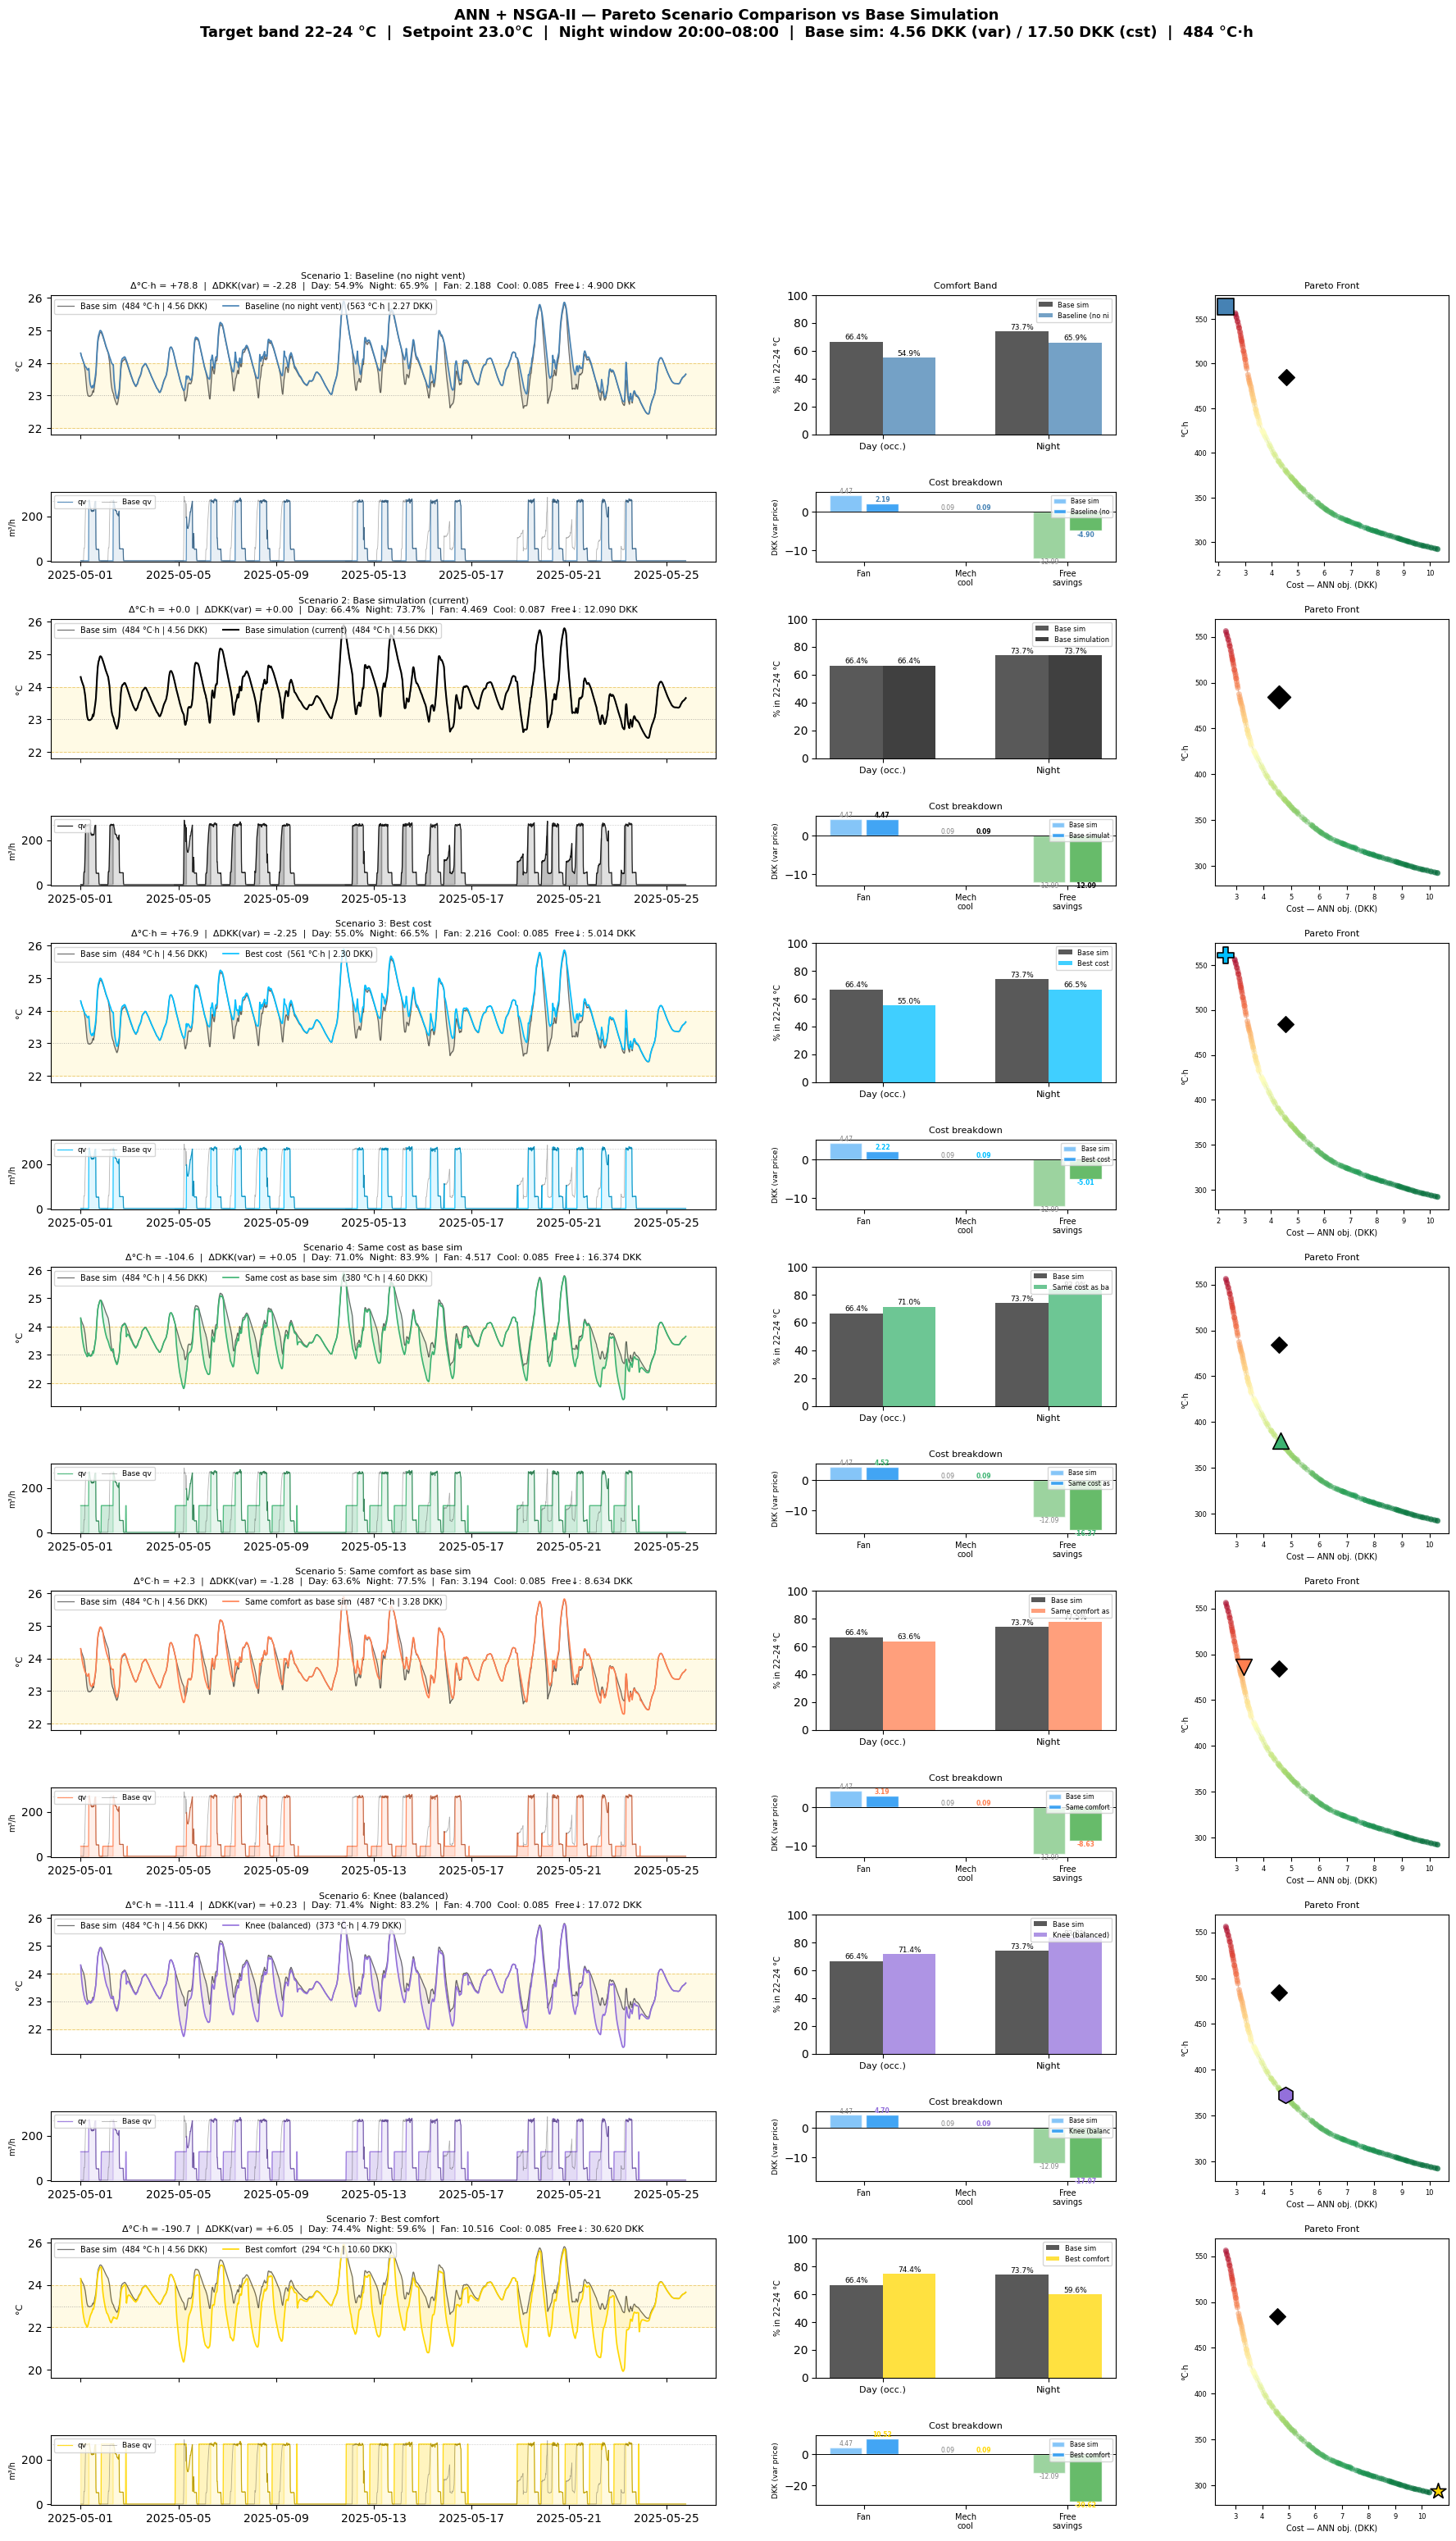

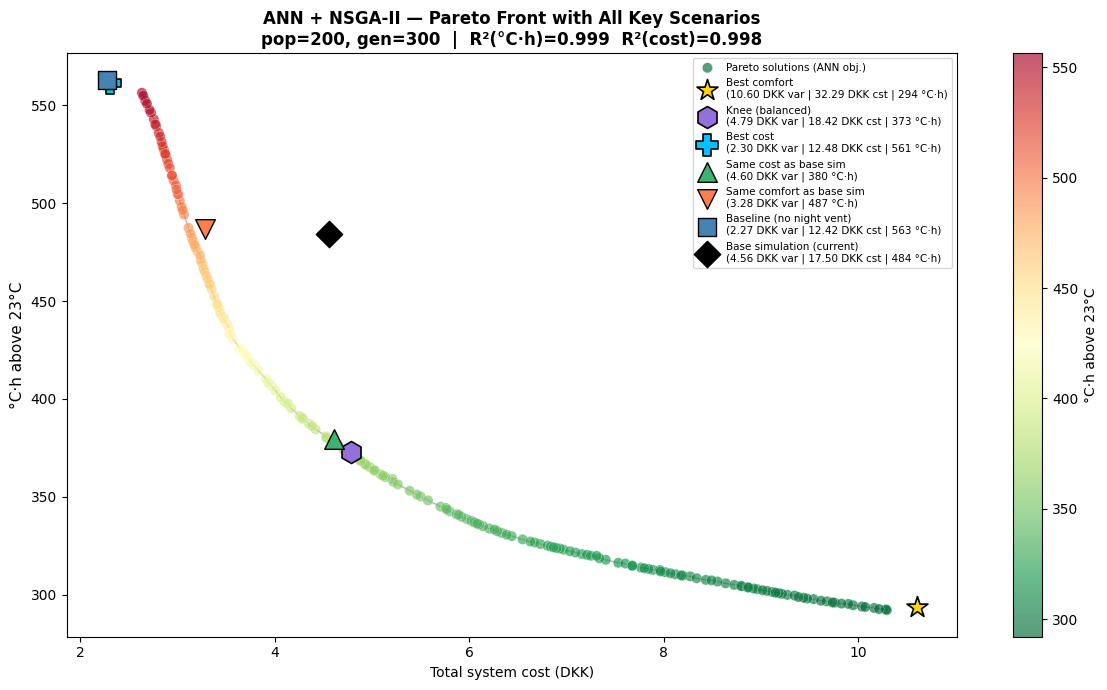


════════════════════════════════════════════════════════════════════════════════
  ANN + NSGA-II — RECOMMENDED SCHEDULE  (Pareto knee)
════════════════════════════════════════════════════════════════════════════════
  Night start     : 20.0h  →  20:00
  Night stop      : 8.0h  →  07:59
  Airflow         : 128 m³/h
  °C·h above 23°C : 372.9  (base sim: 484.3   Δ = -111.4)
  Day comfort     : 71.4%  (base sim: 66.4%)
  Total cost (var): 4.7854 DKK  (base sim: 4.5562   Δ = +0.2292)
  Total cost (cst): 18.4178 DKK
  Free cool saves : 17.0718 DKK (var) | 52.9767 DKK (cst)

────────────────────────────────────────────────────────────────────────────────────────────────────
  Label                            Start   Stop    qv     °C·h    Δ°C·h   DKK(var)   DKK(cst)   FreeSav    Day%   Night%
────────────────────────────────────────────────────────────────────────────────────────────────────
  Baseline (no night vent)             —      —     —    563.1    +78.8     2.2733    12.4247    4.89

In [22]:
# ════════════════════════════════════════════════════════════════════════════
#  ANN+NSGA-II PARETO COMPARISON — Summary Table + Figure
#
#  Prerequisites (from ANN+NSGA-II block):
#    verified, F_pareto, X_pareto, Y_lhs, X_lhs, surrogate_predict
#    dh_above_ref, cost_ref, pct_occ_ref, pct_night_ref, Ti_ref
#    dh_above_base, cost_baseline, pct_occ_base, Ti_baseline
#    dh_s4, cost_s4, pct_occ_s4, Ti_s4, qv_s4, tsup_s4, bd_s4
#    index, occ_mask, all_night_mask, weekday_night_mask, weekday_day_mask
#    T_TARGET, T_cat1_min, T_cat1_max, QV_MAX, dt_h, P_ELEC_CONSTANT
#    NIGHT_START, NIGHT_STOP
# ════════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


# ════════════════════════════════════════════════════════════════════════════
#  CORE HELPERS
# ════════════════════════════════════════════════════════════════════════════
def _full_resim(params, label, color, marker, pareto_idx=None):
    qv_mod, Tsup_mod = build_X_monthly(params)
    X_mod            = X_train.copy()
    X_mod['qv']      = qv_mod
    X_mod['Tsup']    = Tsup_mod

    res = simulate_night_vent_scenario(
        fitted_params, X_mod, N_hist,
        night_start_hour=0, night_stop_hour=0, qv_night=0,
        rec_duration=rec_duration,
        Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init)

    Ti_v      = np.asarray(res['Ti'])
    dh_v, _   = dh_from_target(Ti_v)
    pct_occ_v = pct_in_band(Ti_v, T_cat1_min, T_cat1_max, occ_mask)
    pct_ngt_v = pct_in_band(Ti_v, T_cat1_min, T_cat1_max, all_night_mask)

    bd_v = cost_breakdown(qv_mod, Ta_arr, Tsup_mod)
    bd_c = cost_breakdown(qv_mod, Ta_arr, Tsup_mod, p_elec=P_ELEC_CONSTANT)

    return {
        'label'      : label,
        'params'     : params,
        'pareto_idx' : pareto_idx,
        'Ti'         : Ti_v,
        'qv_mod'     : qv_mod,
        'dh_above'   : dh_v,
        'pct_occ'    : pct_occ_v,
        'pct_night'  : pct_ngt_v,
        'fan_var'    : bd_v['fan_cost'],
        'cool_var'   : bd_v['mech_cool_cost'],
        'free_var'   : free_cooling_savings_nv(qv_mod, Ta_arr),
        'total_var'  : bd_v['total'],
        'fan_const'  : bd_c['fan_cost'],
        'cool_const' : bd_c['mech_cool_cost'],
        'free_const' : free_cooling_savings_nv(qv_mod, Ta_arr, p_elec=P_ELEC_CONSTANT),
        'total_const': bd_c['total'],
        'color'      : color,
        'marker'     : marker,
    }


def _ref_metrics(label, Ti_v, qv_v, Tsup_v, dh_v, pct_occ_v, pct_ngt_v,
                 color, marker):
    bd_v = cost_breakdown(qv_v, Ta_arr, Tsup_v)
    bd_c = cost_breakdown(qv_v, Ta_arr, Tsup_v, p_elec=P_ELEC_CONSTANT)
    return {
        'label'      : label,
        'params'     : None,
        'pareto_idx' : None,
        'Ti'         : Ti_v,
        'qv_mod'     : qv_v,
        'dh_above'   : dh_v,
        'pct_occ'    : pct_occ_v,
        'pct_night'  : pct_ngt_v,
        'fan_var'    : bd_v['fan_cost'],
        'cool_var'   : bd_v['mech_cool_cost'],
        'free_var'   : free_cooling_savings_nv(qv_v, Ta_arr),
        'total_var'  : bd_v['total'],
        'fan_const'  : bd_c['fan_cost'],
        'cool_const' : bd_c['mech_cool_cost'],
        'free_const' : free_cooling_savings_nv(qv_v, Ta_arr, p_elec=P_ELEC_CONSTANT),
        'total_const': bd_c['total'],
        'color'      : color,
        'marker'     : marker,
    }


# ════════════════════════════════════════════════════════════════════════════
#  BUILD SCENARIO LIST
# ════════════════════════════════════════════════════════════════════════════
print("Re-simulating all Pareto scenarios from scratch...")

_sc_best_comfort = _full_resim(
    verified['Best comfort']['params'],    'Best comfort',    'gold',           '*',
    pareto_idx=verified['Best comfort'].get('pareto_idx', best_comfort_idx))

_sc_knee = _full_resim(
    verified['Knee (balanced)']['params'], 'Knee (balanced)', 'mediumpurple',   'h',
    pareto_idx=verified['Knee (balanced)'].get('pareto_idx', knee_idx))

_sc_best_cost = _full_resim(
    verified['Best cost']['params'],       'Best cost',       'deepskyblue',    'P',
    pareto_idx=verified['Best cost'].get('pareto_idx', best_cost_idx))

iso_cost_idx    = int(np.argmin(np.abs(F_pareto[:, 1] - cost_ref)))
iso_comfort_idx = int(np.argmin(np.abs(F_pareto[:, 0] - dh_above_ref)))

_sc_iso_cost = _full_resim(
    X_pareto[iso_cost_idx],    'Same cost as base sim',    'mediumseagreen', '^',
    pareto_idx=iso_cost_idx)

_sc_iso_comfort = _full_resim(
    X_pareto[iso_comfort_idx], 'Same comfort as base sim', 'coral',          'v',
    pareto_idx=iso_comfort_idx)

for s in [_sc_best_comfort, _sc_knee, _sc_best_cost, _sc_iso_cost, _sc_iso_comfort]:
    print(f"  {s['label']:<28}: RC={s['total_var']:.3f} DKK | "
          f"ANN={F_pareto[s['pareto_idx'], 1]:.3f} DKK | "
          f"{s['dh_above']:.1f} °C·h  [idx={s['pareto_idx']}]")

SCENARIOS = [
    _ref_metrics(
        'Baseline (no night vent)',
        Ti_baseline, qv_baseline, Tsup_base,
        dh_above_base, pct_occ_base,
        pct_in_band(Ti_baseline, T_cat1_min, T_cat1_max, all_night_mask),
        'steelblue', 's'),
    _ref_metrics(
        'Base simulation (current)',
        Ti_ref, qv_arr, Tsup_ref,
        dh_above_ref, pct_occ_ref, pct_night_ref,
        'black', 'D'),
    _sc_best_cost,
    _sc_iso_cost,
    _sc_iso_comfort,
    _sc_knee,
    _sc_best_comfort,
]
_ref = SCENARIOS[1]


# ════════════════════════════════════════════════════════════════════════════
#  SUMMARY TABLE
# ════════════════════════════════════════════════════════════════════════════
print(f"\n{'═'*150}")
print(f"  ANN + NSGA-II — PARETO COMPARISON TABLE  (all costs recomputed)")
print(f"{'═'*150}")
print(f"  {'Scenario':<30} {'Start':>7} {'Stop':>6} {'qv':>5}  "
      f"{'°C·h':>7}  {'Δ°C·h':>7}  "
      f"{'Fan(v)':>7} {'Cool(v)':>8} {'Free(v)':>8} {'Tot(v)':>7}  "
      f"{'Fan(c)':>7} {'Cool(c)':>8} {'Free(c)':>8} {'Tot(c)':>7}  "
      f"{'Day%':>6}  {'Night%':>7}")
print(f"  {'─'*148}")

for s in SCENARIOS:
    p         = s.get('params')
    start_str = f"{p[0]:.1f}h" if p is not None else "—"
    stop_str  = f"{p[1]:.1f}h" if p is not None else "—"
    qv_str    = f"{p[2]:.0f}"  if p is not None else "—"
    d_dh      = s['dh_above'] - _ref['dh_above']
    d_dh_str  = f"{d_dh:+.1f}" if s['label'] != 'Base simulation (current)' else "—"
    print(f"  {s['label']:<30} {start_str:>7} {stop_str:>6} {qv_str:>5}  "
          f"{s['dh_above']:>7.1f}  {d_dh_str:>7}  "
          f"{s['fan_var']:>7.3f} {s['cool_var']:>8.3f} {s['free_var']:>8.3f} "
          f"{s['total_var']:>7.3f}  "
          f"{s['fan_const']:>7.3f} {s['cool_const']:>8.3f} {s['free_const']:>8.3f} "
          f"{s['total_const']:>7.3f}  "
          f"{s['pct_occ']:>5.1f}%  {s['pct_night']:>6.1f}%")

print(f"  {'═'*148}")
print(f"  (v) = time-varying Energinet DK2 price  |  "
      f"(c) = constant {P_ELEC_CONSTANT} DKK/kWh  |  "
      f"Free = avoided chiller cost  |  qv in m³/h")


# ════════════════════════════════════════════════════════════════════════════
#  FIGURE — Dashboard comparison (per-scenario rows)
#  KEY FIX: all Pareto mini-plots use total_var / dh_above (RC cost, same
#  function as LHS training) — NOT _ann_coords(). This keeps markers
#  consistent with the cloud which is also plotted in F_pareto[:,1] space.
# ════════════════════════════════════════════════════════════════════════════
N_SCEN      = len(SCENARIOS)
_pareto_sort = np.argsort(F_pareto[:, 1])

fig = plt.figure(figsize=(22, 5 * N_SCEN))
gs  = gridspec.GridSpec(
    N_SCEN * 2, 3,
    figure=fig,
    width_ratios=[4, 1.8, 1.4],
    height_ratios=[2, 1] * N_SCEN,
    hspace=0.55, wspace=0.25
)
fig.suptitle(
    'ANN + NSGA-II — Pareto Scenario Comparison vs Base Simulation\n'
    f'Target band {T_cat1_min:.0f}–{T_cat1_max:.0f} °C  |  Setpoint {T_TARGET}°C  |  '
    f'Night window {NIGHT_START:02d}:00–{NIGHT_STOP:02d}:00  |  '
    f'Base sim: {_ref["total_var"]:.2f} DKK (var) / {_ref["total_const"]:.2f} DKK (cst)  |  '
    f'{_ref["dh_above"]:.0f} °C·h',
    fontsize=13, fontweight='bold'
)

for row, s in enumerate(SCENARIOS):
    r_temp = 2 * row
    r_qv   = 2 * row + 1

    ax_ts  = fig.add_subplot(gs[r_temp, 0])
    ax_qv  = fig.add_subplot(gs[r_qv,   0], sharex=ax_ts)
    ax_bar = fig.add_subplot(gs[r_temp,  1])
    ax_met = fig.add_subplot(gs[r_qv,    1])
    ax_fp  = fig.add_subplot(gs[r_temp:r_temp+2, 2])

    is_ref = s['label'] == 'Base simulation (current)'
    color  = s['color']
    d_dh   = s['dh_above']  - _ref['dh_above']
    d_cost = s['total_var'] - _ref['total_var']

    # ── Temperature panel ────────────────────────────────────────────────
    ax_ts.plot(index, _ref['Ti'], color='black', lw=0.9, alpha=0.55,
               label=f'Base sim  ({_ref["dh_above"]:.0f} °C·h | {_ref["total_var"]:.2f} DKK)',
               zorder=3)
    ax_ts.plot(index, s['Ti'], color=color, lw=1.5 if is_ref else 1.2,
               label=f'{s["label"]}  ({s["dh_above"]:.0f} °C·h | {s["total_var"]:.2f} DKK)',
               zorder=4)
    ax_ts.axhspan(T_cat1_min, T_cat1_max, alpha=0.10, color='gold')
    ax_ts.axhline(T_cat1_max, color='goldenrod', lw=0.7, ls='--', alpha=0.5)
    ax_ts.axhline(T_cat1_min, color='goldenrod', lw=0.7, ls='--', alpha=0.5)
    ax_ts.axhline(T_TARGET,   color='grey',      lw=0.7, ls=':',  alpha=0.6)
    if not is_ref:
        ax_ts.fill_between(index, _ref['Ti'], s['Ti'],
            where=(_ref['Ti'] > s['Ti']), alpha=0.12, color=color)
        ax_ts.fill_between(index, _ref['Ti'], s['Ti'],
            where=(_ref['Ti'] < s['Ti']), alpha=0.08, color='black')
    ax_ts.set_title(
        f'Scenario {row+1}: {s["label"]}\n'
        f'Δ°C·h = {d_dh:+.1f}  |  ΔDKK(var) = {d_cost:+.2f}  |  '
        f'Day: {s["pct_occ"]:.1f}%  Night: {s["pct_night"]:.1f}%  |  '
        f'Fan: {s["fan_var"]:.3f}  Cool: {s["cool_var"]:.3f}  '
        f'Free↓: {s["free_var"]:.3f} DKK',
        fontsize=8.0
    )
    ax_ts.set_ylabel('°C', fontsize=8)
    ax_ts.legend(fontsize=7, loc='upper left', ncol=2)
    plt.setp(ax_ts.get_xticklabels(), visible=False)

    # ── qv panel ─────────────────────────────────────────────────────────
    ax_qv.plot(index, s['qv_mod'], color=color, lw=0.9, alpha=0.85, label='qv')
    if not is_ref:
        ax_qv.plot(index, _ref['qv_mod'], color='black', lw=0.6, alpha=0.3,
                   label='Base qv')
    ax_qv.fill_between(index, s['qv_mod'], 0,
                        where=weekday_night_mask, alpha=0.25, color=color)
    ax_qv.fill_between(index, s['qv_mod'], 0,
                        where=weekday_day_mask,   alpha=0.12, color=color)
    ax_qv.axhline(QV_MAX, color='black', lw=0.4, ls=':', alpha=0.4)
    ax_qv.set_ylabel('m³/h', fontsize=7)
    ax_qv.set_ylim(-3, QV_MAX * 1.15)
    ax_qv.legend(fontsize=6.5, loc='upper left', ncol=3)

    # ── Comfort bar chart ─────────────────────────────────────────────────
    x_b, w = np.arange(2), 0.32
    b_ref_bars = ax_bar.bar(x_b - w/2,
                             [_ref['pct_occ'], _ref['pct_night']], w,
                             color='black', alpha=0.65, label='Base sim')
    b_alt_bars = ax_bar.bar(x_b + w/2,
                             [s['pct_occ'], s['pct_night']], w,
                             color=color, alpha=0.75, label=s['label'][:15])
    for b in list(b_ref_bars) + list(b_alt_bars):
        ax_bar.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
                    f'{b.get_height():.1f}%', ha='center', va='bottom', fontsize=6.5)
    ax_bar.set_xticks(x_b)
    ax_bar.set_xticklabels(['Day (occ.)', 'Night'], fontsize=8)
    ax_bar.set_ylim(0, 100)
    ax_bar.set_ylabel('% in 22–24 °C', fontsize=7)
    ax_bar.legend(fontsize=6, loc='upper right')
    if row == 0:
        ax_bar.set_title('Comfort Band', fontsize=8)

    # ── Cost decomposition mini bar chart ──────────────────────────────────
    _categories = ['Fan', 'Mech\ncool', 'Free\nsavings']
    _vals_ref   = [_ref['fan_var'], _ref['cool_var'], -_ref['free_var']]
    _vals_s     = [s['fan_var'],    s['cool_var'],    -s['free_var']   ]
    x_m = np.arange(len(_categories))
    ax_met.bar(x_m - 0.18, _vals_ref, 0.32,
               color=['#2196F3', '#F44336', '#4CAF50'],
               alpha=0.55, label='Base sim', edgecolor='white')
    ax_met.bar(x_m + 0.18, _vals_s, 0.32,
               color=['#2196F3', '#F44336', '#4CAF50'],
               alpha=0.85, label=s['label'][:12], edgecolor='white')
    ax_met.axhline(0, color='black', lw=0.7)
    for xi, (rv, sv) in enumerate(zip(_vals_ref, _vals_s)):
        ax_met.text(xi - 0.18, rv + (0.005 if rv >= 0 else -0.005),
                    f'{rv:.2f}', ha='center',
                    va='bottom' if rv >= 0 else 'top', fontsize=5.5, color='grey')
        ax_met.text(xi + 0.18, sv + (0.005 if sv >= 0 else -0.005),
                    f'{sv:.2f}', ha='center',
                    va='bottom' if sv >= 0 else 'top', fontsize=5.5,
                    fontweight='bold', color=color)
    ax_met.set_xticks(x_m)
    ax_met.set_xticklabels(_categories, fontsize=7)
    ax_met.set_ylabel('DKK (var price)', fontsize=6.5)
    ax_met.set_title('Cost breakdown', fontsize=8)
    ax_met.legend(fontsize=5.5, loc='upper right')

    # ── Pareto front mini-plot ────────────────────────────────────────────
    # KEY FIX: use total_var / dh_above for ALL markers (same scale as
    # F_pareto[:,1] which was trained on total_system_cost(price_series))
    # Drop _ann_coords() entirely — it introduced a scale mismatch.
    ax_fp.scatter(F_pareto[:, 1], F_pareto[:, 0],
                  c=F_pareto[:, 0], cmap='RdYlGn_r', s=25, alpha=0.5,
                  edgecolors='none', zorder=2)
    ax_fp.plot(F_pareto[_pareto_sort, 1], F_pareto[_pareto_sort, 0],
               color='black', lw=0.6, alpha=0.25, zorder=1)

    # This scenario's marker — RC cost on same axis as F_pareto
    ax_fp.scatter(s['total_var'], s['dh_above'],
                  s=200, marker=s['marker'], color=color,
                  edgecolors='black', lw=1.2, zorder=6)

    # Base sim reference diamond
    ax_fp.scatter(_ref['total_var'], _ref['dh_above'],
                  s=100, marker='D', color='black', zorder=7, label='Base sim')

    ax_fp.set_xlabel('Cost — ANN obj. (DKK)', fontsize=7)
    ax_fp.set_ylabel('°C·h', fontsize=7)
    ax_fp.tick_params(labelsize=6)
    ax_fp.set_title('Pareto Front', fontsize=8)


plt.savefig('ann_nsga2_pareto_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════════════════════
#  STANDALONE PARETO SUMMARY CHART
#  X-axis = total_system_cost() with price_series for ALL markers
# ════════════════════════════════════════════════════════════════════════════
fig2, ax = plt.subplots(figsize=(12, 7))
_sort = np.argsort(F_pareto[:, 1])

sc = ax.scatter(F_pareto[:, 1], F_pareto[:, 0],
                c=F_pareto[:, 0], cmap='RdYlGn_r', s=55, alpha=0.65,
                edgecolors='white', lw=0.3, zorder=3,
                label='Pareto solutions (ANN obj.)')
ax.plot(F_pareto[_sort, 1], F_pareto[_sort, 0],
        color='black', lw=1.0, alpha=0.30, zorder=2)
plt.colorbar(sc, ax=ax, label='°C·h above 23°C')

for s in [_sc_best_comfort, _sc_knee, _sc_best_cost]:
    ax.scatter(s['total_var'], s['dh_above'],
               s=250, marker=s['marker'], color=s['color'],
               edgecolors='black', lw=1.2, zorder=6,
               label=(f'{s["label"]}\n'
                      f'({s["total_var"]:.2f} DKK var | '
                      f'{s["total_const"]:.2f} DKK cst | '
                      f'{s["dh_above"]:.0f} °C·h)'))
    
for s in [_sc_iso_cost, _sc_iso_comfort]:
    ax.scatter(s['total_var'], s['dh_above'],
               s=200, marker=s['marker'], color=s['color'],
               edgecolors='black', lw=1.0, zorder=6,
               label=(f'{s["label"]}\n'
                      f'({s["total_var"]:.2f} DKK var | '
                      f'{s["dh_above"]:.0f} °C·h)'))

ax.scatter(cost_baseline, dh_above_base,
           s=180, marker='s', color='steelblue',
           edgecolors='black', lw=1.0, zorder=7,
           label=(f'Baseline (no night vent)\n'
                  f'({cost_baseline:.2f} DKK var | '
                  f'{cost_breakdown(qv_baseline, Ta_arr, Tsup_base, p_elec=P_ELEC_CONSTANT)["total"]:.2f} DKK cst | '
                  f'{dh_above_base:.0f} °C·h)'))

ax.scatter(cost_ref, dh_above_ref,
           s=180, marker='D', color='black',
           edgecolors='black', lw=1.0, zorder=7,
           label=(f'Base simulation (current)\n'
                  f'({cost_ref:.2f} DKK var | '
                  f'{cost_breakdown(qv_arr, Ta_arr, Tsup_ref, p_elec=P_ELEC_CONSTANT)["total"]:.2f} DKK cst | '
                  f'{dh_above_ref:.0f} °C·h)'))


ax.set_xlabel('Total system cost (DKK)', fontsize=10)
ax.set_ylabel('°C·h above 23°C', fontsize=11)
ax.set_title(
    'ANN + NSGA-II — Pareto Front with All Key Scenarios\n'
    f'pop={NSGA_POP}, gen={NSGA_GEN}  |  '
    f'R²(°C·h)={r2_dh:.3f}  R²(cost)={r2_cost:.3f}',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=7.5, loc='upper right')
plt.tight_layout()
plt.savefig('ann_nsga2_pareto_summary.png', dpi=150, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════════════════════
#  FINAL PRINTOUT
# ════════════════════════════════════════════════════════════════════════════
print(f"\n{'═'*80}")
print(f"  ANN + NSGA-II — RECOMMENDED SCHEDULE  (Pareto knee)")
print(f"{'═'*80}")
knee = _sc_knee
print(f"  Night start     : {knee['params'][0]:.1f}h  "
      f"→  {int(knee['params'][0]):02d}:{int((knee['params'][0] % 1)*60):02d}")
print(f"  Night stop      : {knee['params'][1]:.1f}h  "
      f"→  {int(knee['params'][1]):02d}:{int((knee['params'][1] % 1)*60):02d}")
print(f"  Airflow         : {knee['params'][2]:.0f} m³/h")
print(f"  °C·h above 23°C : {knee['dh_above']:.1f}  "
      f"(base sim: {_ref['dh_above']:.1f}   Δ = {knee['dh_above'] - _ref['dh_above']:+.1f})")
print(f"  Day comfort     : {knee['pct_occ']:.1f}%  (base sim: {_ref['pct_occ']:.1f}%)")
print(f"  Total cost (var): {knee['total_var']:.4f} DKK  "
      f"(base sim: {_ref['total_var']:.4f}   Δ = {knee['total_var'] - _ref['total_var']:+.4f})")
print(f"  Total cost (cst): {knee['total_const']:.4f} DKK")
print(f"  Free cool saves : {knee['free_var']:.4f} DKK (var) | "
      f"{knee['free_const']:.4f} DKK (cst)")

print(f"\n{'─'*100}")
print(f"  {'Label':<30} {'Start':>7} {'Stop':>6} {'qv':>5}  "
      f"{'°C·h':>7}  {'Δ°C·h':>7}  {'DKK(var)':>9}  {'DKK(cst)':>9}  "
      f"{'FreeSav':>8}  {'Day%':>6}  {'Night%':>7}")
print(f"{'─'*100}")
for s in SCENARIOS:
    p = s['params']
    start_str = f"{p[0]:.1f}h" if p is not None else "—"
    stop_str  = f"{p[1]:.1f}h" if p is not None else "—"
    qv_str    = f"{p[2]:.0f}"  if p is not None else "—"
    d_dh      = s['dh_above'] - _ref['dh_above']
    d_dh_str  = f"{d_dh:+.1f}" if s['label'] != 'Base simulation (current)' else "—"
    print(f"  {s['label']:<30} {start_str:>7} {stop_str:>6} {qv_str:>5}  "
          f"{s['dh_above']:>7.1f}  {d_dh_str:>7}  "
          f"{s['total_var']:>9.4f}  {s['total_const']:>9.4f}  "
          f"{s['free_var']:>8.4f}  {s['pct_occ']:>5.1f}%  {s['pct_night']:>6.1f}%")
print(f"{'═'*100}")

print(f"\n  Surrogate accuracy on re-simulated solutions:")
print(f"  {'Label':<30}  {'Δ°C·h (RC-ANN)':>16}  {'ΔDKK (RC-ANN)':>15}")
print(f"  {'─'*64}")
for s in [_sc_best_comfort, _sc_knee, _sc_best_cost, _sc_iso_cost, _sc_iso_comfort]:
    if s['pareto_idx'] is not None:
        idx        = s['pareto_idx']
        delta_dh   = s['dh_above']  - F_pareto[idx, 0]
        delta_cost = s['total_var'] - F_pareto[idx, 1]
        print(f"  {s['label']:<30}  {delta_dh:>+16.2f}  {delta_cost:>+15.4f}")
print(f"{'═'*100}")


════════════════════════════════════════════════════════════════════════════════════════════════════
  ANN + NSGA-II — PARETO COMPARISON TABLE
════════════════════════════════════════════════════════════════════════════════════════════════════
  Scenario                           Start   Stop    qv      °C·h    Δ°C·h      DKK     ΔDKK    Day%   Night%
  --------------------------------------------------------------------------------------------------
  Baseline (no night vent)               —      —     —     563.1    +78.8     2.27    -2.28   54.9%    65.9%
  Base simulation (current)              —      —     —     484.3        —     4.56        —   66.4%    73.7%
  Best cost                          21.4h   8.0h     0     561.2    +76.9     2.30    -2.25   55.0%    66.5%
  Same cost as base sim              20.1h   8.0h   120     379.7   -104.6     4.60    +0.05   71.0%    83.9%
  Same comfort as base sim           21.6h   8.0h    45     486.6     +2.3     3.28    -1.28   63.6%    

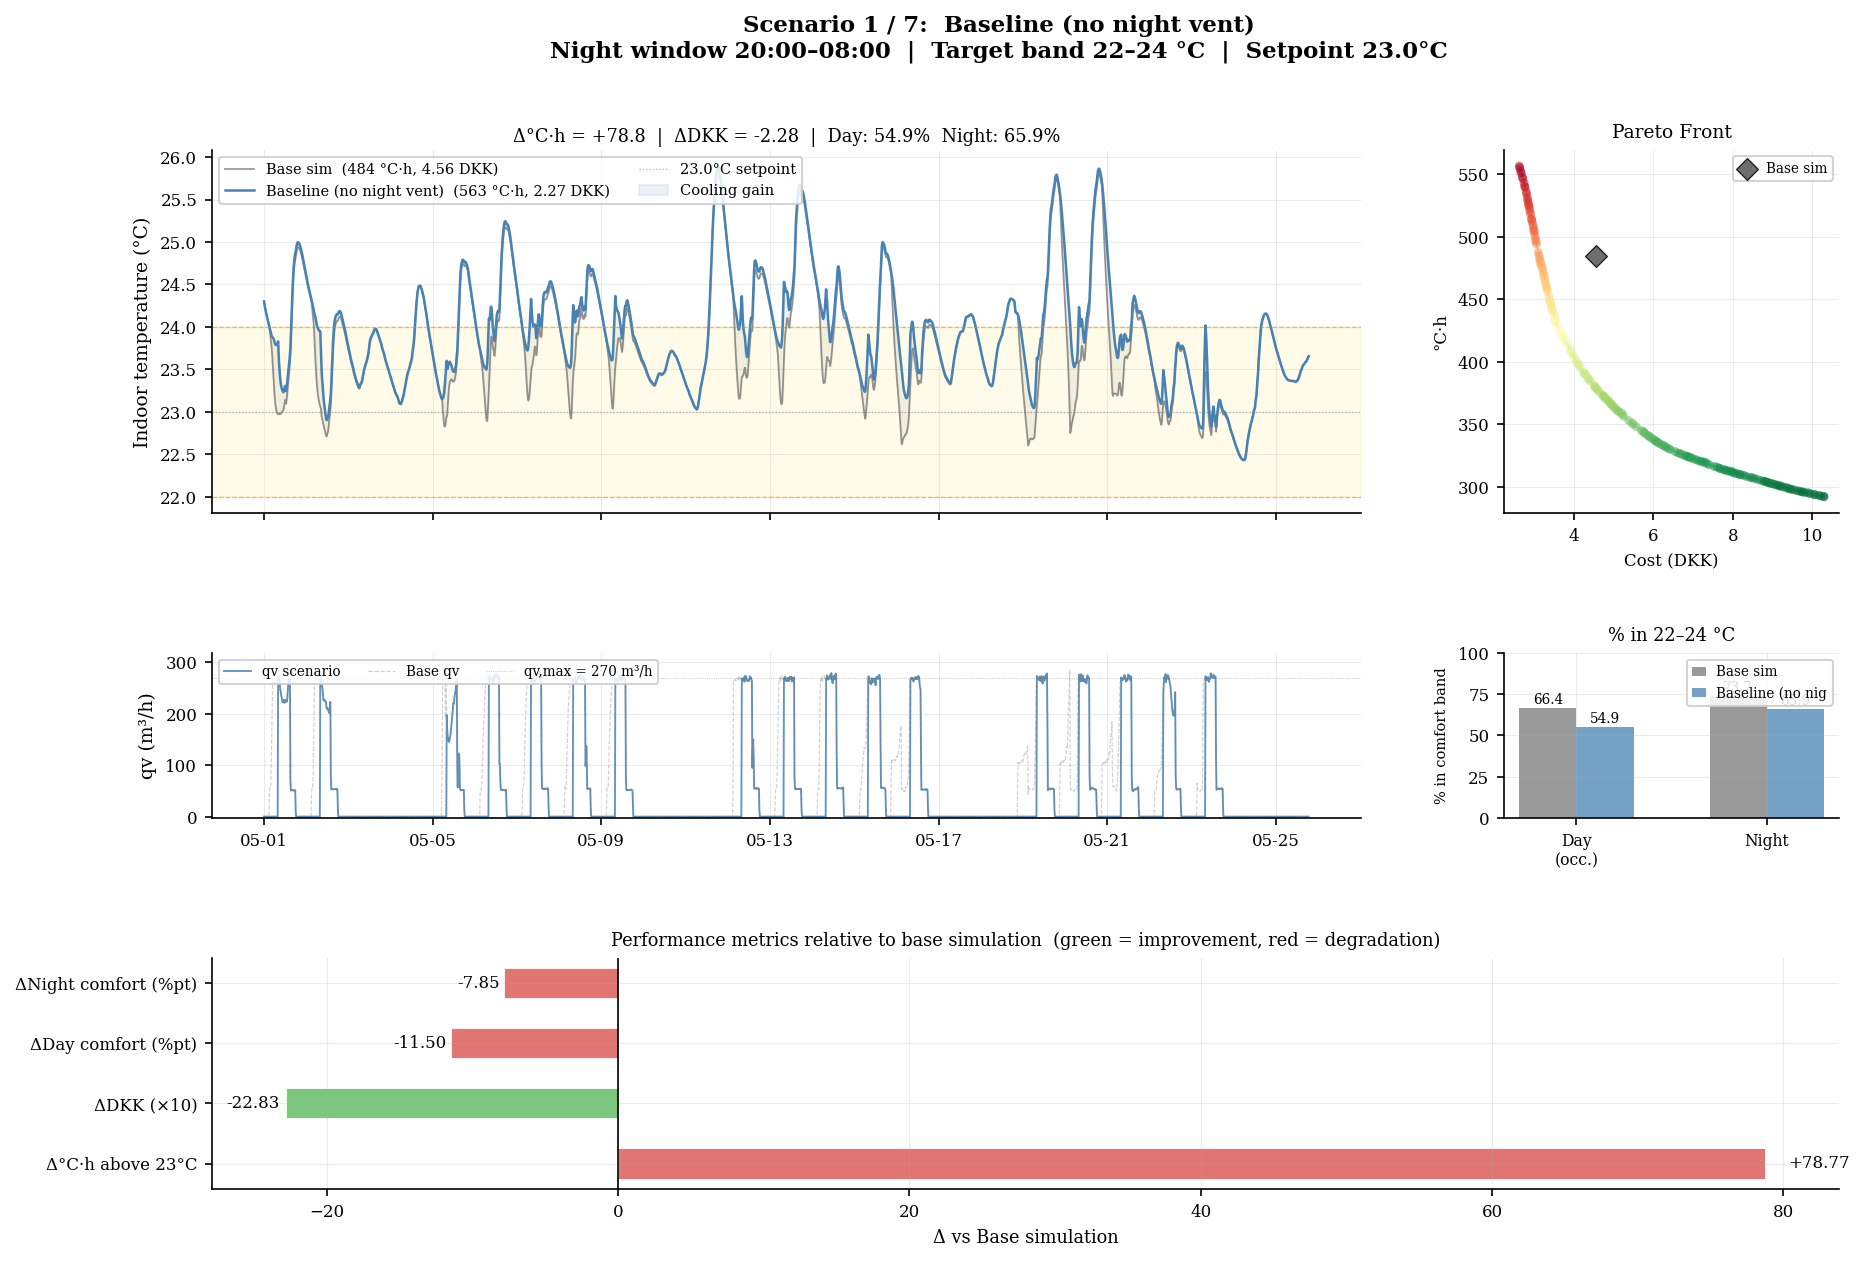

  Saved: ann_pareto_s1_baseline_no_night_vent.png


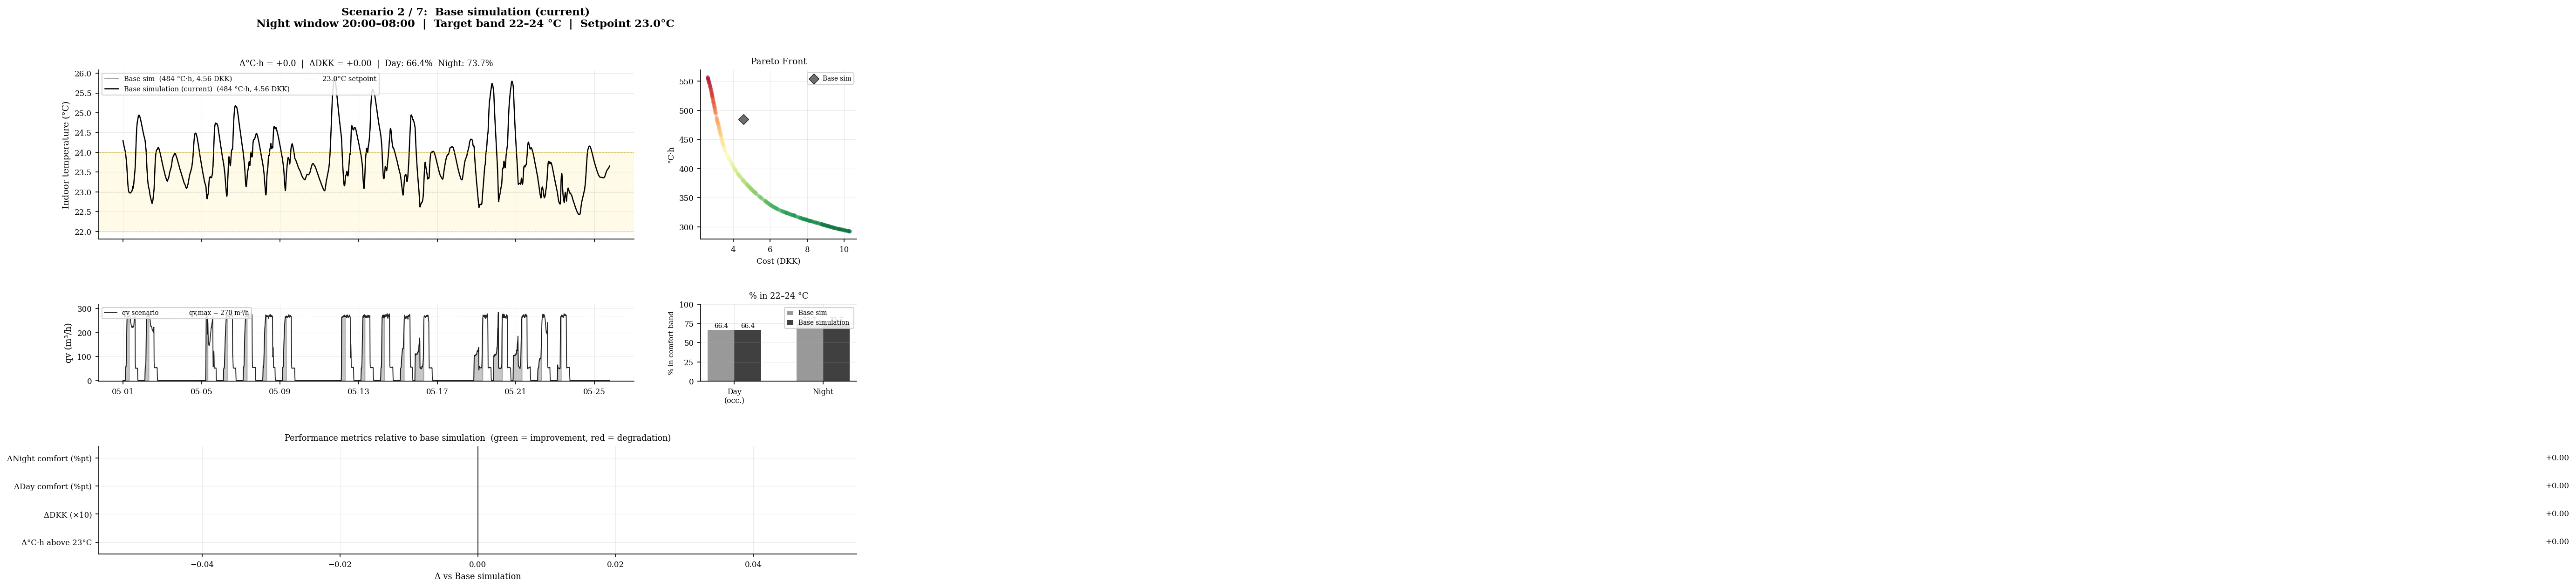

  Saved: ann_pareto_s2_base_simulation_current.png


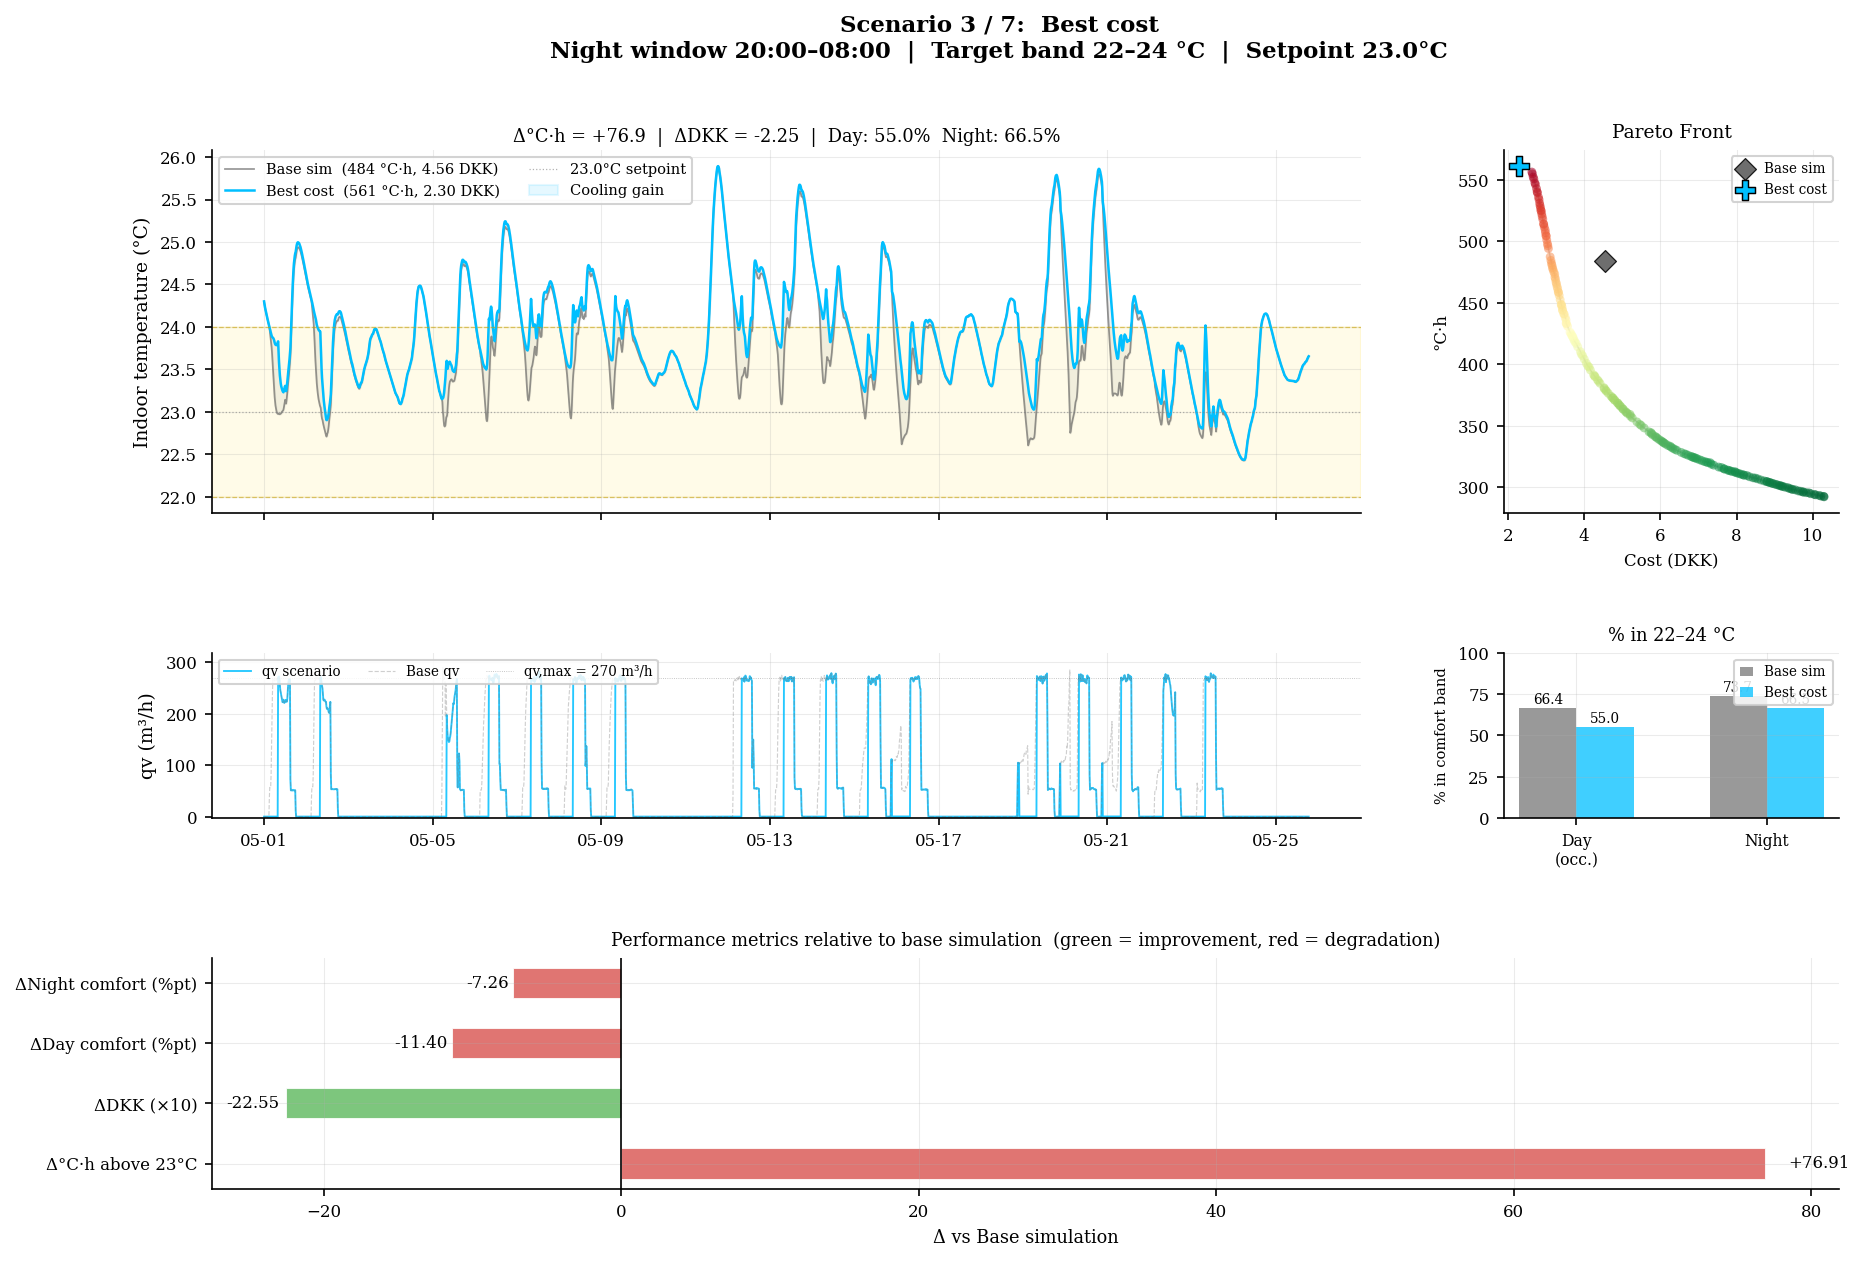

  Saved: ann_pareto_s3_best_cost.png


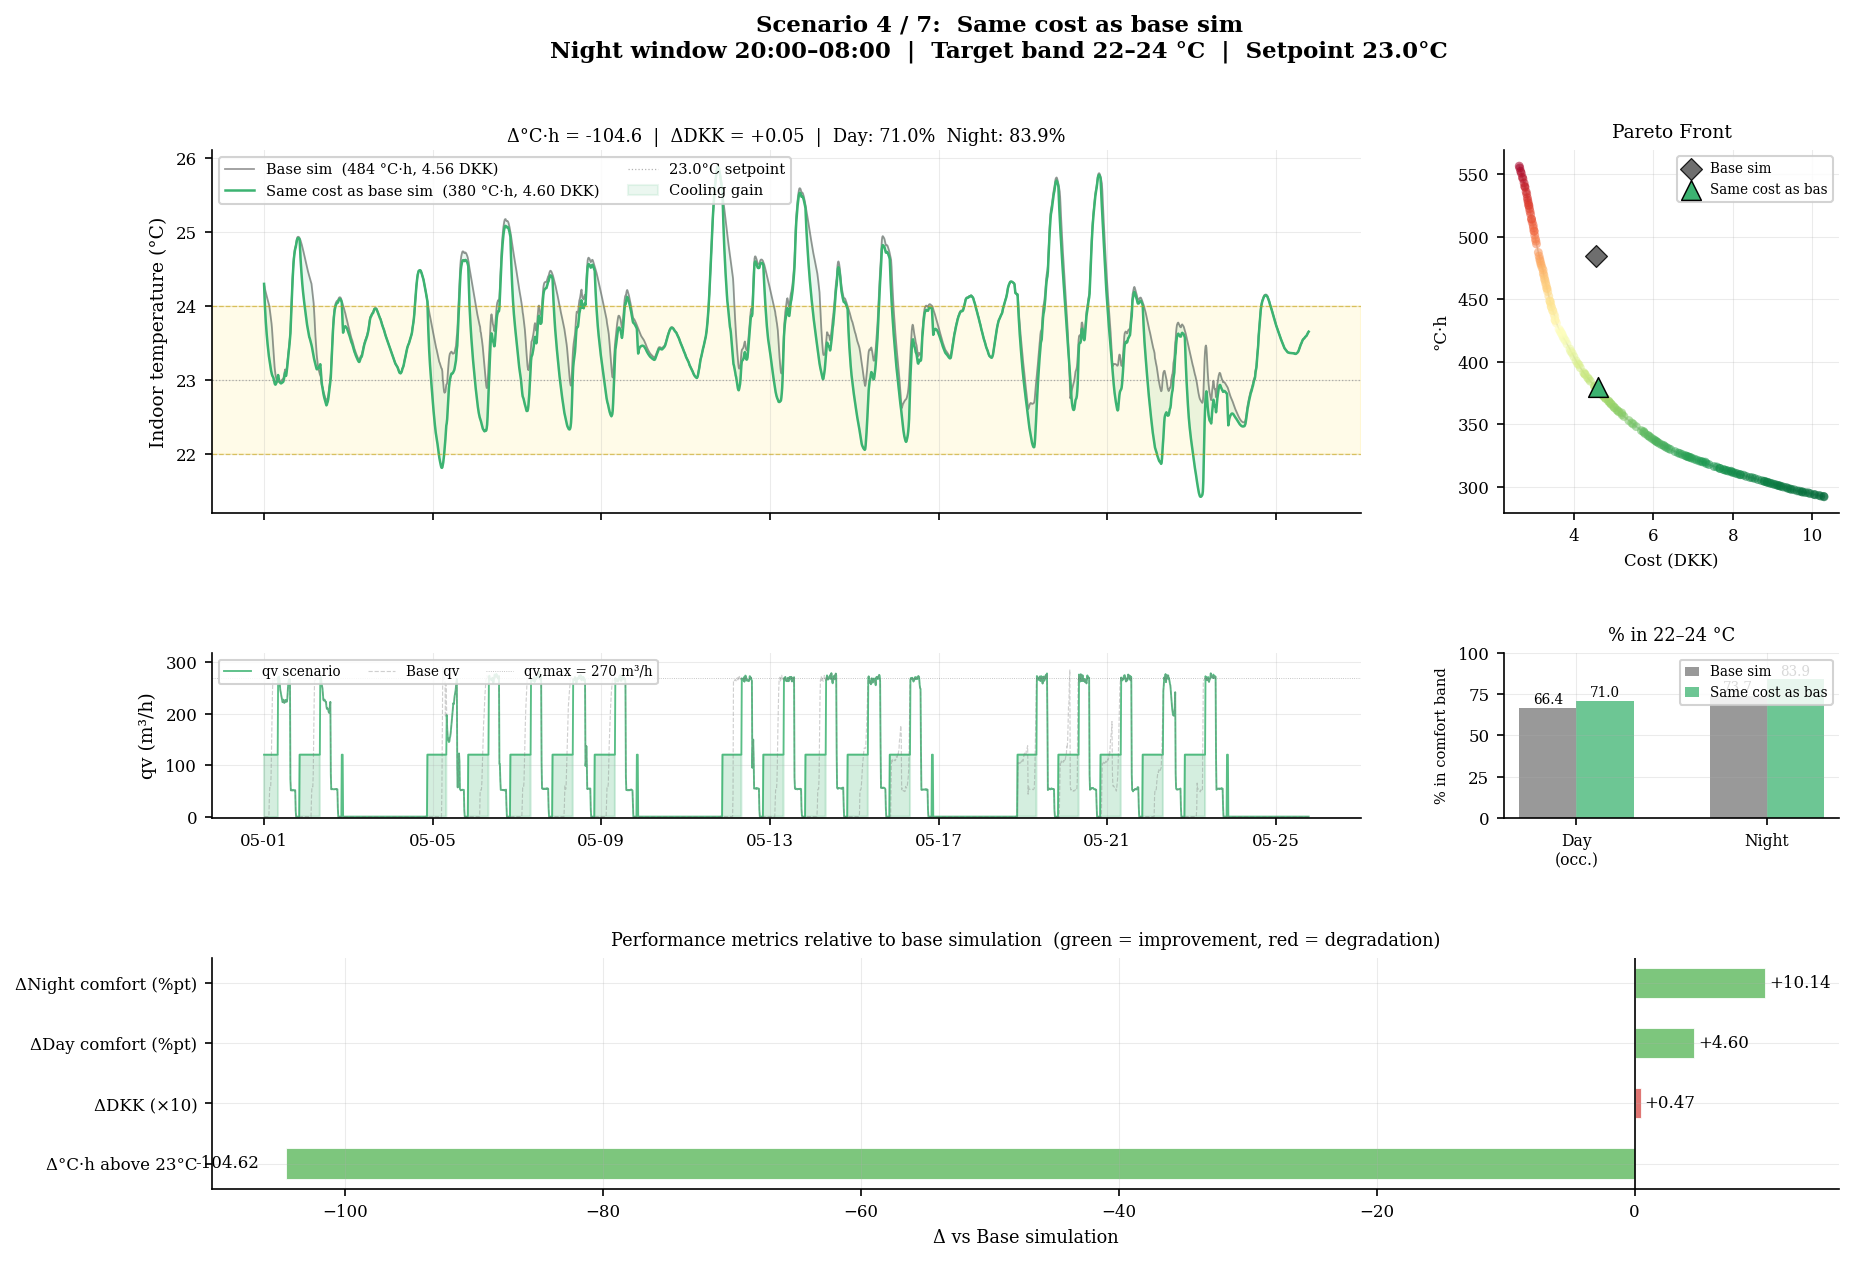

  Saved: ann_pareto_s4_same_cost_as_base_sim.png


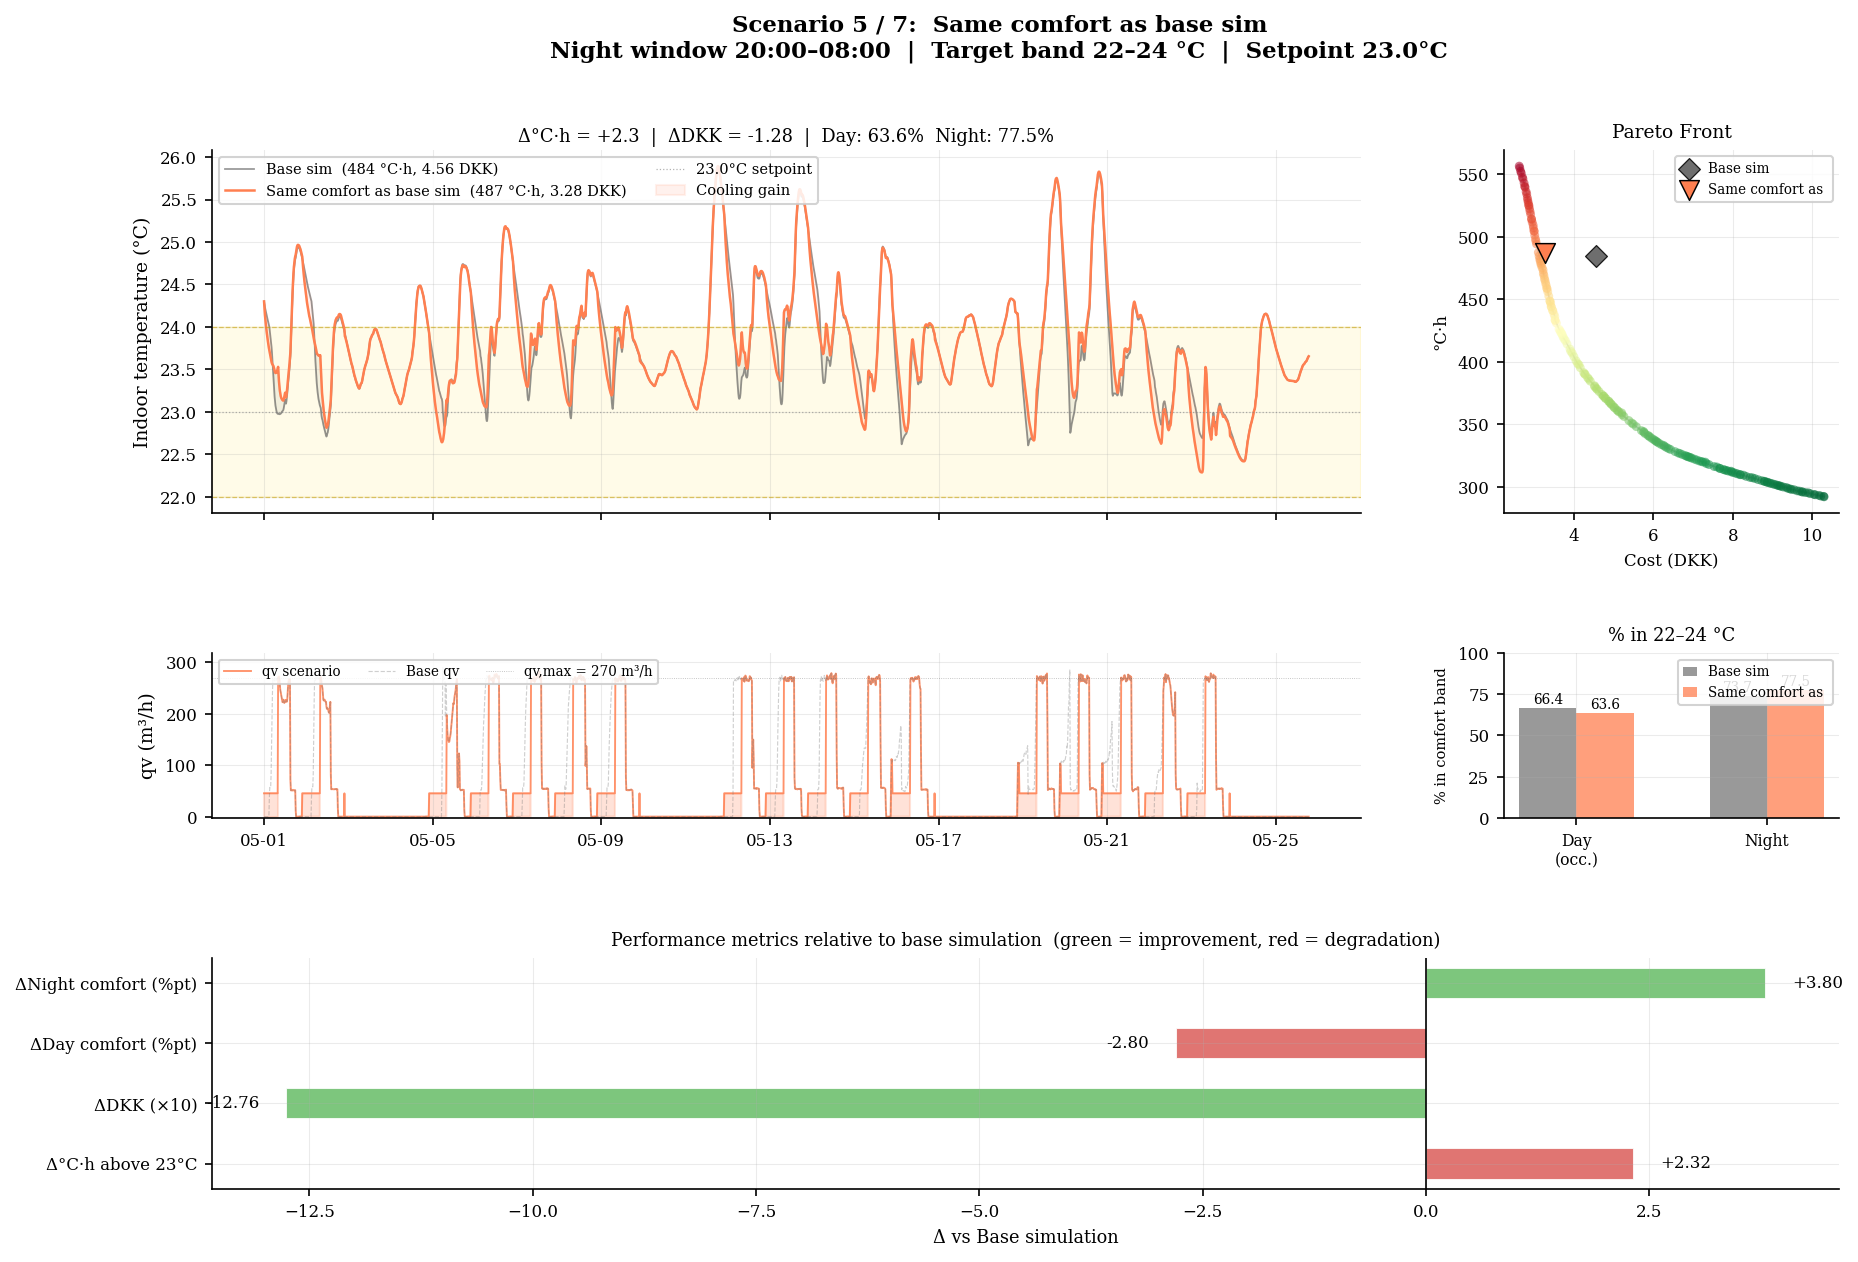

  Saved: ann_pareto_s5_same_comfort_as_base_sim.png


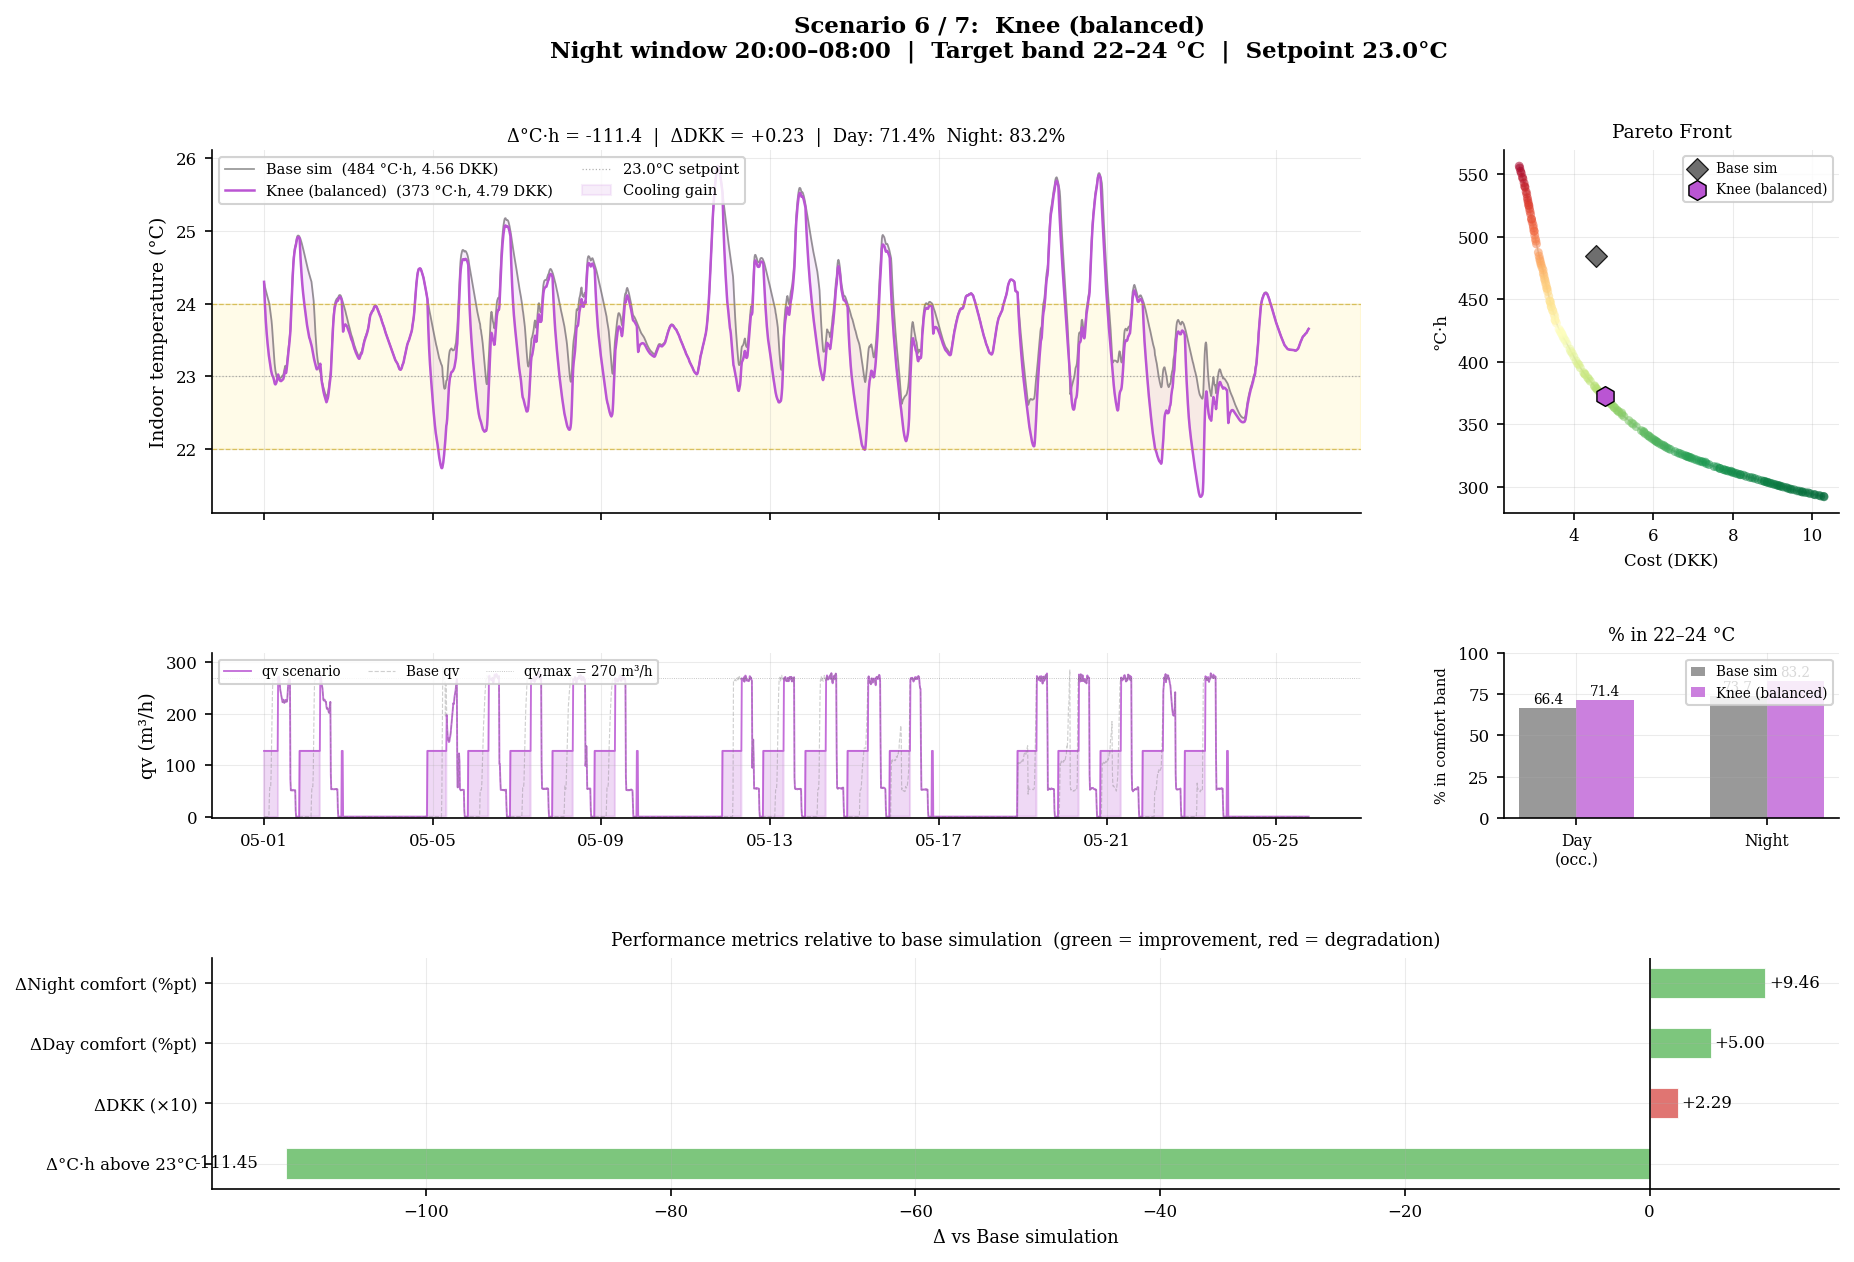

  Saved: ann_pareto_s6_knee_balanced.png


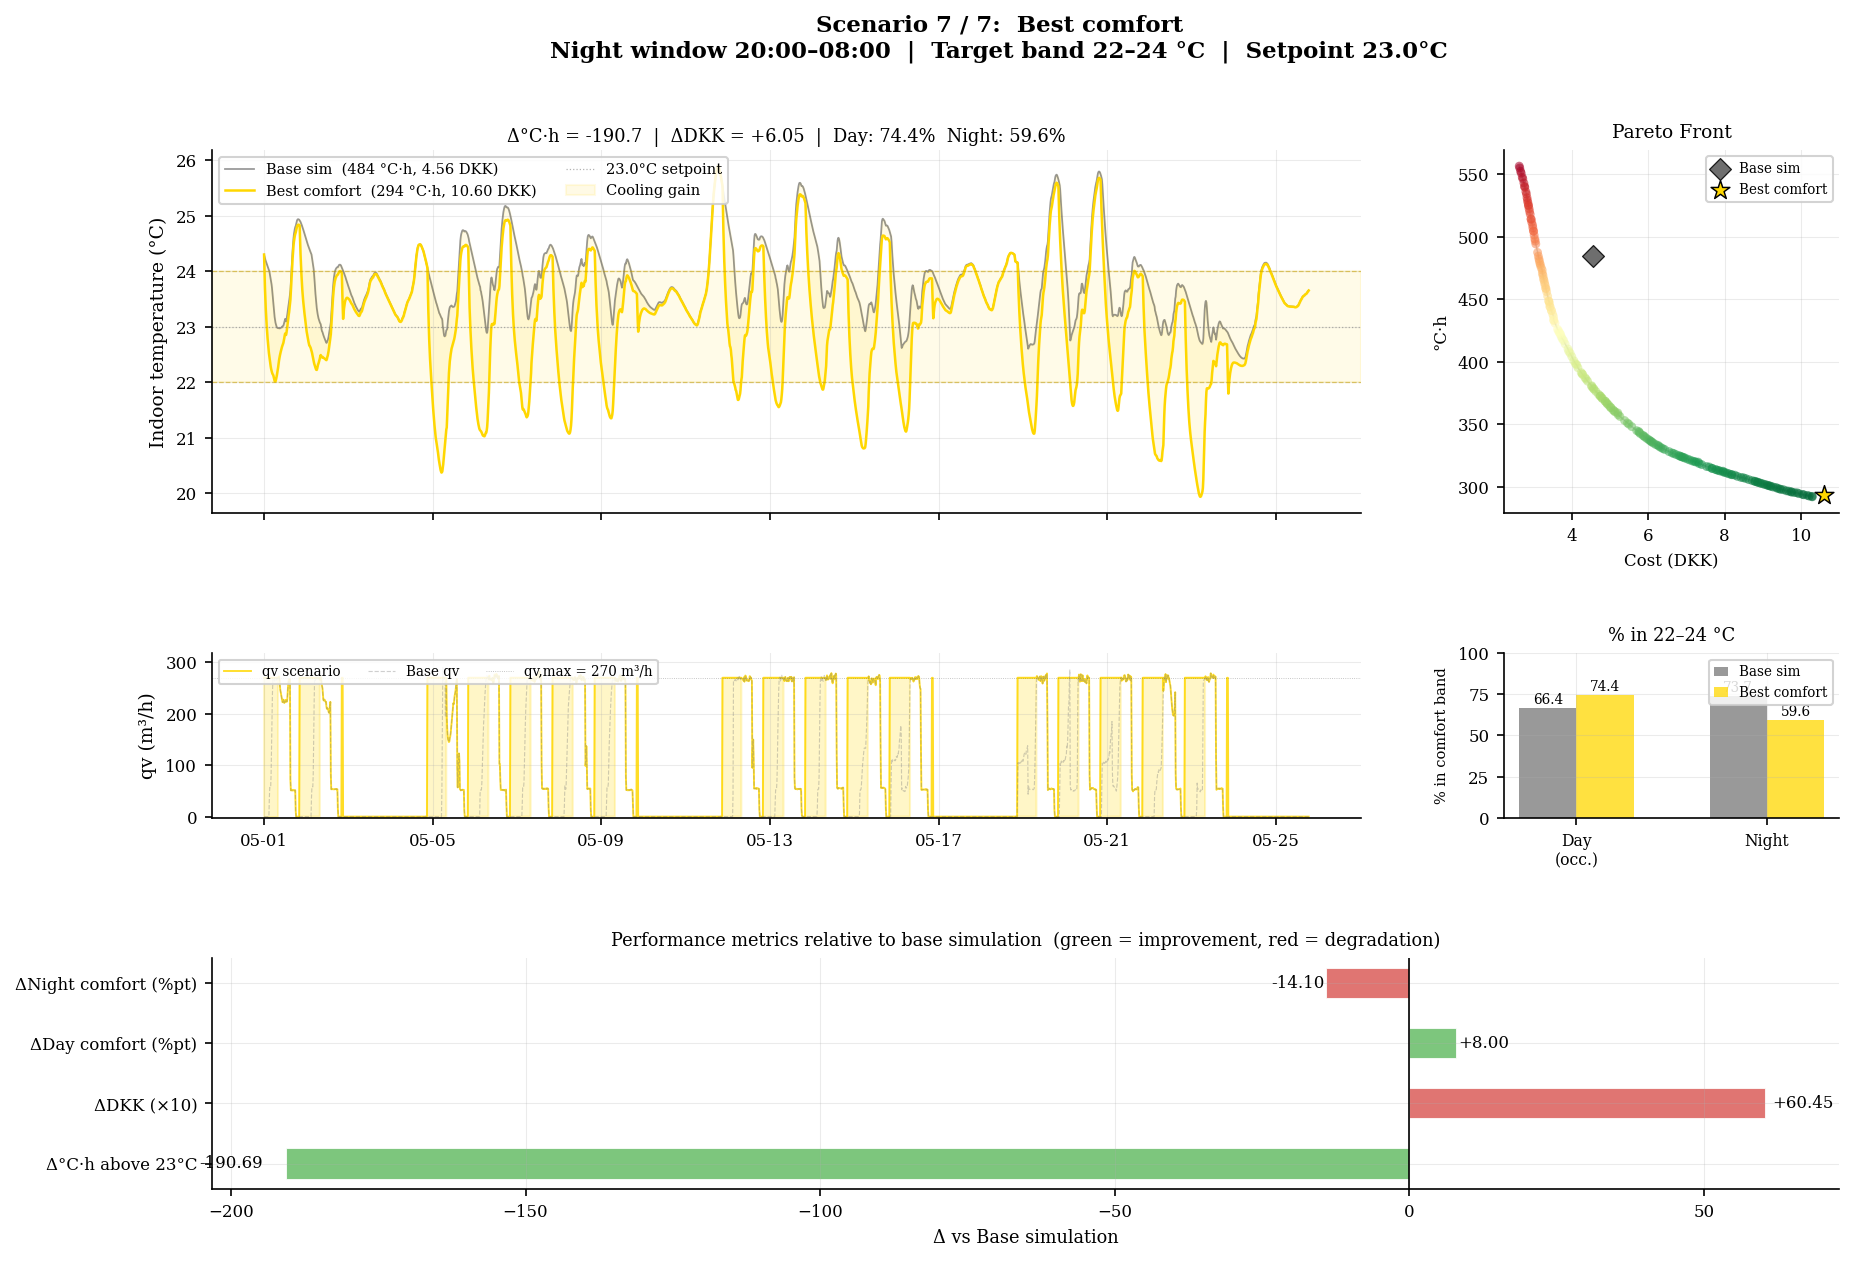

  Saved: ann_pareto_s7_best_comfort.png


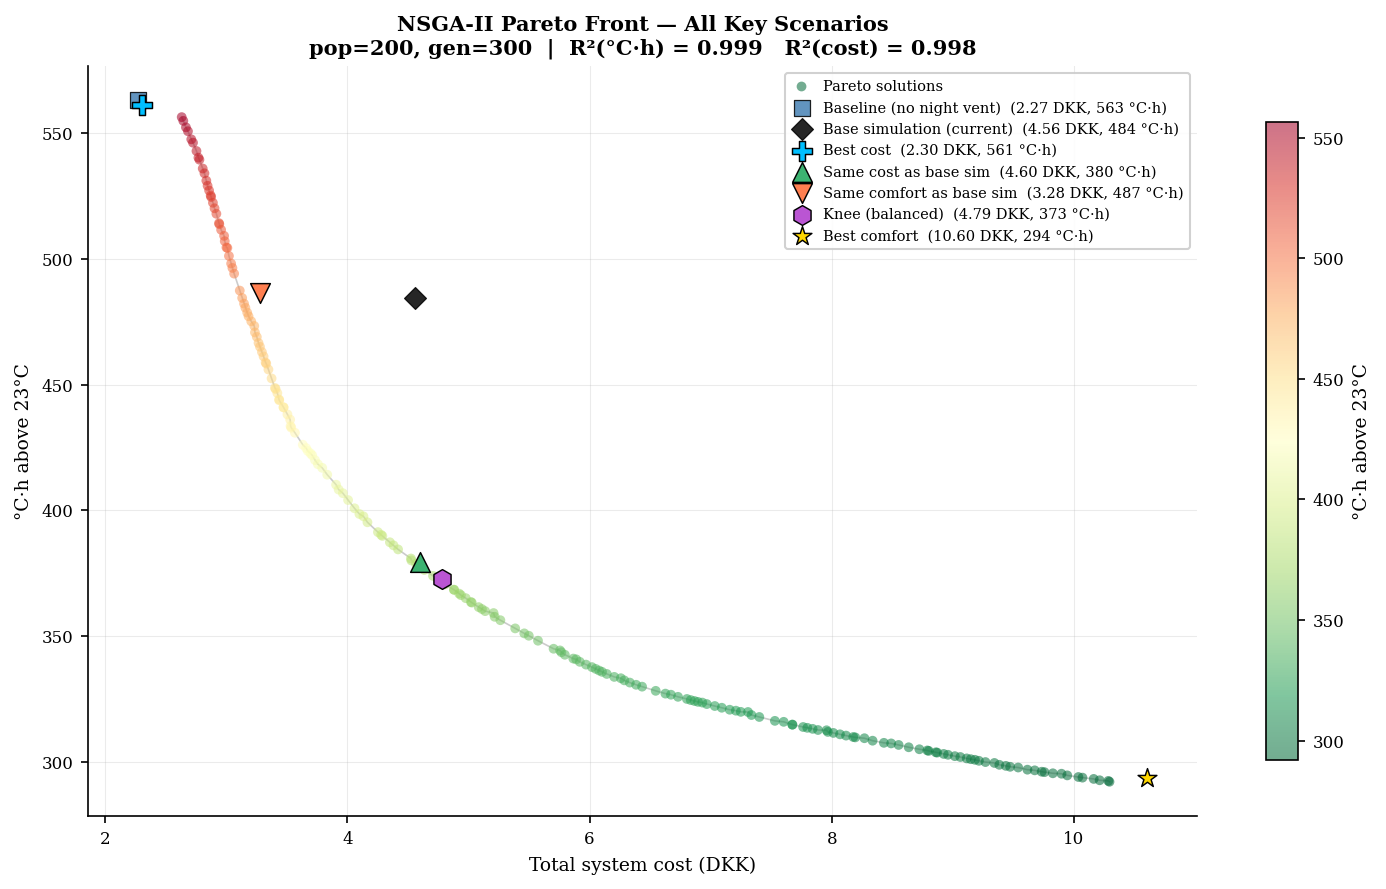

  Saved: ann_nsga2_pareto_summary.png


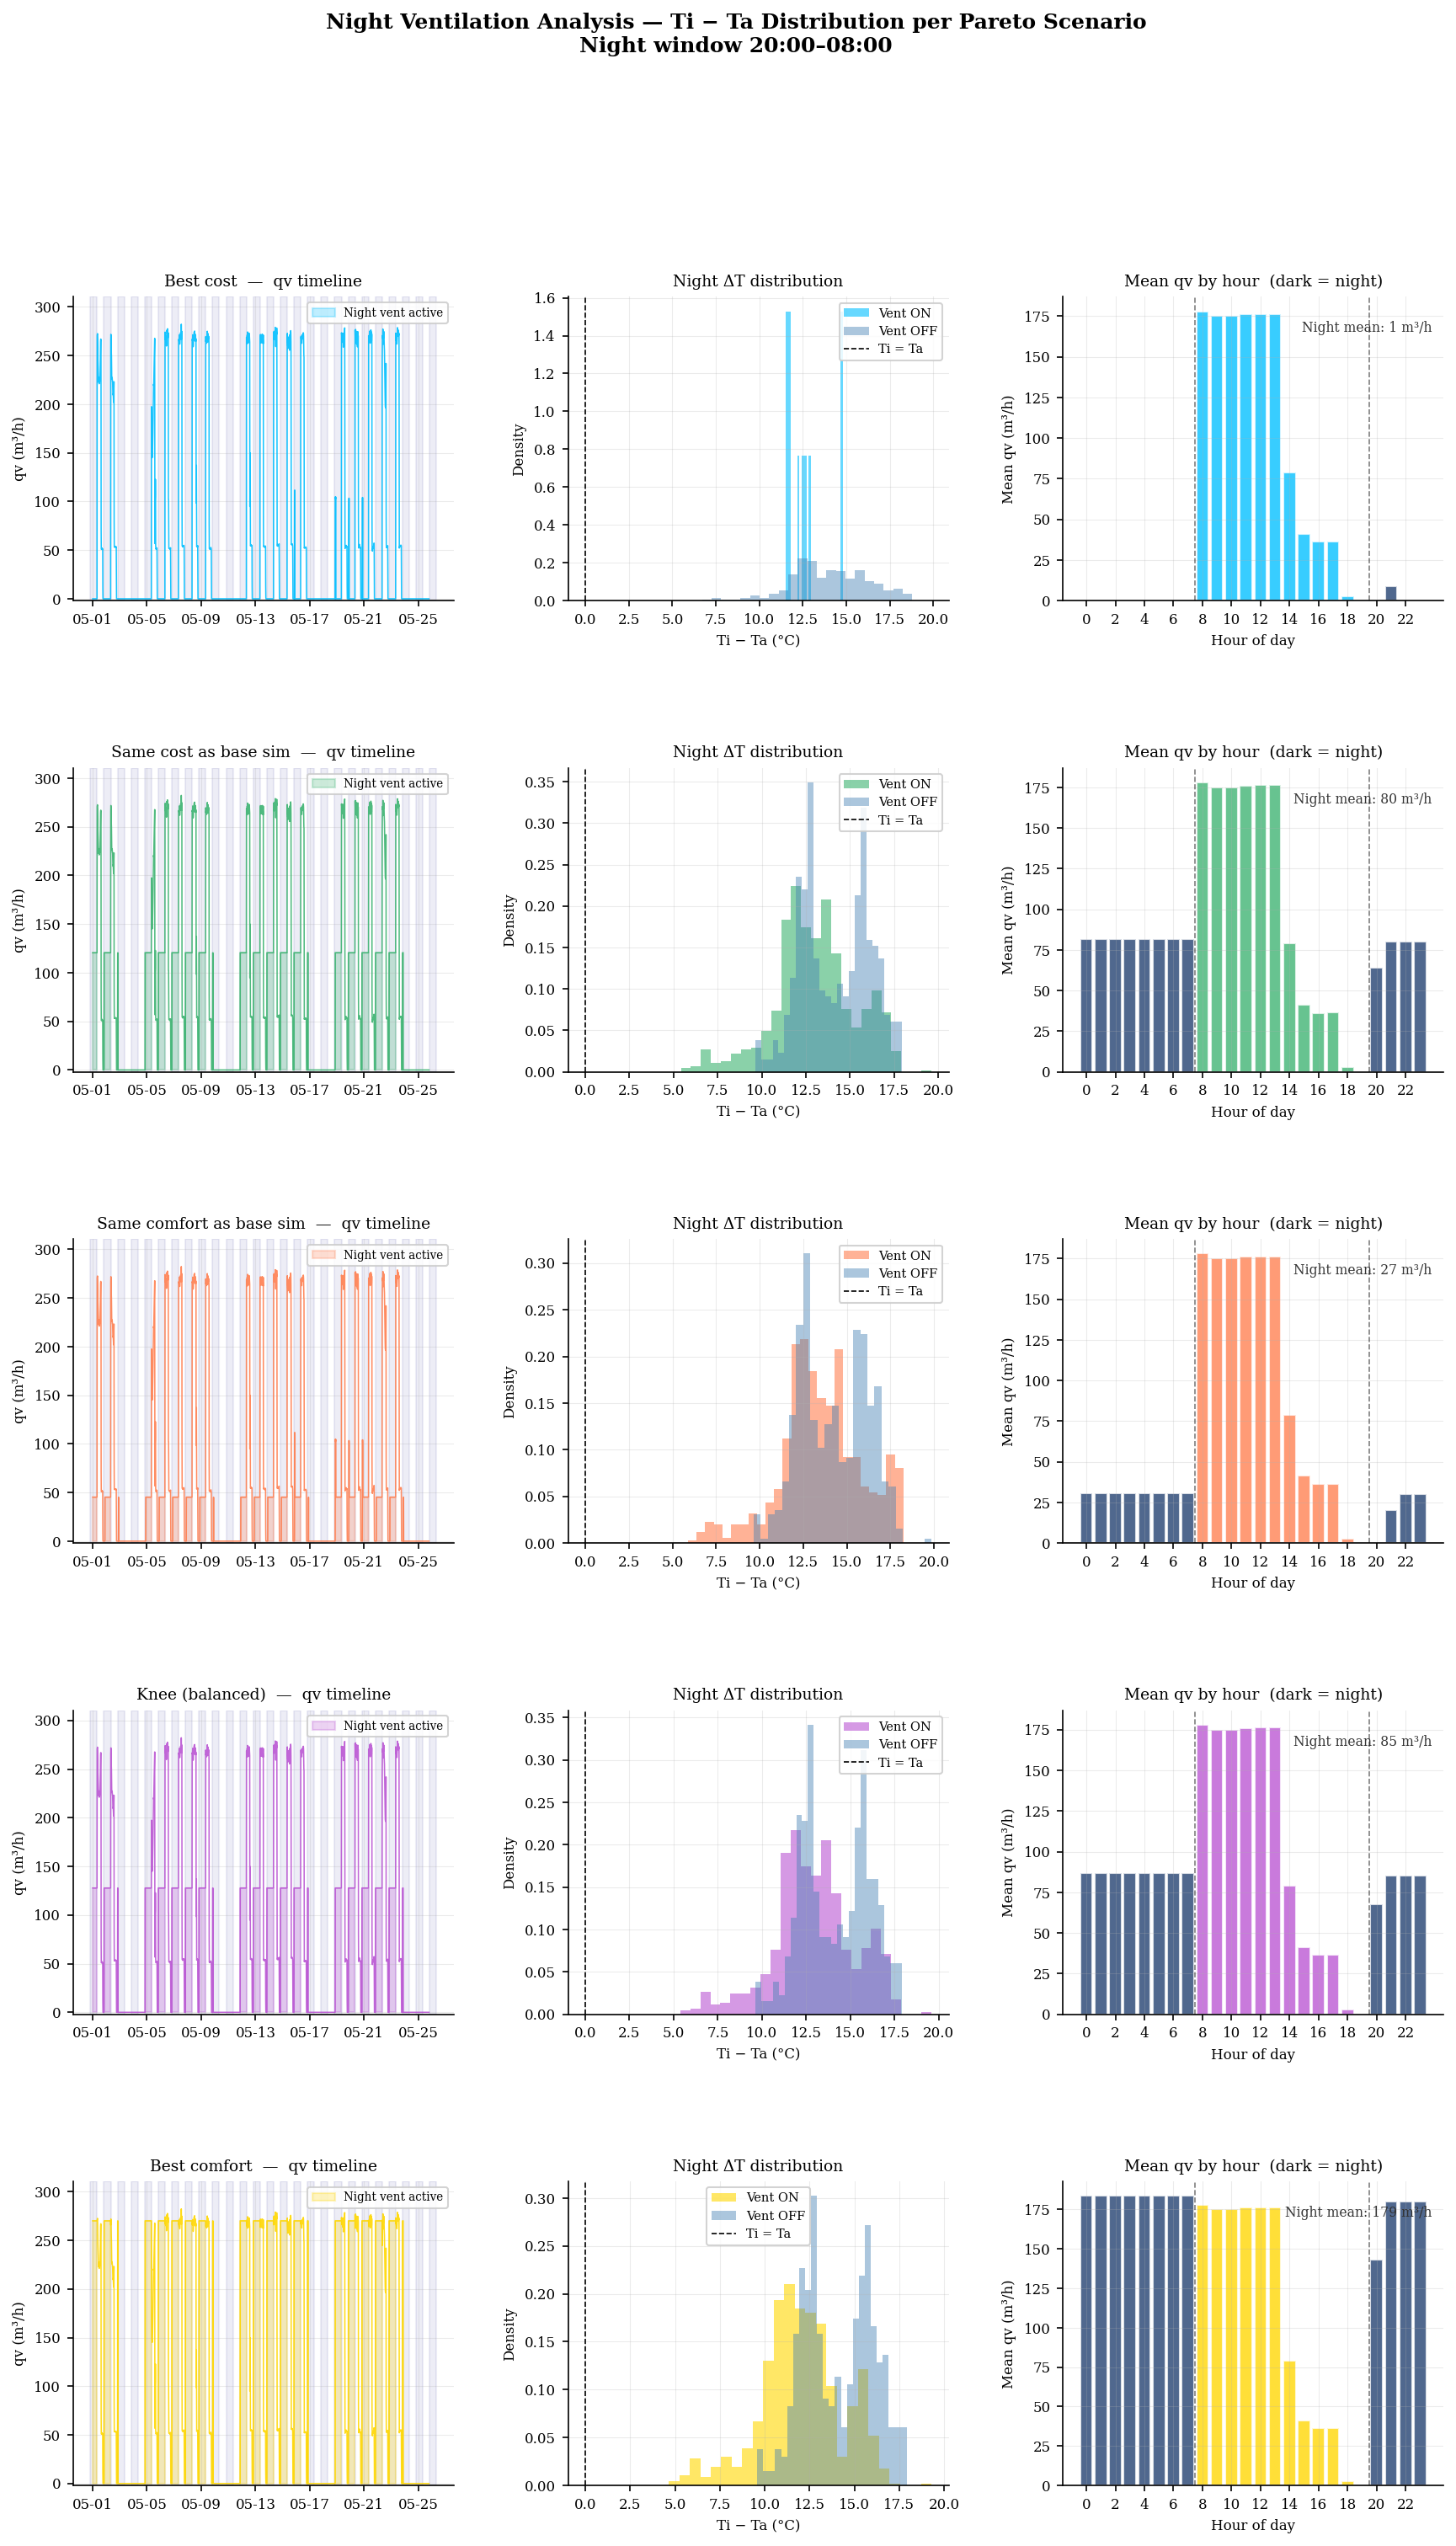

  Saved: night_vent_analysis_scenarios.png

  ✓  All figures saved.


In [23]:
# ════════════════════════════════════════════════════════════════════════════
#  ANN+NSGA-II — INDIVIDUAL SCENARIO FIGURES + NIGHT VENT ANALYSIS
#
#  Produces:
#    ann_pareto_scenario_{i}_{label}.png  — one figure per scenario (7 total)
#    ann_nsga2_pareto_summary.png         — single Pareto front, all scenarios
#    night_vent_analysis_scenarios.png    — Ti/Ta ΔT analysis per Pareto solution
# ════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import re

# ── Matplotlib style for scientific report ────────────────────────────────────
plt.rcParams.update({
    'font.family'      : 'serif',
    'font.size'        : 9,
    'axes.titlesize'   : 10,
    'axes.labelsize'   : 9,
    'xtick.labelsize'  : 8,
    'ytick.labelsize'  : 8,
    'legend.fontsize'  : 7.5,
    'legend.framealpha': 0.85,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.25,
    'grid.linewidth'   : 0.5,
    'lines.linewidth'  : 1.0,
    'figure.dpi'       : 150,
})

# ── Marker style — small, publication-quality ─────────────────────────────────
MRK     = dict(s=60, edgecolors='black', linewidths=0.6, zorder=6)
MRK_KEY = dict(s=90, edgecolors='black', linewidths=0.7, zorder=7)
MRK_REF = dict(s=55, edgecolors='black', linewidths=0.6, zorder=7, alpha=0.85)

# ── Find iso-cost and iso-comfort Pareto solutions ────────────────────────────
iso_cost_idx    = int(np.argmin(np.abs(F_pareto[:, 1] - cost_ref)))
iso_comfort_idx = int(np.argmin(np.abs(F_pareto[:, 0] - dh_above_ref)))

def _resim(idx, label, color, marker):
    params           = X_pareto[idx]
    qv_mod, Tsup_mod = build_X_monthly(params)
    X_mod            = X_train.copy()
    X_mod['qv']      = qv_mod
    X_mod['Tsup']    = Tsup_mod
    res = simulate_night_vent_scenario(
        fitted_params, X_mod, N_hist,
        night_start_hour=0, night_stop_hour=0, qv_night=0,
        rec_duration=rec_duration,
        Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init)
    Ti_v      = np.asarray(res['Ti'])
    dh_v, _   = dh_from_target(Ti_v)
    cost_v    = total_system_cost(qv_mod, Ta_arr, Tsup_mod)
    pct_occ_v = pct_in_band(Ti_v, T_cat1_min, T_cat1_max, occ_mask)
    pct_ngt_v = pct_in_band(Ti_v, T_cat1_min, T_cat1_max, all_night_mask)
    return {'label': label, 'params': params, 'Ti': Ti_v,
            'qv_mod': qv_mod, 'dh_above': dh_v, 'cost': cost_v,
            'pct_occ': pct_occ_v, 'pct_night': pct_ngt_v,
            'color': color, 'marker': marker}

iso_cost_data    = _resim(iso_cost_idx,    'Same cost as base sim',    'mediumseagreen', '^')
iso_comfort_data = _resim(iso_comfort_idx, 'Same comfort as base sim', 'coral',          'v')

SCENARIOS = [
    {'label': 'Baseline (no night vent)',
     'Ti': Ti_baseline, 'qv_mod': qv_baseline,
     'dh_above': dh_above_base, 'cost': cost_baseline,
     'pct_occ': pct_occ_base,
     'pct_night': pct_in_band(Ti_baseline, T_cat1_min, T_cat1_max, all_night_mask),
     'color': 'steelblue', 'marker': 's'},
    {'label': 'Base simulation (current)',
     'Ti': Ti_ref, 'qv_mod': qv_arr,
     'dh_above': dh_above_ref, 'cost': cost_ref,
     'pct_occ': pct_occ_ref, 'pct_night': pct_night_ref,
     'color': 'black', 'marker': 'D'},
    {**verified['Best cost'],       'label': 'Best cost'},
    iso_cost_data,
    iso_comfort_data,
    {**verified['Knee (balanced)'], 'label': 'Knee (balanced)'},
    {**verified['Best comfort'],    'label': 'Best comfort'},
]
_ref = SCENARIOS[1]

# ── Print summary table ───────────────────────────────────────────────────────
print(f"\n{'═'*100}")
print(f"  ANN + NSGA-II — PARETO COMPARISON TABLE")
print(f"{'═'*100}")
print(f"  {'Scenario':<32} {'Start':>7} {'Stop':>6} {'qv':>5}  "
      f"{'°C·h':>8}  {'Δ°C·h':>7}  {'DKK':>7}  {'ΔDKK':>7}  {'Day%':>6}  {'Night%':>7}")
print(f"  {'-'*98}")
for s in SCENARIOS:
    p       = s.get('params', None)
    start_s = f"{p[0]:.1f}h" if p is not None else "—"
    stop_s  = f"{p[1]:.1f}h" if p is not None else "—"
    qv_s    = f"{p[2]:.0f}"  if p is not None else "—"
    d_dh    = s['dh_above'] - dh_above_ref
    d_cost  = s['cost']     - cost_ref
    d_dh_s  = f"{d_dh:+.1f}"   if s['label'] != 'Base simulation (current)' else "—"
    d_c_s   = f"{d_cost:+.2f}" if s['label'] != 'Base simulation (current)' else "—"
    print(f"  {s['label']:<32} {start_s:>7} {stop_s:>6} {qv_s:>5}  "
          f"{s['dh_above']:>8.1f}  {d_dh_s:>7}  {s['cost']:>7.2f}  "
          f"{d_c_s:>7}  {s['pct_occ']:>5.1f}%  {s['pct_night']:>6.1f}%")
print(f"  {'═'*100}")


# ════════════════════════════════════════════════════════════════════════════
#  INDIVIDUAL FIGURE PER SCENARIO
# ════════════════════════════════════════════════════════════════════════════
_sort_pf = np.argsort(F_pareto[:, 1])

for i, s in enumerate(SCENARIOS):
    is_ref = (s['label'] == 'Base simulation (current)')
    color  = s['color']
    d_dh   = s['dh_above'] - _ref['dh_above']
    d_cost = s['cost']     - _ref['cost']

    fig = plt.figure(figsize=(14, 9))
    gs  = gridspec.GridSpec(3, 3, figure=fig,
                            height_ratios=[2.2, 1.0, 1.4],
                            width_ratios=[3.0, 1.5, 1.5],
                            hspace=0.55, wspace=0.32)

    ax_ts  = fig.add_subplot(gs[0, :2])
    ax_qv  = fig.add_subplot(gs[1, :2], sharex=ax_ts)
    ax_pf  = fig.add_subplot(gs[0,  2])
    ax_bar = fig.add_subplot(gs[1,  2])
    ax_met = fig.add_subplot(gs[2, :])

    fig.suptitle(
        f'Scenario {i+1} / {len(SCENARIOS)}:  {s["label"]}\n'
        f'Night window {NIGHT_START:02d}:00–{NIGHT_STOP:02d}:00  |  '
        f'Target band {T_cat1_min:.0f}–{T_cat1_max:.0f} °C  |  Setpoint {T_TARGET}°C',
        fontsize=11, fontweight='bold'
    )

    # ── Ti time series ────────────────────────────────────────────────────────
    ax_ts.plot(index, _ref['Ti'], color='#555555', lw=0.85, alpha=0.6,
               label=f'Base sim  ({_ref["dh_above"]:.0f} °C·h, {_ref["cost"]:.2f} DKK)')
    ax_ts.plot(index, s['Ti'], color=color, lw=1.2,
               label=f'{s["label"]}  ({s["dh_above"]:.0f} °C·h, {s["cost"]:.2f} DKK)')
    ax_ts.axhspan(T_cat1_min, T_cat1_max, alpha=0.09, color='gold', zorder=0)
    ax_ts.axhline(T_cat1_max, color='#c8a000', lw=0.6, ls='--', alpha=0.55)
    ax_ts.axhline(T_cat1_min, color='#c8a000', lw=0.6, ls='--', alpha=0.55)
    ax_ts.axhline(T_TARGET,   color='grey',    lw=0.6, ls=':',  alpha=0.6,
                  label=f'{T_TARGET}°C setpoint')
    if not is_ref:
        ax_ts.fill_between(index, _ref['Ti'], s['Ti'],
            where=(_ref['Ti'] > s['Ti']), alpha=0.10, color=color, label='Cooling gain')
        ax_ts.fill_between(index, _ref['Ti'], s['Ti'],
            where=(_ref['Ti'] < s['Ti']), alpha=0.07, color='#444444')
    ax_ts.set_ylabel('Indoor temperature (°C)')
    ax_ts.set_title(
        f'Δ°C·h = {d_dh:+.1f}  |  ΔDKK = {d_cost:+.2f}  |  '
        f'Day: {s["pct_occ"]:.1f}%  Night: {s["pct_night"]:.1f}%',
        fontsize=8.5, pad=4
    )
    ax_ts.legend(loc='upper left', ncol=2, fontsize=7)
    plt.setp(ax_ts.get_xticklabels(), visible=False)

    # ── qv panel ──────────────────────────────────────────────────────────────
    ax_qv.plot(index, s['qv_mod'], color=color, lw=0.9, alpha=0.85, label='qv scenario')
    if not is_ref:
        ax_qv.plot(index, _ref['qv_mod'], color='#777777', lw=0.55,
                   alpha=0.35, ls='--', label='Base qv')
    # FIX: ta_ok_mask removed — warm-hour cost already penalised via q_cool_cost()
    ax_qv.fill_between(index, s['qv_mod'], 0,
        where=weekday_night_mask, alpha=0.22, color=color)
    ax_qv.axhline(QV_MAX, color='#444444', lw=0.4, ls=':', alpha=0.4,
                  label=f'qv,max = {QV_MAX:.0f} m³/h')
    ax_qv.set_ylabel('qv (m³/h)')
    ax_qv.set_ylim(-3, QV_MAX * 1.18)
    ax_qv.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax_qv.legend(loc='upper left', ncol=3, fontsize=6.5)

    # ── Pareto front ──────────────────────────────────────────────────────────
    sc = ax_pf.scatter(F_pareto[:, 1], F_pareto[:, 0],
                       c=F_pareto[:, 0], cmap='RdYlGn_r', s=18,
                       alpha=0.55, edgecolors='none', zorder=2)
    ax_pf.plot(F_pareto[_sort_pf, 1], F_pareto[_sort_pf, 0],
               color='#333333', lw=0.7, alpha=0.25, zorder=1)
    ax_pf.scatter(_ref['cost'], _ref['dh_above'],
                  marker='D', color='#555555', **{**MRK_REF, 'label': 'Base sim'})
    if s.get('params') is not None:
        ax_pf.scatter(s['cost'], s['dh_above'],
                      marker=s['marker'], color=color,
                      **{**MRK_KEY, 'label': s['label'][:16]})
    ax_pf.set_xlabel('Cost (DKK)', fontsize=8)
    ax_pf.set_ylabel('°C·h', fontsize=8)
    ax_pf.set_title('Pareto Front', fontsize=9)
    ax_pf.legend(fontsize=6.5, handlelength=1.2)

    # ── Comfort bar ───────────────────────────────────────────────────────────
    x, w = np.arange(2), 0.30
    b_r = ax_bar.bar(x - w/2, [_ref['pct_occ'], _ref['pct_night']], w,
                     color='#555555', alpha=0.60, label='Base sim')
    b_a = ax_bar.bar(x + w/2, [s['pct_occ'],    s['pct_night']   ], w,
                     color=color,    alpha=0.75, label=s['label'][:16])
    for b in list(b_r) + list(b_a):
        ax_bar.text(b.get_x() + b.get_width()/2, b.get_height() + 0.8,
                    f'{b.get_height():.1f}', ha='center', va='bottom', fontsize=6.5)
    ax_bar.set_xticks(x)
    ax_bar.set_xticklabels(['Day\n(occ.)', 'Night'], fontsize=7.5)
    ax_bar.set_ylim(0, 100)
    ax_bar.set_ylabel('% in comfort band', fontsize=7)
    ax_bar.legend(fontsize=6.5, loc='upper right', handlelength=1.0)
    ax_bar.set_title('% in 22–24 °C', fontsize=8.5)

    # ── Metrics bar (horizontal) ──────────────────────────────────────────────
    all_labels = ['Δ°C·h above 23°C', 'ΔDKK (×10)', 'ΔDay comfort (%pt)', 'ΔNight comfort (%pt)']
    all_vals   = [d_dh, d_cost * 10,
                  s['pct_occ']   - _ref['pct_occ'],
                  s['pct_night'] - _ref['pct_night']]
    bar_cols   = ['#d9534f' if v > 0 else '#5cb85c' for v in all_vals[:2]] + \
                 ['#5cb85c' if v > 0 else '#d9534f' for v in all_vals[2:]]
    bars_m = ax_met.barh(all_labels, all_vals, color=bar_cols, alpha=0.80,
                         edgecolor='white', linewidth=0.5, height=0.5)
    ax_met.axvline(0, color='black', lw=0.8)
    for b, v in zip(bars_m, all_vals):
        offset = max(abs(v) * 0.02, 0.3)
        ax_met.text(v + (offset if v >= 0 else -offset), b.get_y() + b.get_height()/2,
                    f'{v:+.2f}', va='center',
                    ha='left' if v >= 0 else 'right', fontsize=8)
    ax_met.set_xlabel('Δ vs Base simulation', fontsize=8.5)
    ax_met.set_title(
        'Performance metrics relative to base simulation'
        '  (green = improvement, red = degradation)',
        fontsize=8.5
    )

    fname = re.sub(r'[^a-z0-9]+', '_', s['label'].lower()).strip('_')
    plt.savefig(f'ann_pareto_s{i+1}_{fname}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved: ann_pareto_s{i+1}_{fname}.png")


# ════════════════════════════════════════════════════════════════════════════
#  PARETO SUMMARY — all scenarios annotated
# ════════════════════════════════════════════════════════════════════════════
fig_sum, ax_s = plt.subplots(figsize=(10, 6))
sc_s = ax_s.scatter(F_pareto[:, 1], F_pareto[:, 0],
                    c=F_pareto[:, 0], cmap='RdYlGn_r', s=22,
                    alpha=0.55, edgecolors='none', zorder=2, label='Pareto solutions')
ax_s.plot(F_pareto[_sort_pf, 1], F_pareto[_sort_pf, 0],
          color='#333333', lw=0.8, alpha=0.25, zorder=1)
plt.colorbar(sc_s, ax=ax_s, label='°C·h above 23°C', shrink=0.85)

for s in SCENARIOS:
    if s['label'] in ('Baseline (no night vent)', 'Base simulation (current)'):
        ax_s.scatter(s['cost'], s['dh_above'],
                     marker=s['marker'], color=s['color'], **MRK_REF,
                     label=f'{s["label"]}  ({s["cost"]:.2f} DKK, {s["dh_above"]:.0f} °C·h)')
    elif s.get('params') is not None:
        ax_s.scatter(s['cost'], s['dh_above'],
                     marker=s['marker'], color=s['color'], **MRK_KEY,
                     label=f'{s["label"]}  ({s["cost"]:.2f} DKK, {s["dh_above"]:.0f} °C·h)')

ax_s.set_xlabel('Total system cost (DKK)')
ax_s.set_ylabel('°C·h above 23°C')
ax_s.set_title(
    f'NSGA-II Pareto Front — All Key Scenarios\n'
    f'pop={NSGA_POP}, gen={NSGA_GEN}  |  '
    f'R²(°C·h) = {r2_dh:.3f}   R²(cost) = {r2_cost:.3f}',
    fontweight='bold'
)
ax_s.legend(fontsize=7, loc='upper right', handlelength=1.4,
            framealpha=0.9, edgecolor='#cccccc')
plt.tight_layout()
plt.savefig('ann_nsga2_pareto_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Saved: ann_nsga2_pareto_summary.png")


# ════════════════════════════════════════════════════════════════════════════
#  NIGHT VENTILATION ANALYSIS — Ti−Ta distributions per Pareto scenario
# ════════════════════════════════════════════════════════════════════════════
NIGHT_START_NV = NIGHT_START
NIGHT_STOP_NV  = NIGHT_STOP
hours_arr      = np.array([t.hour + t.minute / 60.0 for t in index])
night_mask_nv  = (hours_arr >= NIGHT_START_NV) | (hours_arr < NIGHT_STOP_NV)
Ta_full        = np.asarray(X_train['Ta'], dtype=float)

pareto_scens = [s for s in SCENARIOS if s.get('params') is not None]
n_ps         = len(pareto_scens)

fig_nv = plt.figure(figsize=(14, 4.5 * n_ps))
gs_nv  = gridspec.GridSpec(n_ps, 3, figure=fig_nv, hspace=0.55, wspace=0.30)
fig_nv.suptitle(
    'Night Ventilation Analysis — Ti − Ta Distribution per Pareto Scenario\n'
    f'Night window {NIGHT_START_NV:02d}:00–{NIGHT_STOP_NV:02d}:00',
    fontsize=12, fontweight='bold'
)

for row, s in enumerate(pareto_scens):
    Ti_s   = np.asarray(s['Ti'],     dtype=float)
    qv_s   = np.asarray(s['qv_mod'], dtype=float)
    dT_all = Ti_s - Ta_full
    dT_ngt = dT_all[night_mask_nv]
    qv_ngt = qv_s[night_mask_nv]

    vent_on_ngt  = qv_ngt > 1.0
    vent_off_ngt = ~vent_on_ngt

    # ── qv timeline ──────────────────────────────────────────────────────────
    ax_tl = fig_nv.add_subplot(gs_nv[row, 0])
    ax_tl.plot(index, qv_s, color=s['color'], lw=0.75, alpha=0.9)
    ax_tl.fill_between(index, qv_s, 0,
        where=night_mask_nv & (qv_s > 1.0), alpha=0.25, color=s['color'],
        label='Night vent active')
    day_start_nv = index[0].normalize()
    for d in range((index[-1] - index[0]).days + 2):
        ns = day_start_nv + pd.Timedelta(hours=NIGHT_START_NV + d*24 - 24)
        ne = day_start_nv + pd.Timedelta(hours=NIGHT_STOP_NV  + d*24)
        ax_tl.axvspan(ns, ne, alpha=0.07, color='navy', zorder=0)
    ax_tl.set_ylabel('qv (m³/h)', fontsize=8)
    ax_tl.set_ylim(-2, QV_MAX * 1.15)
    ax_tl.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax_tl.set_title(f'{s["label"]}  —  qv timeline', fontsize=9)
    ax_tl.legend(fontsize=6.5)

    # ── ΔT histogram (night only) ─────────────────────────────────────────────
    ax_ht = fig_nv.add_subplot(gs_nv[row, 1])
    if vent_on_ngt.sum() > 0:
        ax_ht.hist(dT_ngt[vent_on_ngt],  bins=25, color=s['color'],
                   alpha=0.60, density=True, label='Vent ON')
    ax_ht.hist(dT_ngt[vent_off_ngt], bins=25, color='steelblue',
               alpha=0.45, density=True, label='Vent OFF')
    ax_ht.axvline(0, color='black', lw=0.8, ls='--', label='Ti = Ta')
    ax_ht.set_xlabel('Ti − Ta (°C)', fontsize=8)
    ax_ht.set_ylabel('Density', fontsize=8)
    ax_ht.set_title('Night ΔT distribution', fontsize=9)
    ax_ht.legend(fontsize=7)

    # ── Hourly mean qv profile ────────────────────────────────────────────────
    ax_hr = fig_nv.add_subplot(gs_nv[row, 2])
    hour_int = np.array([t.hour for t in index])
    qv_by_hr = np.array([qv_s[hour_int == h].mean() for h in range(24)])
    bar_cols = ['#1f3d6e' if (h >= NIGHT_START_NV or h < NIGHT_STOP_NV)
                else s['color'] for h in range(24)]
    ax_hr.bar(range(24), qv_by_hr, color=bar_cols, alpha=0.78,
              edgecolor='white', width=0.85)
    ax_hr.axvline(NIGHT_START_NV - 0.5, color='black', lw=0.8, ls='--', alpha=0.5)
    ax_hr.axvline(NIGHT_STOP_NV  - 0.5, color='black', lw=0.8, ls='--', alpha=0.5)
    ax_hr.set_xlabel('Hour of day', fontsize=8)
    ax_hr.set_ylabel('Mean qv (m³/h)', fontsize=8)
    ax_hr.set_xticks(range(0, 24, 2))
    ax_hr.set_title('Mean qv by hour  (dark = night)', fontsize=9)
    qv_night_mean = qv_s[night_mask_nv].mean()
    ax_hr.text(0.97, 0.92, f'Night mean: {qv_night_mean:.0f} m³/h',
               transform=ax_hr.transAxes, ha='right', va='top',
               fontsize=7.5, color='#333333')

plt.savefig('night_vent_analysis_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Saved: night_vent_analysis_scenarios.png")
print("\n  ✓  All figures saved.")

# Rolling MPC

In [37]:
# ════════════════════════════════════════════════════════════════════════════
#  MPC CONTEXT PREPEND — Load last 14 days of April from april .pkl
#  and extend all companion arrays so the rolling MPC's lookback window
#  is fully consumed by prior-month data, leaving May 1–25 fully optimised.
# ════════════════════════════════════════════════════════════════════════════

import pickle
import numpy as np
import pandas as pd

RESULTS_FILE_APR = "simulation_results_mcmc_2025_04.pkl"

with open(RESULTS_FILE_APR, "rb") as f:
    saved_apr = pickle.load(f)

df_apr       = saved_apr["df"]
X_apr        = saved_apr["X_train"]        # full April X_train
train_res_apr = saved_apr["train_results"]

# ── Infer the simulated Ti for April from train_results ──────────────────────
# Adjust the key name below if your pkl uses a different field
if hasattr(train_res_apr, 'Z'):
    Ti_apr_full = np.asarray(train_res_apr.Z, dtype=float)
elif isinstance(train_res_apr, dict) and 'Ti' in train_res_apr:
    Ti_apr_full = np.asarray(train_res_apr['Ti'], dtype=float)
else:
    # Fallback: use measured Ti column if available
    Ti_apr_full = np.asarray(X_apr['Ti'], dtype=float)

print(f"April data loaded:  {X_apr.index[0].date()}  →  {X_apr.index[-1].date()}"
      f"  ({len(X_apr)} steps)")

# ── Take only the last 14 days of April ──────────────────────────────────────
dt_h_apr   = (X_apr.index[1] - X_apr.index[0]).total_seconds() / 3600.0
n_prepend  = int(MPC_LOOKBACK_DAYS * 24 / dt_h_apr)   # 14 days in timesteps

X_pre      = X_apr.iloc[-n_prepend:]
Ti_pre     = Ti_apr_full[-n_prepend:]

print(f"Prepend window:     {X_pre.index[0].date()}  →  {X_pre.index[-1].date()}"
      f"  ({len(X_pre)} steps = {MPC_LOOKBACK_DAYS} days)")

# ── Verify column alignment with May X_train ─────────────────────────────────
missing_cols = set(X_train.columns) - set(X_pre.columns)
extra_cols   = set(X_pre.columns)   - set(X_train.columns)
if missing_cols:
    print(f"  ⚠ Columns in May but NOT in April: {missing_cols} — will fill with 0")
    for c in missing_cols:
        X_pre[c] = 0.0
if extra_cols:
    print(f"  ℹ Columns in April but NOT in May (dropped): {extra_cols}")
    X_pre = X_pre[X_train.columns]

# ── Build extended arrays (April tail + full May) ────────────────────────────
X_train_ext   = pd.concat([X_pre, X_train])
index_ext     = X_train_ext.index

# qv_arr: use the April base qv from X_pre directly
qv_arr_pre    = np.asarray(X_pre['qv'], dtype=float)
qv_arr_ext    = np.concatenate([qv_arr_pre, qv_arr])

# Ti_ref: stitch April simulated Ti + May Ti_ref
Ti_ref_ext    = np.concatenate([Ti_pre, Ti_ref])

# N_hist: occupancy profile — derive from hours if not stored separately
if 'N' in X_pre.columns:
    N_hist_pre = np.asarray(X_pre['N'], dtype=float)
else:
    N_hist_pre = np.zeros(len(X_pre))
N_hist_ext    = np.concatenate([N_hist_pre, np.asarray(N_hist, dtype=float)])

# ── Extend globals patched by _mpc_cost ──────────────────────────────────────
def _extend_global(name, pre_arr):
    """Concatenate pre_arr with current global array `name`."""
    gb = globals()
    if name in gb and hasattr(gb[name], '__len__'):
        gb[name + '_ext'] = np.concatenate(
            [np.asarray(pre_arr, dtype=float),
             np.asarray(gb[name],  dtype=float)])
    else:
        gb[name + '_ext'] = np.asarray(pre_arr, dtype=float)

# nighttime_mask — recompute from DatetimeIndex
def _make_night_mask(idx, start_h=NIGHT_START, stop_h=NIGHT_STOP):
    h = np.array([t.hour + t.minute / 60.0 for t in idx])
    return (h >= start_h) | (h < stop_h)

nighttime_mask_pre_arr = _make_night_mask(X_pre.index)
_extend_global('nighttime_mask', nighttime_mask_pre_arr)

# cop_arr — repeat the May mean COP as constant over prepend period
if 'cop_arr' in globals() and hasattr(cop_arr, '__len__'):
    cop_fill = np.full(len(X_pre), float(np.nanmean(cop_arr)))
    _extend_global('cop_arr', cop_fill)

# price_series — repeat pattern (tile first len(X_pre) values of May prices)
if 'price_series' in globals() and hasattr(price_series, '__len__'):
    price_fill = np.tile(
        np.asarray(price_series, dtype=float),
        int(np.ceil(len(X_pre) / len(price_series))) + 1
    )[:len(X_pre)]
    _extend_global('price_series', price_fill)

# occ_mask and all_night_mask — recompute from extended index
if 'occ_mask' in globals() and hasattr(occ_mask, '__len__'):
    from_hour = 7;  to_hour = 18   # adjust to your occupancy definition
    h_ext = np.array([t.hour + t.minute / 60.0 for t in index_ext])
    occ_mask_ext       = (h_ext >= from_hour) & (h_ext < to_hour)
    all_night_mask_ext = _make_night_mask(index_ext)
else:
    occ_mask_ext       = None
    all_night_mask_ext = None

print(f"\nExtended dataset:   {index_ext[0].date()}  →  {index_ext[-1].date()}"
      f"  ({len(index_ext)} steps)")
print(f"  • n_prepend       = {n_prepend}  steps  ({MPC_LOOKBACK_DAYS} days of April)")
print(f"  • May analysis    = {len(X_train)} steps  (days 1–{len(X_train)*dt_h_apr/24:.0f})")
print(f"  • MPC will cover  : {index_ext[n_prepend].date()}  →  {index_ext[-1].date()}"
      f"  (all {len(X_train)*dt_h_apr/24:.0f} days fully optimised)")

April data loaded:  2025-04-01  →  2025-04-24  (2304 steps)
Prepend window:     2025-04-11  →  2025-04-24  (1344 steps = 14 days)

Extended dataset:   2025-04-11  →  2025-05-25  (3724 steps)
  • n_prepend       = 1344  steps  (14 days of April)
  • May analysis    = 2380 steps  (days 1–25)
  • MPC will cover  : 2025-05-01  →  2025-05-25  (all 25 days fully optimised)


  ROLLING MPC — weekly NSGA-II night-vent optimisation
  Lookback: last 14 days of April  |  Horizon: 7 days  |  Full May coverage
  Week  1/4  [2025-05-01 → 2025-05-07]  (672 steps)  Ti_init=22.68°C  → knee: start=20.1h  stop=7.9h  qv=125  dh=94.1  cost=1.62
  Week  2/4  [2025-05-08 → 2025-05-14]  (672 steps)  Ti_init=23.40°C  → knee: start=20.2h  stop=8.0h  qv=135  dh=124.7  cost=2.15
  Week  3/4  [2025-05-15 → 2025-05-21]  (672 steps)  Ti_init=22.99°C  → knee: start=20.1h  stop=8.0h  qv=141  dh=114.4  cost=1.66
  Week  4/4  [2025-05-22 → 2025-05-25]  (364 steps)  Ti_init=22.90°C  → knee: start=20.0h  stop=7.9h  qv=118  dh=14.9  cost=0.57

  Trimmed to analysis window: 2025-05-01 → 2025-05-25
  Active optimised weeks: 4

──────────────────────────────────────────────────────────────────────
  Rolling MPC — full-period aggregate (May 1–25)
──────────────────────────────────────────────────────────────────────
  °C·h above 23.0°C  :    348.0   (ref: 484.3  Δ=-136.3)
  Total cost (DKK) 

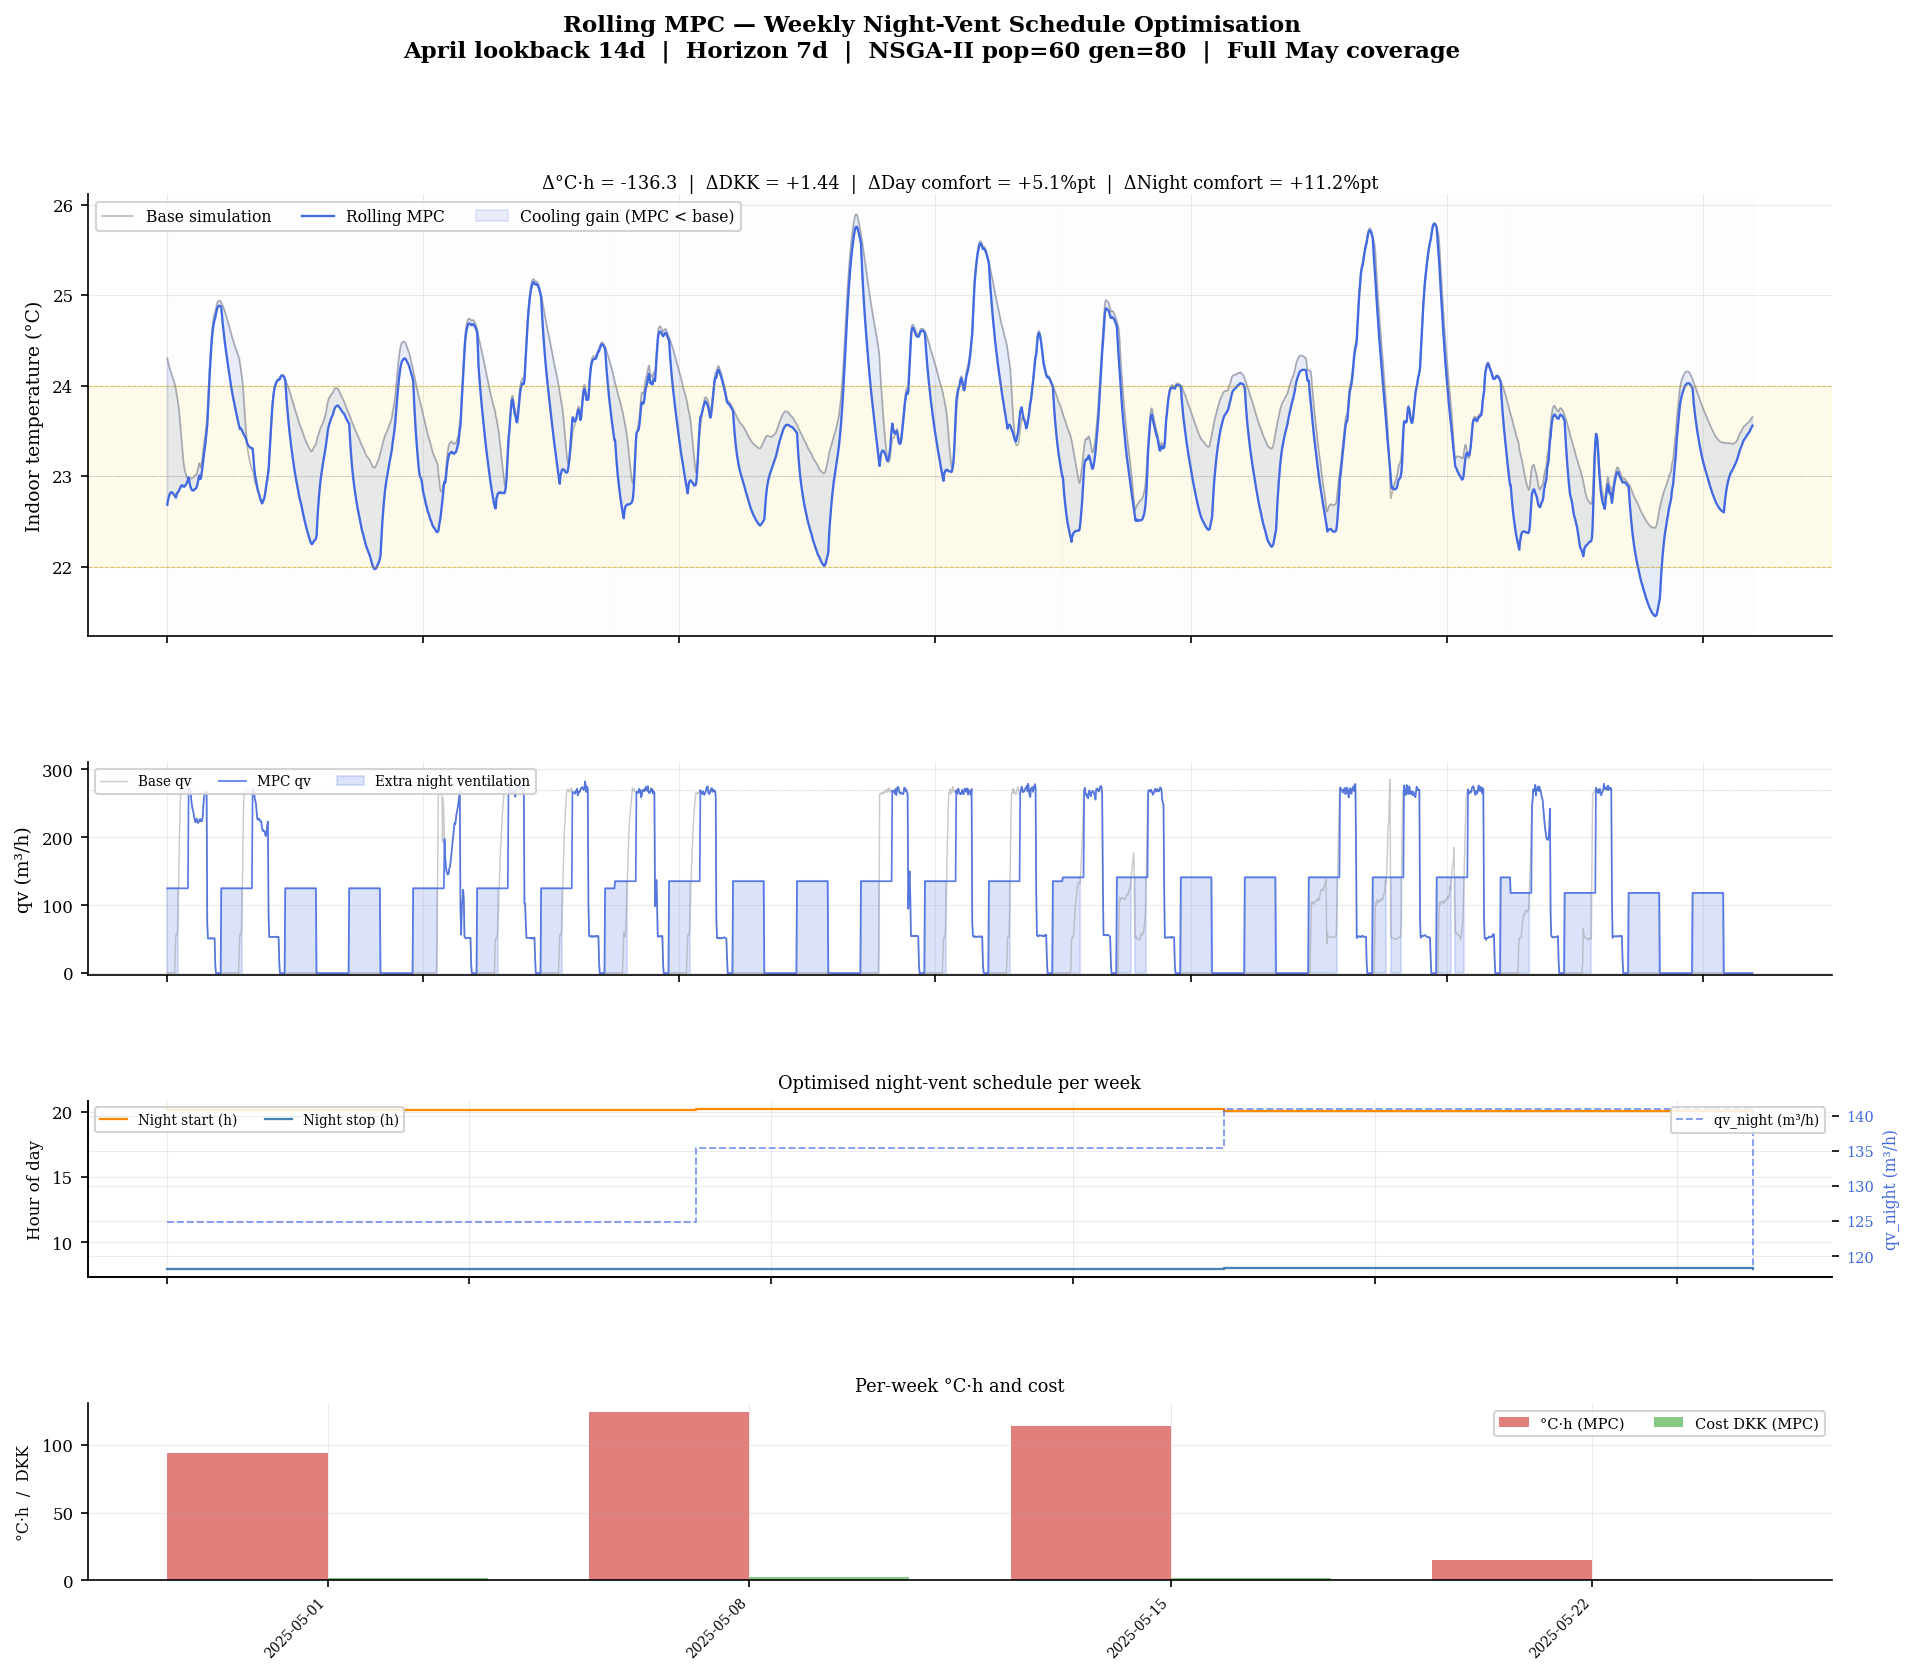

  Saved: rolling_mpc_overview.png


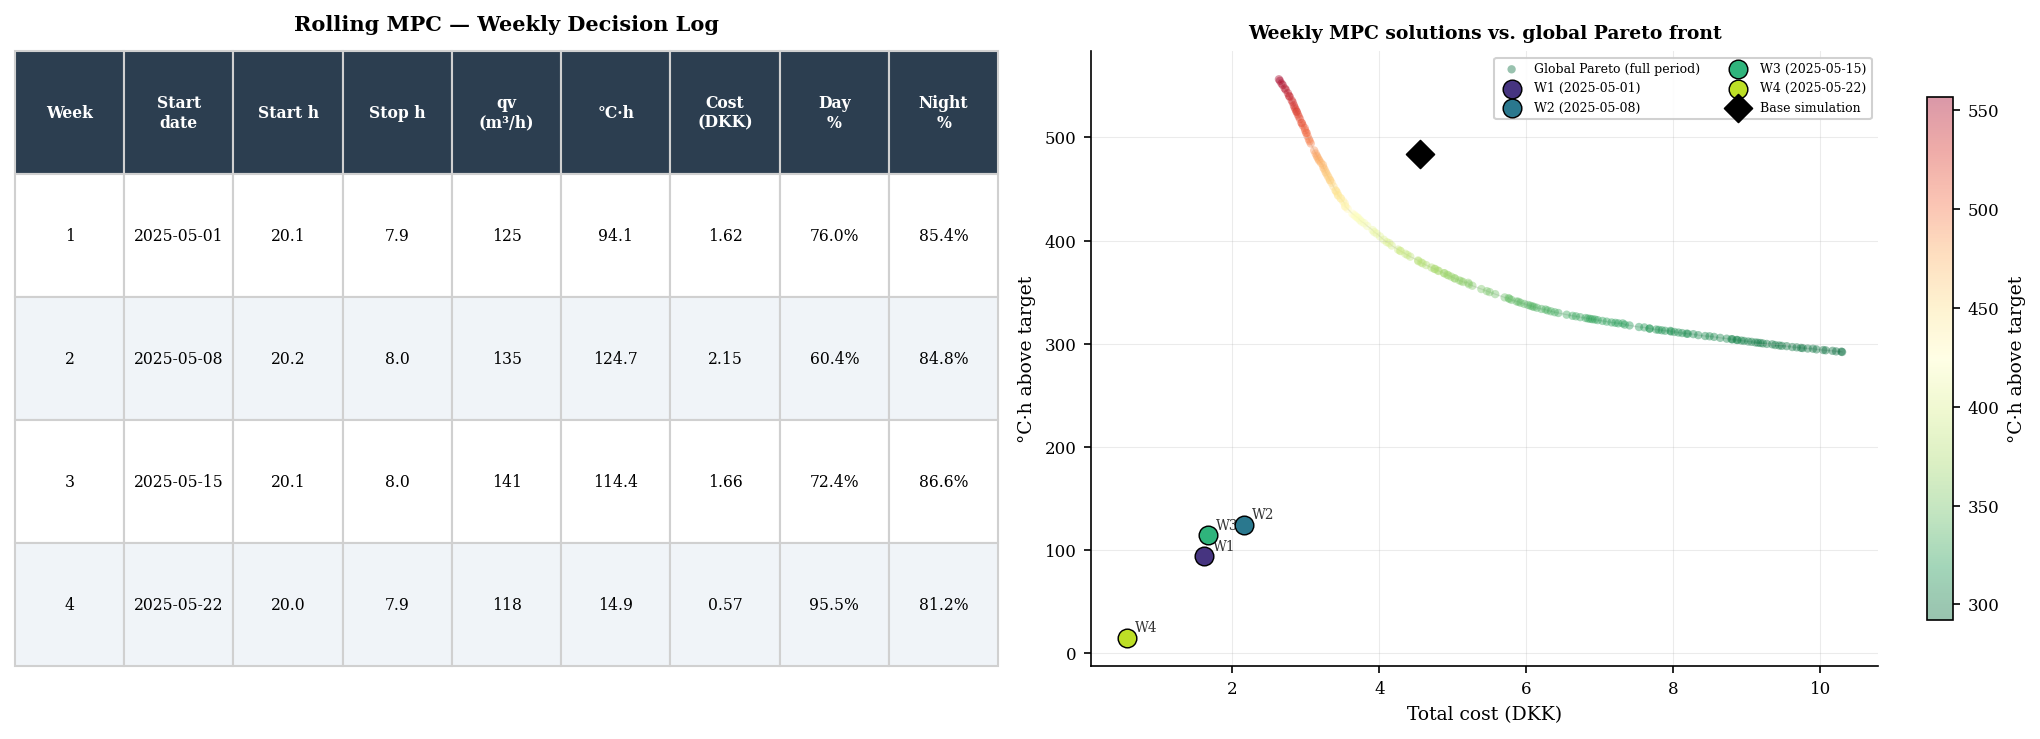

  Saved: rolling_mpc_decisions.png


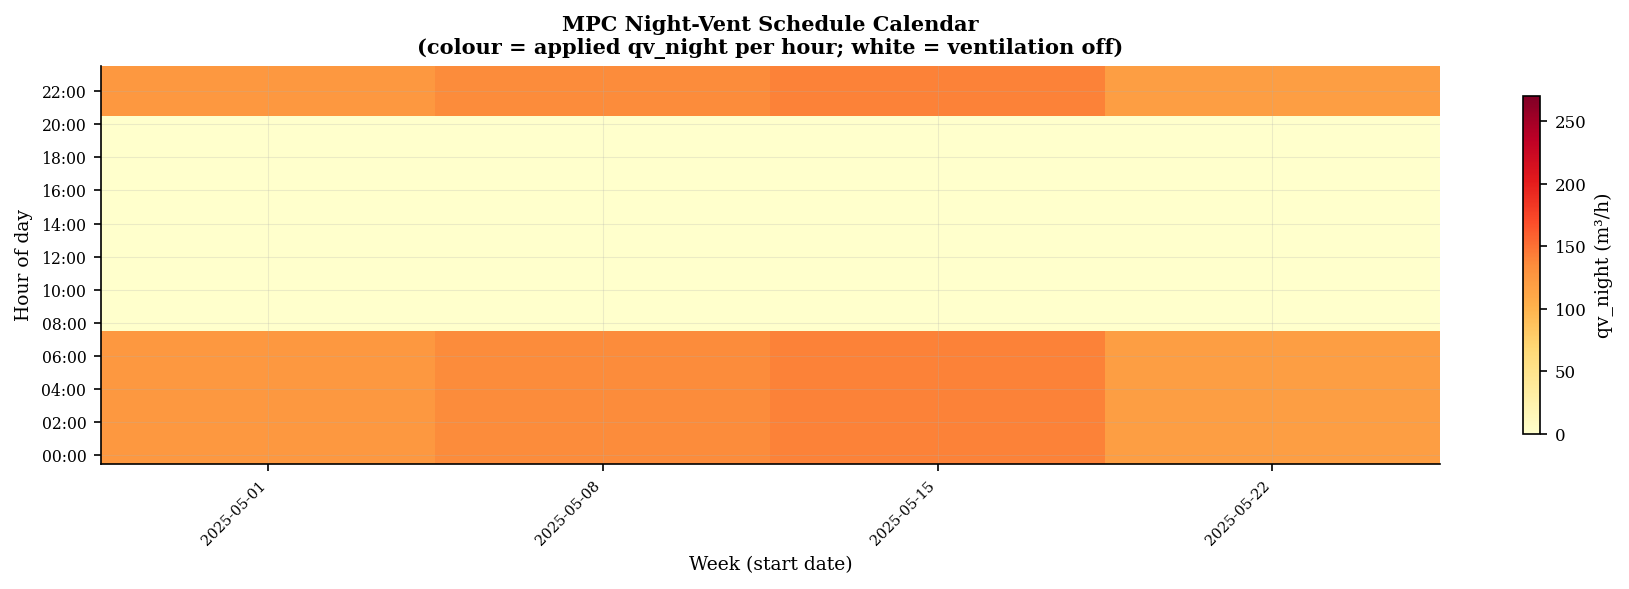

  Saved: rolling_mpc_calendar.png

  ✓  Rolling MPC complete — all figures cover May 1–25 only.


In [38]:
# ════════════════════════════════════════════════════════════════════════════
#  ROLLING MPC — Weekly night-vent schedule optimisation
#
#  Logic:
#    • Slide a 7-day application window over the full dataset
#    • Before each week, look back 14 days of real data (April tail)
#    • Run NSGA-II with 3 decision vars: [night_start_h, night_stop_h, qv_night]
#      applied uniformly to every night in the 7-day horizon
#    • Pick the knee-point solution (min Euclidean dist to utopia)
#    • Simulate that week with the chosen schedule; stitch results together
#    • Log every weekly decision for analysis
#    • Trim output back to May 1–25 for fair comparison with NSGA-II scenarios
# ════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize as pymoo_minimize
from pymoo.termination import get_termination


# ── MPC hyper-parameters ────────────────────────────────────────────────────
MPC_LOOKBACK_DAYS = 14
MPC_HORIZON_DAYS  = 7
MPC_POP           = 60
MPC_GEN           = 80
MPC_SEED          = 42

MPC_LB = np.array([20.0,  0.0,  0.0   ])
MPC_UB = np.array([23.9,  8.0,  QV_MAX])


# ── Cost wrapper: patches all full-length globals to week slice ──────────────
def _mpc_cost(qv_w, Ta_w, Tsup_w, ws, we):
    gb = globals()
    _PATCH_NAMES = ['nighttime_mask', 'cop_arr', 'price_series']
    saved = {}
    for name in _PATCH_NAMES:
        if name in gb:
            arr = gb[name]
            saved[name] = arr
            if hasattr(arr, '__len__') and len(arr) > (we - ws):
                gb[name] = np.asarray(arr)[ws:we]
    try:
        result = total_system_cost(qv_w, Ta_w, Tsup_w)
    finally:
        for name, original in saved.items():
            gb[name] = original
    return result


# ── Helper: build qv array for ONE week given a fixed night schedule ─────────
def _qv_week(idx_week, start_h, stop_h, qv_night, qv_day_arr):
    qv = np.array(qv_day_arr, dtype=float).copy()
    for i, t in enumerate(idx_week):
        h = t.hour + t.minute / 60.0
        if h >= start_h or h < stop_h:
            qv[i] = qv_night
    return qv


# ── Knee-point selector ──────────────────────────────────────────────────────
def _knee_point(F):
    f_min = F.min(axis=0)
    f_max = F.max(axis=0)
    rng   = np.where(f_max - f_min > 1e-12, f_max - f_min, 1.0)
    F_n   = (F - f_min) / rng
    return int(np.argmin(np.linalg.norm(F_n, axis=1)))


# ── pymoo Problem for one 7-day horizon ──────────────────────────────────────
class NightVentWeekProblem(Problem):
    def __init__(self, idx_week, X_week, Ti_init_w, Tm_init_w, c_init_w,
                 Ta_week, qv_base_week, N_profile_w, ws, we):
        super().__init__(n_var=3, n_obj=2, n_ieq_constr=0,
                         xl=MPC_LB, xu=MPC_UB)
        self.idx_week     = idx_week
        self.X_week       = X_week
        self.Ti_init_w    = Ti_init_w
        self.Tm_init_w    = Tm_init_w
        self.c_init_w     = c_init_w
        self.Ta_week      = Ta_week
        self.qv_base_week = qv_base_week
        self.N_profile_w  = N_profile_w
        self.ws           = ws
        self.we           = we

    def _evaluate(self, x, out, *args, **kwargs):
        F = np.empty((len(x), 2))
        for k, xi in enumerate(x):
            start_h = float(xi[0])
            stop_h  = float(xi[1])
            qv_n    = float(xi[2])
            qv_w    = _qv_week(self.idx_week, start_h, stop_h, qv_n,
                               self.qv_base_week.copy())
            X_mod   = self.X_week.copy()
            X_mod['qv'] = qv_w
            res = simulate_night_vent_scenario(
                fitted_params, X_mod, self.N_profile_w,
                night_start_hour=0, night_stop_hour=0, qv_night=0,
                rec_duration=rec_duration,
                Ti_init=self.Ti_init_w,
                Tm_init=self.Tm_init_w,
                c_init=self.c_init_w)
            Ti_w    = np.asarray(res['Ti'])
            dh_w, _ = dh_from_target(Ti_w)
            cost_w  = _mpc_cost(qv_w, self.Ta_week,
                                 np.asarray(X_mod['Tsup']),
                                 self.ws, self.we)
            F[k, 0] = dh_w
            F[k, 1] = cost_w
        out['F'] = F


# ── Rolling MPC main loop ────────────────────────────────────────────────────
def run_rolling_mpc(index, X_train_in, fitted_params,
                    Ti_arr_ref, qv_arr_in,
                    N_hist_in,
                    occ_mask_in, all_night_mask_in,
                    lookback=MPC_LOOKBACK_DAYS,
                    horizon=MPC_HORIZON_DAYS,
                    pop=MPC_POP, gen=MPC_GEN, seed=MPC_SEED,
                    verbose=True):
    N        = len(index)
    dt_h     = (index[1] - index[0]).total_seconds() / 3600.0
    steps_lb = int(lookback * 24 / dt_h)
    steps_hz = int(horizon  * 24 / dt_h)

    Ti_full = np.asarray(Ti_arr_ref, dtype=float)
    Ta_full = np.asarray(X_train_in['Ta'], dtype=float)
    qv_full = np.asarray(qv_arr_in, dtype=float)
    N_full  = np.asarray(N_hist_in, dtype=float)

    Ti_mpc  = np.full(N, np.nan)
    qv_mpc  = np.full(N, np.nan)
    log_rows = []

    first_week_start = steps_lb
    week_starts      = range(first_week_start, N, steps_hz)

    Ti_mpc[:first_week_start] = Ti_full[:first_week_start]
    qv_mpc[:first_week_start] = qv_full[:first_week_start]

    Ti_init_run = float(Ti_full[first_week_start - 1])
    Tm_init_run = Ti_init_run
    c_init_run  = float(c_init)

    n_weeks = len(list(week_starts))

    for w_idx, ws in enumerate(week_starts):
        we   = min(ws + steps_hz, N)
        wlen = we - ws

        idx_week       = index[ws:we]
        X_week         = X_train_in.iloc[ws:we]
        Ta_week        = Ta_full[ws:we]
        qv_base_week   = qv_full[ws:we]
        N_profile_week = N_full[ws:we]

        if verbose:
            print(f"  Week {w_idx+1:2d}/{n_weeks}  "
                  f"[{index[ws].date()} → {index[we-1].date()}]  "
                  f"({wlen} steps)  Ti_init={Ti_init_run:.2f}°C", end='  ')

        problem = NightVentWeekProblem(
            idx_week=idx_week, X_week=X_week,
            Ti_init_w=Ti_init_run, Tm_init_w=Tm_init_run, c_init_w=c_init_run,
            Ta_week=Ta_week, qv_base_week=qv_base_week,
            N_profile_w=N_profile_week, ws=ws, we=we)

        algorithm   = NSGA2(pop_size=pop)
        termination = get_termination('n_gen', gen)
        result      = pymoo_minimize(problem, algorithm, termination,
                                     seed=seed, verbose=False)

        F_w = result.F
        X_w = result.X
        k   = _knee_point(F_w)
        x_k = X_w[k]
        start_h = float(x_k[0])
        stop_h  = float(x_k[1])
        qv_n    = float(x_k[2])

        if verbose:
            print(f"→ knee: start={start_h:.1f}h  stop={stop_h:.1f}h  "
                  f"qv={qv_n:.0f}  dh={F_w[k,0]:.1f}  cost={F_w[k,1]:.2f}")

        qv_w    = _qv_week(idx_week, start_h, stop_h, qv_n, qv_base_week.copy())
        X_mod_w = X_week.copy()
        X_mod_w['qv'] = qv_w

        res_w = simulate_night_vent_scenario(
            fitted_params, X_mod_w, N_full[ws:we],
            night_start_hour=0, night_stop_hour=0, qv_night=0,
            rec_duration=rec_duration,
            Ti_init=Ti_init_run, Tm_init=Tm_init_run, c_init=c_init_run)

        Ti_w      = np.asarray(res_w['Ti'])
        dh_w, _   = dh_from_target(Ti_w)
        cost_w    = _mpc_cost(qv_w, Ta_week,
                               np.asarray(X_mod_w['Tsup']), ws, we)

        _occ  = occ_mask_in[ws:we] if (occ_mask_in is not None and
                                        hasattr(occ_mask_in, '__len__')) else occ_mask_in
        _ngt  = all_night_mask_in[ws:we] if (all_night_mask_in is not None and
                                              hasattr(all_night_mask_in, '__len__')) else all_night_mask_in
        pct_occ_w = pct_in_band(Ti_w, T_cat1_min, T_cat1_max, _occ)
        pct_ngt_w = pct_in_band(Ti_w, T_cat1_min, T_cat1_max, _ngt)

        Ti_mpc[ws:we] = Ti_w
        qv_mpc[ws:we] = qv_w
        Ti_init_run   = float(Ti_w[-1])
        Tm_init_run   = Ti_init_run

        log_rows.append({
            'week'         : w_idx + 1,
            'week_start'   : index[ws],
            'week_end'     : index[we - 1],
            'night_start_h': start_h,
            'night_stop_h' : stop_h,
            'qv_night'     : qv_n,
            'dh_above'     : dh_w,
            'cost_dkk'     : cost_w,
            'pct_occ'      : pct_occ_w,
            'pct_night'    : pct_ngt_w,
            'n_pareto'     : len(F_w),
        })

    return Ti_mpc, qv_mpc, pd.DataFrame(log_rows)


# ════════════════════════════════════════════════════════════════════════════
#  RUN — on extended dataset, then trim back to May analysis window
# ════════════════════════════════════════════════════════════════════════════
print("=" * 70)
print("  ROLLING MPC — weekly NSGA-II night-vent optimisation")
print(f"  Lookback: last {MPC_LOOKBACK_DAYS} days of April  |  "
      f"Horizon: {MPC_HORIZON_DAYS} days  |  Full May coverage")
print("=" * 70)

# ── Override globals to extended versions for cost patches ───────────────────
_saved_globals = {}
for _name, _ext_name in [('nighttime_mask', 'nighttime_mask_ext'),
                          ('cop_arr',        'cop_arr_ext'),
                          ('price_series',   'price_series_ext')]:
    if _name in globals() and _ext_name in globals():
        _saved_globals[_name] = globals()[_name]
        globals()[_name]      = globals()[_ext_name]

Ti_mpc_ext, qv_mpc_ext, mpc_log_ext = run_rolling_mpc(
    index          = index_ext,
    X_train_in     = X_train_ext,
    fitted_params  = fitted_params,
    Ti_arr_ref     = Ti_ref_ext,
    qv_arr_in      = qv_arr_ext,
    N_hist_in      = N_hist_ext,
    occ_mask_in    = occ_mask_ext,
    all_night_mask_in = all_night_mask_ext,
    lookback       = MPC_LOOKBACK_DAYS,
    horizon        = MPC_HORIZON_DAYS,
    pop=MPC_POP, gen=MPC_GEN, seed=MPC_SEED, verbose=True
)

# ── Restore original globals ─────────────────────────────────────────────────
for _name, _orig in _saved_globals.items():
    globals()[_name] = _orig

# ── Trim to May analysis window ───────────────────────────────────────────────
Ti_mpc   = Ti_mpc_ext[n_prepend:]
qv_mpc   = qv_mpc_ext[n_prepend:]
mpc_log  = mpc_log_ext[
    mpc_log_ext['week_start'] >= index[0]
].reset_index(drop=True)
mpc_log['week'] = np.arange(1, len(mpc_log) + 1)   # re-number from 1

print(f"\n  Trimmed to analysis window: {index[0].date()} → {index[-1].date()}")
print(f"  Active optimised weeks: {len(mpc_log)}")


# ── Aggregate MPC metrics ────────────────────────────────────────────────────
valid     = ~np.isnan(Ti_mpc)
valid_idx = np.where(valid)[0]
ws_v      = int(valid_idx[0])
we_v      = int(valid_idx[-1]) + 1

dh_mpc_total   = dh_from_target(Ti_mpc[valid])[0]
cost_mpc_total = _mpc_cost(
    qv_mpc[valid],
    np.asarray(X_train['Ta'])[valid],
    np.asarray(X_train['Tsup'])[valid],
    ws_v, we_v)

_occ_v = occ_mask[valid]       if hasattr(occ_mask,       '__len__') else occ_mask
_ngt_v = all_night_mask[valid] if hasattr(all_night_mask, '__len__') else all_night_mask
pct_occ_mpc = pct_in_band(Ti_mpc[valid], T_cat1_min, T_cat1_max, _occ_v)
pct_ngt_mpc = pct_in_band(Ti_mpc[valid], T_cat1_min, T_cat1_max, _ngt_v)

print(f"\n{'─'*70}")
print(f"  Rolling MPC — full-period aggregate (May 1–25)")
print(f"{'─'*70}")
print(f"  °C·h above {T_TARGET}°C  : {dh_mpc_total:>8.1f}   "
      f"(ref: {dh_above_ref:.1f}  Δ={dh_mpc_total-dh_above_ref:+.1f})")
print(f"  Total cost (DKK)  : {cost_mpc_total:>8.2f}   "
      f"(ref: {cost_ref:.2f}  Δ={cost_mpc_total-cost_ref:+.2f})")
print(f"  Occ. comfort (%)  : {pct_occ_mpc:>7.1f}%   "
      f"(ref: {pct_occ_ref:.1f}%)")
print(f"  Night comfort (%) : {pct_ngt_mpc:>7.1f}%   "
      f"(ref: {pct_night_ref:.1f}%)")
print(f"{'─'*70}")


# ════════════════════════════════════════════════════════════════════════════
#  FIGURE 1 — MPC overview
# ════════════════════════════════════════════════════════════════════════════
fig_mpc, axes = plt.subplots(4, 1, figsize=(15, 12),
                              gridspec_kw={'height_ratios': [2.5, 1.2, 1.0, 1.0],
                                           'hspace': 0.50})
ax_ti, ax_qv, ax_sch, ax_bar = axes

fig_mpc.suptitle(
    f'Rolling MPC — Weekly Night-Vent Schedule Optimisation\n'
    f'April lookback {MPC_LOOKBACK_DAYS}d  |  Horizon {MPC_HORIZON_DAYS}d  |  '
    f'NSGA-II pop={MPC_POP} gen={MPC_GEN}  |  Full May coverage',
    fontsize=11, fontweight='bold'
)

ax_ti.plot(index, Ti_ref, color='#777777', lw=0.75, alpha=0.55, label='Base simulation')
ax_ti.plot(index, Ti_mpc, color='royalblue', lw=1.1, label='Rolling MPC')
ax_ti.axhspan(T_cat1_min, T_cat1_max, alpha=0.08, color='gold')
ax_ti.axhline(T_cat1_max, color='#c8a000', lw=0.5, ls='--', alpha=0.5)
ax_ti.axhline(T_cat1_min, color='#c8a000', lw=0.5, ls='--', alpha=0.5)
ax_ti.axhline(T_TARGET,   color='grey',    lw=0.5, ls=':', alpha=0.5)
ax_ti.fill_between(index, Ti_ref, Ti_mpc,
    where=(np.nan_to_num(Ti_mpc) < Ti_ref), alpha=0.12,
    color='royalblue', label='Cooling gain (MPC < base)')
for row in mpc_log.itertuples():
    c = '#e8f0fe' if row.week % 2 == 0 else '#f3e5f5'
    ax_ti.axvspan(row.week_start, row.week_end, alpha=0.07, color=c, zorder=0)
ax_ti.set_ylabel('Indoor temperature (°C)')
ax_ti.set_title(
    f'Δ°C·h = {dh_mpc_total - dh_above_ref:+.1f}  |  '
    f'ΔDKK = {cost_mpc_total - cost_ref:+.2f}  |  '
    f'ΔDay comfort = {pct_occ_mpc - pct_occ_ref:+.1f}%pt  |  '
    f'ΔNight comfort = {pct_ngt_mpc - pct_night_ref:+.1f}%pt',
    fontsize=8.5, pad=3
)
ax_ti.legend(loc='upper left', ncol=3, fontsize=7.5)
plt.setp(ax_ti.get_xticklabels(), visible=False)

ax_qv.plot(index, qv_arr, color='#999999', lw=0.7, alpha=0.5, label='Base qv')
ax_qv.plot(index, qv_mpc, color='royalblue', lw=0.85, alpha=0.85, label='MPC qv')
ax_qv.fill_between(index, qv_mpc, 0,
    where=~np.isnan(qv_mpc) & (qv_mpc > qv_arr),
    alpha=0.18, color='royalblue', label='Extra night ventilation')
ax_qv.axhline(QV_MAX, color='#444444', lw=0.4, ls=':', alpha=0.35)
ax_qv.set_ylabel('qv (m³/h)')
ax_qv.set_ylim(-2, QV_MAX * 1.15)
ax_qv.legend(loc='upper left', ncol=3, fontsize=6.5)
plt.setp(ax_qv.get_xticklabels(), visible=False)

ax_sch.step(mpc_log['week_start'], mpc_log['night_start_h'],
            where='post', color='darkorange', lw=1.1, label='Night start (h)')
ax_sch.step(mpc_log['week_start'], mpc_log['night_stop_h'],
            where='post', color='steelblue', lw=1.1, label='Night stop (h)')
ax_sch2 = ax_sch.twinx()
ax_sch2.step(mpc_log['week_start'], mpc_log['qv_night'],
             where='post', color='royalblue', lw=0.9, ls='--', alpha=0.65,
             label='qv_night (m³/h)')
ax_sch2.set_ylabel('qv_night (m³/h)', fontsize=7.5, color='royalblue')
ax_sch2.tick_params(axis='y', labelcolor='royalblue', labelsize=7)
ax_sch.set_ylabel('Hour of day', fontsize=8)
ax_sch.set_title('Optimised night-vent schedule per week', fontsize=8.5)
ax_sch.legend(loc='upper left', fontsize=6.5, ncol=2)
ax_sch2.legend(loc='upper right', fontsize=6.5)
ax_sch.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.setp(ax_sch.get_xticklabels(), visible=False)

x_w = np.arange(len(mpc_log))
w_w = 0.38
ax_bar.bar(x_w - w_w/2, mpc_log['dh_above'], w_w,
           color='#d9534f', alpha=0.75, label='°C·h (MPC)')
ax_bar.bar(x_w + w_w/2, mpc_log['cost_dkk'], w_w,
           color='#5cb85c', alpha=0.75, label='Cost DKK (MPC)')
ax_bar.set_xticks(x_w)
ax_bar.set_xticklabels([str(r.week_start.date()) for r in mpc_log.itertuples()],
                        rotation=45, ha='right', fontsize=6.5)
ax_bar.set_ylabel('°C·h  /  DKK', fontsize=7.5)
ax_bar.set_title('Per-week °C·h and cost', fontsize=8.5)
ax_bar.legend(fontsize=7, ncol=2)

plt.savefig('rolling_mpc_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Saved: rolling_mpc_overview.png")


# ════════════════════════════════════════════════════════════════════════════
#  FIGURE 2 — Decision table + Pareto scatter
# ════════════════════════════════════════════════════════════════════════════
fig2, (ax_tbl, ax_sc) = plt.subplots(1, 2, figsize=(14, 5))

ax_tbl.axis('off')
col_labels = ['Week', 'Start\ndate', 'Start h', 'Stop h',
              'qv\n(m³/h)', '°C·h', 'Cost\n(DKK)', 'Day\n%', 'Night\n%']
tbl_data = []
for r in mpc_log.itertuples():
    tbl_data.append([
        f'{r.week}',
        str(r.week_start.date()),
        f'{r.night_start_h:.1f}',
        f'{r.night_stop_h:.1f}',
        f'{r.qv_night:.0f}',
        f'{r.dh_above:.1f}',
        f'{r.cost_dkk:.2f}',
        f'{r.pct_occ:.1f}%',
        f'{r.pct_night:.1f}%',
    ])
tbl = ax_tbl.table(cellText=tbl_data, colLabels=col_labels,
                   cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False)
tbl.set_fontsize(7.5)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#f0f4f8')
    cell.set_edgecolor('#d0d0d0')
ax_tbl.set_title('Rolling MPC — Weekly Decision Log', fontsize=10,
                  fontweight='bold', pad=10)

_sort_pf2 = np.argsort(F_pareto[:, 1])
sc_pf = ax_sc.scatter(F_pareto[:, 1], F_pareto[:, 0],
                       c=F_pareto[:, 0], cmap='RdYlGn_r', s=16,
                       alpha=0.40, edgecolors='none', zorder=1,
                       label='Global Pareto (full period)')
ax_sc.plot(F_pareto[_sort_pf2, 1], F_pareto[_sort_pf2, 0],
           color='#888888', lw=0.6, alpha=0.25, zorder=0)
plt.colorbar(sc_pf, ax=ax_sc, label='°C·h above target', shrink=0.85)
cmap_w = plt.cm.viridis(np.linspace(0.15, 0.9, len(mpc_log)))
for i, r in enumerate(mpc_log.itertuples()):
    ax_sc.scatter(r.cost_dkk, r.dh_above,
                  color=cmap_w[i], s=80, edgecolors='black', linewidths=0.7,
                  zorder=6, marker='o',
                  label=f'W{r.week} ({r.week_start.date()})')
    ax_sc.annotate(f'W{r.week}', (r.cost_dkk, r.dh_above),
                   textcoords='offset points', xytext=(4, 3),
                   fontsize=6.5, color='#333333')
ax_sc.scatter(_ref['cost'], _ref['dh_above'],
              marker='D', color='black', s=90, edgecolors='black',
              linewidths=0.8, zorder=7, label='Base simulation')
ax_sc.set_xlabel('Total cost (DKK)')
ax_sc.set_ylabel('°C·h above target')
ax_sc.set_title('Weekly MPC solutions vs. global Pareto front',
                fontsize=9, fontweight='bold')
ax_sc.legend(fontsize=6, ncol=2, loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.savefig('rolling_mpc_decisions.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Saved: rolling_mpc_decisions.png")


# ════════════════════════════════════════════════════════════════════════════
#  FIGURE 3 — Schedule calendar heatmap
# ════════════════════════════════════════════════════════════════════════════
fig3, ax_cal = plt.subplots(figsize=(12, 4))

n_hours  = 24
presence = np.zeros((n_hours, len(mpc_log)))
for j, r in enumerate(mpc_log.itertuples()):
    for h in range(n_hours):
        if h >= r.night_start_h or h < r.night_stop_h:
            presence[h, j] = r.qv_night

im = ax_cal.imshow(presence, aspect='auto', origin='lower',
                    cmap='YlOrRd', interpolation='nearest',
                    vmin=0, vmax=QV_MAX)
plt.colorbar(im, ax=ax_cal, label='qv_night (m³/h)', shrink=0.85)
ax_cal.set_yticks(range(0, 24, 2))
ax_cal.set_yticklabels([f'{h:02d}:00' for h in range(0, 24, 2)], fontsize=7.5)
ax_cal.set_xticks(range(len(mpc_log)))
ax_cal.set_xticklabels([str(r.week_start.date()) for r in mpc_log.itertuples()],
                        rotation=45, ha='right', fontsize=7)
ax_cal.set_xlabel('Week (start date)')
ax_cal.set_ylabel('Hour of day')
ax_cal.set_title(
    'MPC Night-Vent Schedule Calendar\n'
    '(colour = applied qv_night per hour; white = ventilation off)',
    fontsize=10, fontweight='bold'
)
plt.tight_layout()
plt.savefig('rolling_mpc_calendar.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Saved: rolling_mpc_calendar.png")

print("\n  ✓  Rolling MPC complete — all figures cover May 1–25 only.")